# Who Is the Working Class?

* Keep going with comments from Elena

* Guo sectioning

<a id="table-of-contents"></a>

## Table of Contents

1. [Introduction](#introduction)  
2. [Workflow Overview](#workflow-overview)  
   2.1. [Processing a Single Article](#processing-of-a-single-article)  
   2.2. [Applying Workflow to the Full Dataset](#apply)  
3. [Analysis & Results](#analysis-results)  
   3.1. [Geographical Location](#geographical-location)  
   3.2. [Occupations](#occupations)  
   3.3. [Race/Ethnicity](#race-ethnicity)  
   3.4. [Gender](#gender)  
   3.5. [Education](#education)  
   3.6. [Immigration Status](#immigration-status)  
   3.7. [Union Membership](#union-membership)  
   3.8. [Other Characteristics](#other-characteristics)  
4. [Conclusion](#conclusion)  
5. [Next Steps](#next-steps)  
6. [Reproducibility](#reproducibility)
7. [Bibliography](#bibliography)


<a id="introduction"></a>
## 1. Introduction 


[⬆ Return to Top](#table-of-contents)

This project analyzes how the working class is represented in the media. It explores changes in representation over time and compares portrayals across different publishers.

In [1]:
# import libraries
import pandas as pd
from datetime import datetime
import os
from statistics import mean, pstdev
from openai import OpenAI
import json
# utils for plots
from utils import compare_histograms, split_locations, flatten, extract_region_mentions, line_time_plot, save_examples_to_folder # review which ones ended up being used
# utils for batch processing
from utils import create_batch, submit_batch, retrieve_batch_results, parse_batch_results

In [2]:
# set configurations
#model = "gpt-4.1"
model="gpt-5-mini"
temperature = 1 # Cannot use temperature = 0 with gpt-5-mini (see note below)
reasoning_effort = "minimal"

# Show all columns in all outputs
pd.set_option('display.max_columns', None)

__Note on Temperature:__

- Ideally, we would set the temperature parameter to 0.
- With **full models** (e.g., GPT-4.1, GPT-5), you can set `temperature = 0` for deterministic outputs.  
- With **gpt-5-mini**, the `temperature` parameter is fixed at **1** (the default) and cannot be changed.  
- This is **intentional**: mini models are optimized for **throughput, cost, and speed**. Because their probability distributions are less “sharp” than larger models, forcing `temperature = 0` could cause issues such as repetitive loops, truncated outputs, or overly rigid phrasing.  
- At **temperature = 1**, the model samples directly from its predicted distribution, without sharpening (lower temps) or flattening (higher temps).  


In [3]:
# load cleaned data
df_articles = pd.read_pickle("../data/processed/cleaned_articles.pkl")

print(f"Total number of articles: {df_articles.shape[0]:,}")

Total number of articles: 41,148


In [4]:
df_articles["country_flag"].value_counts()

country_flag
BOTH            24796
US_ONLY         11120
FOREIGN_ONLY     3213
NONE             2019
Name: count, dtype: int64

In [5]:
# domestic articles only
df_articles = df_articles.loc[df_articles["country_flag"] != "FOREIGN_ONLY"]
print(f"Net number of domestic articles: {df_articles.shape[0]:,}")

Net number of domestic articles: 37,935


In [6]:
print(df_articles.loc[df_articles["country_flag"] == "BOTH"]['title'].iloc[10], "\n")
print(df_articles.loc[df_articles["country_flag"] == "BOTH"]['body'].iloc[10])

What I'm Thinking at the End of 2024; The Ezra Klein Show 

This is an edited transcript of an episode of "The Ezra Klein Show." You can listen to the conversation by following or subscribing to the show on the NYT Audio App, Apple, Spotify, Amazon Music, YouTube, iHeartRadio or wherever you get your podcasts.
Ezra Klein: Happy holidays. Welcome to "Ask Me Anything" and the near end of a year that has felt like many, many, many years.
We thought before it all ends, we would answer a couple more questions — hopefully slightly more fun ones than those that are more election focused. And then we're going to be back with new episodes in the new year and have some stuff that I'm pretty excited about in the pipeline.
But thank you to everybody who's been listening this year. It has been a ride.
Thank you to Claire Gordon, who's here with me and has been an amazing partner in building the show this year and editing it and getting things out at the last minute. To her and to the team. They've 

Updates:

* Expanded search for international identifiers to include world capitals, and regions.
* country_flag numbers changed:
    * US_ONLY         19255 --> 11120
    * BOTH            16661 --> 24796
    * FOREIGN_ONLY     2634 --> 3213
    * NONE             2598 --> 2019
           

To do:

* Compare US_ONLY and FOREIGN_ONLY, to Guo' section.

* To identify domestic vs international articles, leverage Guo's section analysis:

    * If US_ONLY: domestic
    
    * If FOREIGN_ONLY: international
    
    * BOTH / NONE => Use sections
    
        * If section not available?

In [7]:
# Calculate article length threshold for filtering out anomalously long articles
article_lengths = df_articles["length"]
large_length_threshold = round(mean(article_lengths) + 3 * pstdev(article_lengths))
print(f"Anomalously large article length threshold: {large_length_threshold:,}")

# Filter out anomalously large articles
df_articles = df_articles.loc[df_articles['length'] < large_length_threshold]
print(f"Net number of articles after length filter: {df_articles.shape[0]:,}")

Anomalously large article length threshold: 4,557
Net number of articles after length filter: 37,228


In [8]:
df_articles.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua, Washington ...","[Massachusetts, Rhode Island, US, Washington]",NYT/1.DOCX,The New York Times
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[France, Japan, Paris (Capital), Sierra Leone,...","[America, California, Florida, Georgia, Massac...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio)
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,BOTH,[Male (Capital)],"[New York, North Carolina, US, United States]",NYT/1.DOCX,The New York Times
3,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",1333,False,BOTH,"[Brazil, Lima (Capital)]","[New York, US, United States]",NYT/1.DOCX,The New York Times
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[America, Delaware, Maryland, New Jersey, New ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer


In [9]:
# year
df_articles['year'] = pd.to_datetime(df_articles["date"]).dt.year

### Cost Estimate and Reduction Options

#### Baseline Cost

- **200 article sample using GPT-4.1**  

  - $1.05 per 200 articles
  
  - Population size: 37,795 
  
  - Total cost ≈ 37,795 / 200 * $1.05 = **USD 198.42**

- **200 article sample using GPT-5 mini with reasoning_effort = "minimal"**  

  - $0.17 per 200 articles
  
  - Population size: 37,795 
  
  - Total cost ≈ 37,795 / 200 * $0.18 = **USD 34.02**  


---

#### Cost Reduction Options

##### 1. Switch to GPT-5-mini (`reasoning_effort="minimal"`)
- **Pricing (per 1 M tokens)**
  - Input: $0.25
  
  - Cached input: $0.025 
  
  - Output: $2.00 
  
  - Source: https://platform.openai.com/docs/pricing

- **Comparison (GPT-4.1)**
  - Input: $2.00  
  
  - Cached input: $0.5
  
  - Output: $8.00 

- **Performance Reference**  
  [Artificial Analysis Comparison](https://artificialanalysis.ai/?models=gpt-5-mini-minimal%2Cgpt-4-1%2Cgpt-5-mini-medium%2Cgpt-5-nano%2Cgpt-5-mini)

- **Reasoning Effort Levels (GPT-5 series)**
  - Minimal → prioritizes **speed + low cost**, minimal internal reasoning  
  - Medium, High → progressively more reasoning, higher latency + cost  

---

##### 2. Caching
- Looked into caching the **system prompt** and **response_format** to reduce input cost
- Learned that handlend automatically but only applies to larger inputs

---

##### 3. Batch API
- Run tasks asynchronously (up to 24 hours)  
- Saves **50% on inputs and outputs**  
- Docs: [OpenAI Batch API](https://platform.openai.com/docs/guides/batch)  



### Other cost considerations

#### Rate limits

* API usage is subject to rate limits applied on tokens per minute (TPM), requests per minute or day (RPM/RPD), and other model-specific limits.

* Limits: https://platform.openai.com/settings/organization/limits

* Increased to Usage tier 2 by adding \$50 to my account, but likely need Usage tier 3 or above to run all in one batch.

* Reccomendation: Create 8 batches of roughly 5,000 articles each, and run each on separate days. Good also for reducing chances of issues.

<a id="workflow-overview"></a>
## 2. Workflow Overview

[⬆ Return to Top](#table-of-contents)

The goal of this stage of the project is to systematically extract information on key identity domains of the working-class groups described in newspaper articles. Each article is processed to identify and categorize characteristics such as geographical location, occupations, race/ethnicity, gender, education, immigration status, union membership, and other relevant traits. These categories provide a structured representation of how the working class is depicted across different publishers and time periods.

To achieve this, we designed a workflow that converts unstructured text into a consistent, machine-readable format. First, a system prompt instructs the model to focus exclusively on the working class within each article and return answers for the eight domains. The output is constrained by a strict JSON schema, ensuring that all responses are standardized and comparable across articles.

The workflow proceeds in two steps:

1. **Processing a Single Article** – A single news article is passed through the system to validate that the prompt and schema produce accurate, well-structured responses.  
2. **Applying Workflow to the Dataset** – Once validated, the method is applied to a larger, balanced sample of articles across publishers, producing a dataset where each article is paired with its extracted working-class identity attributes.

The processed dataset then forms the basis for the next section, which further analyzes and visualizes patterns in how different publishers and time periods portray the working class.


<a id="processing-of-a-single-article"></a>
### 2.1. Processing a Single Article


[⬆ Return to Top](#table-of-contents)

In [10]:
system_prompt = """
The user will provide a newspaper article that mentions the working class. Using information from this article, answer the following questions **focusing exclusively on the characteristics of the working class group** described. Do not include information about other groups or individuals, even if they interact with or are discussed alongside the working class. If any information is missing or cannot be reasonably inferred, respond with "NA."

1) **Locations** – Where is this working-class group located? 
   - List all relevant U.S. states (or, if outside the U.S., list the countries).
   - If in the U.S., also identify the region (Northeast, Midwest, South, Southwest, or West).
   - Indicate whether the setting is primarily urban, suburban, or rural.

2) **Occupations** – What kinds of jobs does this working-class group hold? (List all that apply.) 
   - Categories: Manufacturing, Service, Construction, Administrative/Clerical, Transportation.
   - If "Other", please specify.

3) **Employment Type** – Are members of this working-class group primarily **self-employed (business owners)** or **employees**? If not specified, enter "NA."

4) **Race/Ethnicity** – What racial or ethnic backgrounds are identified for this working-class group? Use Census Bureau categories: White, Black or African American, American Indian or Alaska Native, Asian, Native Hawaiian or Other Pacific Islander.

5) **Gender** – What is the gender composition of the working-class group?

6) **Education** – What education levels are mentioned for this working-class group? (Examples: less than high school, high school diploma, some college, college degree, vocational/technical training, NA)

7) **Immigration Status** – What is the immigration status of the working-class group? (Examples: immigrants, undocumented workers, refugees, naturalized citizens, citizens, NA)

8) **Union Membership** – What role does union membership play for this working-class group? (Examples: unionized, non-unionized, mixed, NA)

9) **Other Characteristics** – What other relevant characteristics not already captured are mentioned about the working-class group? (Examples: income level, age, housing situation, family structure, etc.)
"""


In [11]:
print(system_prompt)


The user will provide a newspaper article that mentions the working class. Using information from this article, answer the following questions **focusing exclusively on the characteristics of the working class group** described. Do not include information about other groups or individuals, even if they interact with or are discussed alongside the working class. If any information is missing or cannot be reasonably inferred, respond with "NA."

1) **Locations** – Where is this working-class group located? 
   - List all relevant U.S. states (or, if outside the U.S., list the countries).
   - If in the U.S., also identify the region (Northeast, Midwest, South, Southwest, or West).
   - Indicate whether the setting is primarily urban, suburban, or rural.

2) **Occupations** – What kinds of jobs does this working-class group hold? (List all that apply.) 
   - Categories: Manufacturing, Service, Construction, Administrative/Clerical, Transportation.
   - If "Other", please specify.

3) **E

In [12]:
response_format = {
  "type": "json_schema",
  "json_schema": {
    "name": "working_class_article_analysis",
    "schema": {
      "type": "object",
      "properties": {
        "locations": {
          "type": "array",
          "description": "Specific U.S. states or countries where the working-class group is located. If not provided or unclear, enter ['NA'].",
          "items": {
            "type": "string"
          },
          "minItems": 1
        },
        "us_region": {
          "type": "string",
          "description": "U.S. region where the group is located (Northeast, Midwest, South, Southwest, West). If not applicable or not provided, enter 'NA'."
        },
        "setting": {
          "type": "string",
          "description": "Urban, Suburban, or Rural setting of the working-class group. If not specified, enter 'NA'."
        },
        "occupations": {
          "type": "array",
          "description": "Occupation categories relevant to the group. Categories: Manufacturing, Service, Construction, Administrative/Clerical, Transportation. If 'Other', specify. If not mentioned, use ['NA'] as the sole entry.",
          "items": { "type": "string" },
          "minItems": 1
        },
        "employment_type": {
          "type": "string",
          "description": "Whether the group members are primarily self-employed (business owners) or employees. If not specified, enter 'NA'."
        },
        "race_ethnicity": {
          "type": "string",
          "description": "Racial or ethnic background(s) identified in the article. If not mentioned, enter 'NA'."
        },
        "gender": {
          "type": "string",
          "description": "Gender composition of the group (e.g., 'Mostly women', 'Mixed', 'NA'). If not specified, enter 'NA'."
        },
        "education": {
          "type": "string",
          "description": "Education level(s) mentioned for the group (e.g., 'High school', 'Some college', 'NA'). If not provided, enter 'NA'."
        },
        "immigration_status": {
          "type": "string",
          "description": "Immigration status of the group (e.g., 'Immigrants', 'Undocumented', 'Naturalized citizens', 'Citizens', 'NA'). If not specified, enter 'NA'."
        },
        "union_membership": {
          "type": "string",
          "description": "Union membership status (e.g., 'Unionized', 'Non-unionized', 'Mixed', 'NA'). If not mentioned, enter 'NA'."
        },
        "other_characteristics": {
          "type": "string",
          "description": "Any additional relevant details not captured above (e.g., income level, age, housing situation, family structure). Enter 'NA' if none are provided."
        }
      },
      "required": [
        "locations",
        "us_region",
        "setting",
        "occupations",
        "employment_type",
        "race_ethnicity",
        "gender",
        "education",
        "immigration_status",
        "union_membership",
        "other_characteristics"
      ],
      "additionalProperties": False
    },
    "strict": True
  }
}


In [13]:
client = OpenAI()

def analyze_working_class(user_prompt):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        response_format=response_format,
        temperature=temperature,
        reasoning_effort=reasoning_effort
    )

    return json.loads(response.choices[0].message.content)


In [14]:
article_indx = 2
user_prompt = "Title: {}\n\nBody: {}".format(df_articles["title"].iloc[article_indx], df_articles["body"].iloc[article_indx])
print(user_prompt[:2000], "\n...\n")

Title: She Exalted The Beauty Of Dance

Body: She was The New Yorker's first dance critic. Her wit could be devastating but behind it was a belief in beauty.
Arlene Croce, who died last week at 90, made dance as important in arts criticism as painting, music, theater and books. The New Yorker's dance critic from 1973 to 1996, Croce amassed a cult following and not a few detractors. She was also, despite insular origins, one of the most daring and stylish critics in the American canon. 
  In the 1970s, a dance boom hit New York City, and The New Yorker created its first-ever dance critic slot, filling it with a 40-year-old editor and film critic plucked from small-magazine obscurity: Croce.
  But Croce wasn't created by the dance boom. She created herself, through a stubborn, private, almost secret ambition, and a sort of homemade feminism that morphed into an Olympian credo about art. She believed in beauty. And she believed that a mix of virtuosity and classicism -- she loved that wor

In [15]:
response_dict = analyze_working_class(user_prompt)
response_dict

{'locations': ['Rhode Island', 'North Carolina'],
 'us_region': 'Northeast (Rhode Island) and South (North Carolina)',
 'setting': 'Primarily urban',
 'occupations': ['Manufacturing'],
 'employment_type': 'NA',
 'race_ethnicity': 'White (Italian American)',
 'gender': 'NA',
 'education': 'NA',
 'immigration_status': 'NA',
 'union_membership': 'NA',
 'other_characteristics': 'Large, extended Italian American working-class family that later rose to middle class; father was a textile mill manager; retained cultural rituals and speech patterns.'}

<a id="apply"></a>
### 2.2. Applying Workflow to the Full Dataset (Testing with Sample First)


[⬆ Return to Top](#table-of-contents)

In [16]:
n_total = 200 * 35

df_articles_subset = df_articles.loc[df_articles['year'] >= 1990]# 1990s onward

# Number of samples per publisher per year
n_per_group = n_total // (df_articles_subset['publisher'].nunique() * df_articles_subset['year'].nunique())

# Sample equally by publisher and year
df_sampled = pd.concat(
    [
        group.sample(min(len(group), n_per_group), random_state=42)
        for _, group in df_articles_subset.groupby(['publisher', 'year'])
    ]
)

df_sampled.reset_index(drop=True, inplace=True)
print(df_sampled.groupby(['publisher', 'year']).size())

publisher        year
New York Times   1990    100
                 1991    100
                 1992    100
                 1993    100
                 1994    100
                        ... 
Other publisher  2020    100
                 2021    100
                 2022    100
                 2023    100
                 2024    100
Length: 70, dtype: int64


In [17]:
df_sampled.shape # noted fewer articles in 1990 and 1991 for Other Publishers
#for x, y in df_sampled.groupby(['publisher', 'year']).size().items():
 #   print(x, y)

(6893, 13)

In [18]:
sample_path = f"../data/processed/df_articles_{n_total}_sample.pkl"
# temporarily save
if not os.path.exists(sample_path):
    df_sampled.to_pickle(sample_path)

In [19]:
# --- 1. Create batch input file from your DataFrame ---
batch_input_filename = "batch_input.jsonl"
output_filename="batch_output.jsonl"
create_batch(df_sampled, system_prompt, response_format, model, temperature, reasoning_effort, batch_input_filename)
#create_batch(df=df_sampled, batch_input_filename=batch_input_filename)

# --- 2. Submit the batch to OpenAI ---
if not os.path.exists(output_filename):
    batch_id = submit_batch(batch_input_filename=batch_input_filename)
    print("Batch ID:", batch_id)

In [20]:
#batch_id = "batch_68c8bb40034c8190b17803d26b891d79"

In [21]:
if not os.path.exists(output_filename):
    # --- 3. Wait until batch finishes ---
    # You can check status periodically:
    batch_status = client.batches.retrieve(batch_id)
    print("Batch status:", batch_status.status)

    # Typical statuses: "validating", "in_progress", "completed", "failed"
    # You may need to wait several minutes to hours depending on size & queue.
    if batch_status.status == "completed":
        # --- 4. Once status == "completed", download results ---
        output_filename = retrieve_batch_results(batch_id, output_filename)

For more details, uncomment below:

In [22]:
#batch_status = client.batches.retrieve(batch_id)
#batch_status

In [23]:
# --- 5. Parse batch output into a DataFrame ---
if output_filename:
    df_responses = parse_batch_results(output_filename, model)

=== Token Usage Summary ===
Prompt tokens:     16257775
Completion tokens: 948869
Cached tokens:     0
Total tokens:      17206644
Estimated cost for gpt-5-mini: $2.9811


In [24]:
df_responses.shape

(6897, 15)

In [25]:
df_sampled.shape

(6893, 13)

In [26]:
df_responses.head(2)

,custom_id,prompt_tokens,completion_tokens,cached_tokens,total_tokens,locations,us_region,setting,occupations,race_ethnicity,gender,education,immigration_status,union_membership,other_characteristics
0,req-0,4236,106,0,4342,[New York],Northeast,Suburban,[Other],White,NA,NA,NA,NA,Upwardly mobile working class; described as pa...
1,req-1,2788,124,0,2912,[Romania],NA,Urban,[NA],NA,NA,NA,NA,NA,Described as one of two families portrayed in ...


In [27]:
# Combine results with dataset
df_articles_with_results = pd.concat([df_sampled, df_responses], axis=1)

In [28]:
df_articles_with_results.head(2)

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,year,custom_id,prompt_tokens,completion_tokens,cached_tokens,total_tokens,locations,us_region,setting,occupations,race_ethnicity,gender,education,immigration_status,union_membership,other_characteristics
0,The Myth of Classnessness,New York Times,1990-10-10,"Section A; Page 23, Column 1; Editorial Desk; ...","This country is in shackles, its thought, char...",913.0,False,US_ONLY,[],"[America, New Jersey, New York, US, United Sta...",NYT/29.DOCX,The New York Times,1990.0,req-0,4236,106,0,4342,[New York],Northeast,Suburban,[Other],White,NA,NA,NA,NA,Upwardly mobile working class; described as pa...
1,Upheaval in the East: Czechoslovakia;\nIn Choi...,New York Times,1990-02-15,"Section A; Page 19, Column 1; Foreign Desk","Rudolf Slansky, a disenchanted former Communis...",1081.0,False,BOTH,"[Austria, Germany, Moscow (Capital), Washingto...","[New York, US, United States, Washington]",NYT/47.DOCX,The New York Times,1990.0,req-1,2788,124,0,2912,[Romania],NA,Urban,[NA],NA,NA,NA,NA,NA,Described as one of two families portrayed in ...


In [29]:
sample_with_results_path =  f"../data/processed/df_articles_{n_total}_sample_with_results.pkl"
if not os.path.exists(sample_with_results_path):
    df_articles_with_results.to_pickle(sample_with_results_path)
    print(f"Sample with results saved to: {sample_with_results_path}.")
    # delete temporary results?

<a id="analysis-results"></a>
## 3. Analysis & Results

[⬆ Return to Top](#table-of-contents)

This section examines how different aspects of working-class identity are represented across publishers and over time. For each domain, we build on the earlier results, applying additional processing to highlight variation in coverage between *The New York Times* (NYT) and a group of regional publishers, as well as temporal trends.  

The regional publishers included in this combined set are: *Chicago Daily Herald*, *Dayton Daily News*, *Pittsburgh Post-Gazette*, *Star Tribune*, *The Philadelphia Inquirer*, and *USA Today*.  

Each domain section presents descriptive plots and commentary to illustrate both cross-publisher comparisons and changes over time.  


<a id="geographical-location"></a>  
### 3.1. Geographical Location  

[⬆ Return to Top](#table-of-contents)  

**Description:** Identifies where the working-class group is located.  
- List all relevant U.S. states (or, if outside the U.S., list the countries).  
- If in the U.S., also specify the region (Northeast, Midwest, South, Southwest, or West).  
- Indicate whether the setting is primarily *urban, suburban,* or *rural*.  

**Variables:** `location`, `us_region`, `setting`  

---

#### Data Processing Steps  

- **Standardization of location data:**  
  - The raw location field contains either:  
    - Country or countries (for groups outside the U.S.)  
    - State(s) (for U.S.-based groups)  
    - Occasionally additional location details (e.g., city names), from which state or country can sometimes be inferred.  
  - Standardized states and countries were extracted using programmatic keyword searches.  
    - **Limitation:** If only a city (e.g., *Los Angeles*) is mentioned, the algorithm may fail to identify the state (*California*) or country (*U.S.*).  
    - **Opportunity:** A secondary model could improve coverage by mapping additional information.

- **Deriving U.S. region and setting:**  
  - Standardized `us_region` (Northeast, Midwest, South, Southwest, West) and `setting` (urban/suburban/rural) values were generated from raw fields using keyword-based rules.  
  - Initial spot checks show this approach is effective, but full validation is still needed.  

- **Creation of a “Flat” column:**  
  - Based on standardized columns (`countries_stand` --> `countries_stand_flat`, `states_stand` --> `states_stand_flat`, `us_region_stand` --> `us_region_stand_flat`, `setting_stand` --> `setting_stand_flat`) .  
  - Lists were collapsed into single values using the following rules:  
    - **Single value:** The value is retained.  
    - **Multiple values:** Marked as *Mixed*.  
    - **No values:** Marked as *Unspecified*.  


In [30]:
new_cols = pd.DataFrame(list(df_articles_with_results["locations"].apply(split_locations)), columns=['states_stand', 'countries_stand', 'other_locations_stand'])
df_articles_with_results = pd.concat([df_articles_with_results, new_cols], axis=1)

# country correction
df_articles_with_results['countries_stand'] = [["United States"] if (len(state_list) > 0 and country_list == []) else country_list  for state_list, country_list in zip(df_articles_with_results['states_stand'], df_articles_with_results['countries_stand']) ]

In [31]:
# standardize regions
df_articles_with_results['us_region_stand'] = df_articles_with_results['us_region'].apply(extract_region_mentions)

# standardize urban vs rural setting

settings = ['urban', 'suburban', 'rural']
df_articles_with_results['setting_stand'] = df_articles_with_results['setting'].apply(lambda x: [i.title() for i in extract_region_mentions(x.lower(), regions= settings)])


In [32]:
for col in ["countries_stand", "states_stand", "us_region_stand", "setting_stand"]:
    df_articles_with_results[f"{col}_flat"] = df_articles_with_results[col].apply(
        lambda x: "Multiple" if len(x) > 1 else ("Unspecified" if len(x) == 0 else x[0])
    )


In [33]:
df_articles_with_results.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,year,custom_id,prompt_tokens,completion_tokens,cached_tokens,total_tokens,locations,us_region,setting,occupations,race_ethnicity,gender,education,immigration_status,union_membership,other_characteristics,states_stand,countries_stand,other_locations_stand,us_region_stand,setting_stand,countries_stand_flat,states_stand_flat,us_region_stand_flat,setting_stand_flat
0,The Myth of Classnessness,New York Times,1990-10-10,"Section A; Page 23, Column 1; Editorial Desk; ...","This country is in shackles, its thought, char...",913.0,False,US_ONLY,[],"[America, New Jersey, New York, US, United Sta...",NYT/29.DOCX,The New York Times,1990.0,req-0,4236,106,0,4342,[New York],Northeast,Suburban,[Other],White,NA,NA,NA,NA,Upwardly mobile working class; described as pa...,[New York],[United States],[],[Northeast],[Suburban],United States,New York,Northeast,Suburban
1,Upheaval in the East: Czechoslovakia;\nIn Choi...,New York Times,1990-02-15,"Section A; Page 19, Column 1; Foreign Desk","Rudolf Slansky, a disenchanted former Communis...",1081.0,False,BOTH,"[Austria, Germany, Moscow (Capital), Washingto...","[New York, US, United States, Washington]",NYT/47.DOCX,The New York Times,1990.0,req-1,2788,124,0,2912,[Romania],NA,Urban,[NA],NA,NA,NA,NA,NA,Described as one of two families portrayed in ...,[],[Romania],[],[],[Urban],Romania,Unspecified,Unspecified,Urban
2,"Teachers and Principal Begin Sharing Power, bu...",New York Times,1990-11-13,Section A;; Section A; Page 1; Column 1; Metro...,"At Public School 192 on Harlem's western edge,...",1217.0,False,US_ONLY,[],"[New York, US]",NYT/50.DOCX,The New York Times,1990.0,req-2,2058,120,0,2178,[Czechoslovakia],NA,Urban,[Other],NA,NA,NA,NA,NA,The article references 'the working class' in ...,[],[Czechoslovakia],[],[],[Urban],Czechoslovakia,Unspecified,Unspecified,Urban
3,"Review/Theater;\nThe Schisms of the City, Comi...",New York Times,1990-06-15,"Section C; Page 1, Column 3; Weekend Desk; Review","Ouisa Kittredge, the Upper East Side hostess a...",1484.0,False,BOTH,[Male (Capital)],"[America, New York, Utah]",NYT/52.DOCX,The New York Times,1990.0,req-3,1979,157,0,2136,[NA],NA,NA,"[Manufacturing and Industrial Jobs, Skilled Tr...",Black or African American; White,Mixed,NA,NA,NA,Low income / paycheck-to-paycheck living; cram...,[],[],[NA],[],[],Unspecified,Unspecified,Unspecified,Unspecified
4,Barry Guilty on One Drug Count; Mistral is Dec...,New York Times,1990-08-11,"Section 1; Page 1, Column 1; National Desk",The jury in the trial of Mayor Marion S. Barry...,1692.0,False,BOTH,[Washington (Capital)],"[Georgia, US, United States, Washington]",NYT/53.DOCX,The New York Times,1990.0,req-4,1938,106,0,2044,[NA],NA,Urban,[NA],NA,Mostly women,NA,NA,NA,Middle-class socioeconomic status; motivated b...,[],[],[NA],[],[Urban],Unspecified,Unspecified,Unspecified,Urban


#### Country-Level Representation

In [34]:
nyt_mask = df_articles_with_results["publisher"] == "New York Times"
nyt_series = df_articles_with_results[nyt_mask]['countries_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['countries_stand_flat']

In [35]:
nyt_series = [i if i in ["United States", "Multiple", "Unspecified"] else "Foreign Country" for i in nyt_series]
other_series = [i if i in ["United States", "Multiple", "Unspecified"] else "Foreign Country" for i in other_series]

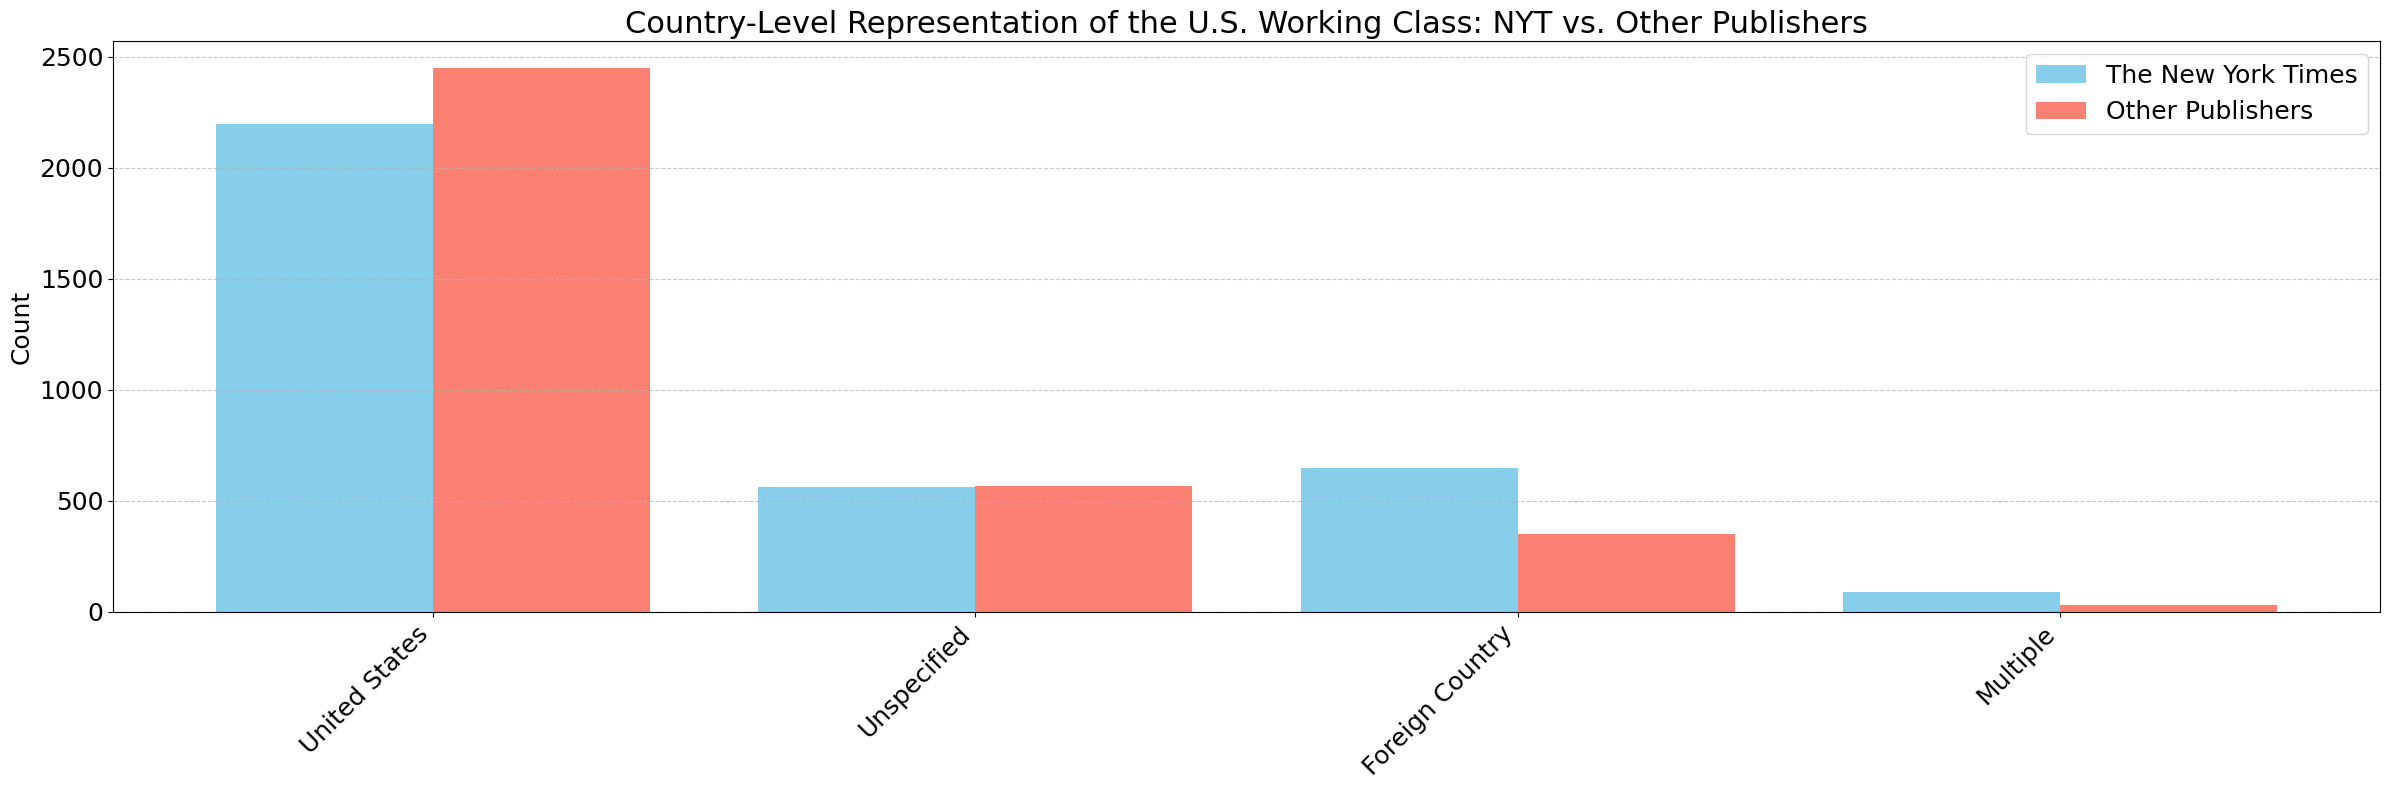

In [36]:
title = 'Country-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_countries.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [37]:
import os
import pandas as pd
from docx import Document

# Base folder path
examples_dir = "../example_articles"

# 1️⃣ Check if "example_articles" folder exists; if not, create it
if not os.path.exists(examples_dir):
    os.makedirs(examples_dir)

var = 'countries_stand_flat'
var_original = 'locations'
save_examples_to_folder(var, df_articles_with_results, examples_dir, var_original)

✅ Articles saved successfully.


#### State-Level Representation

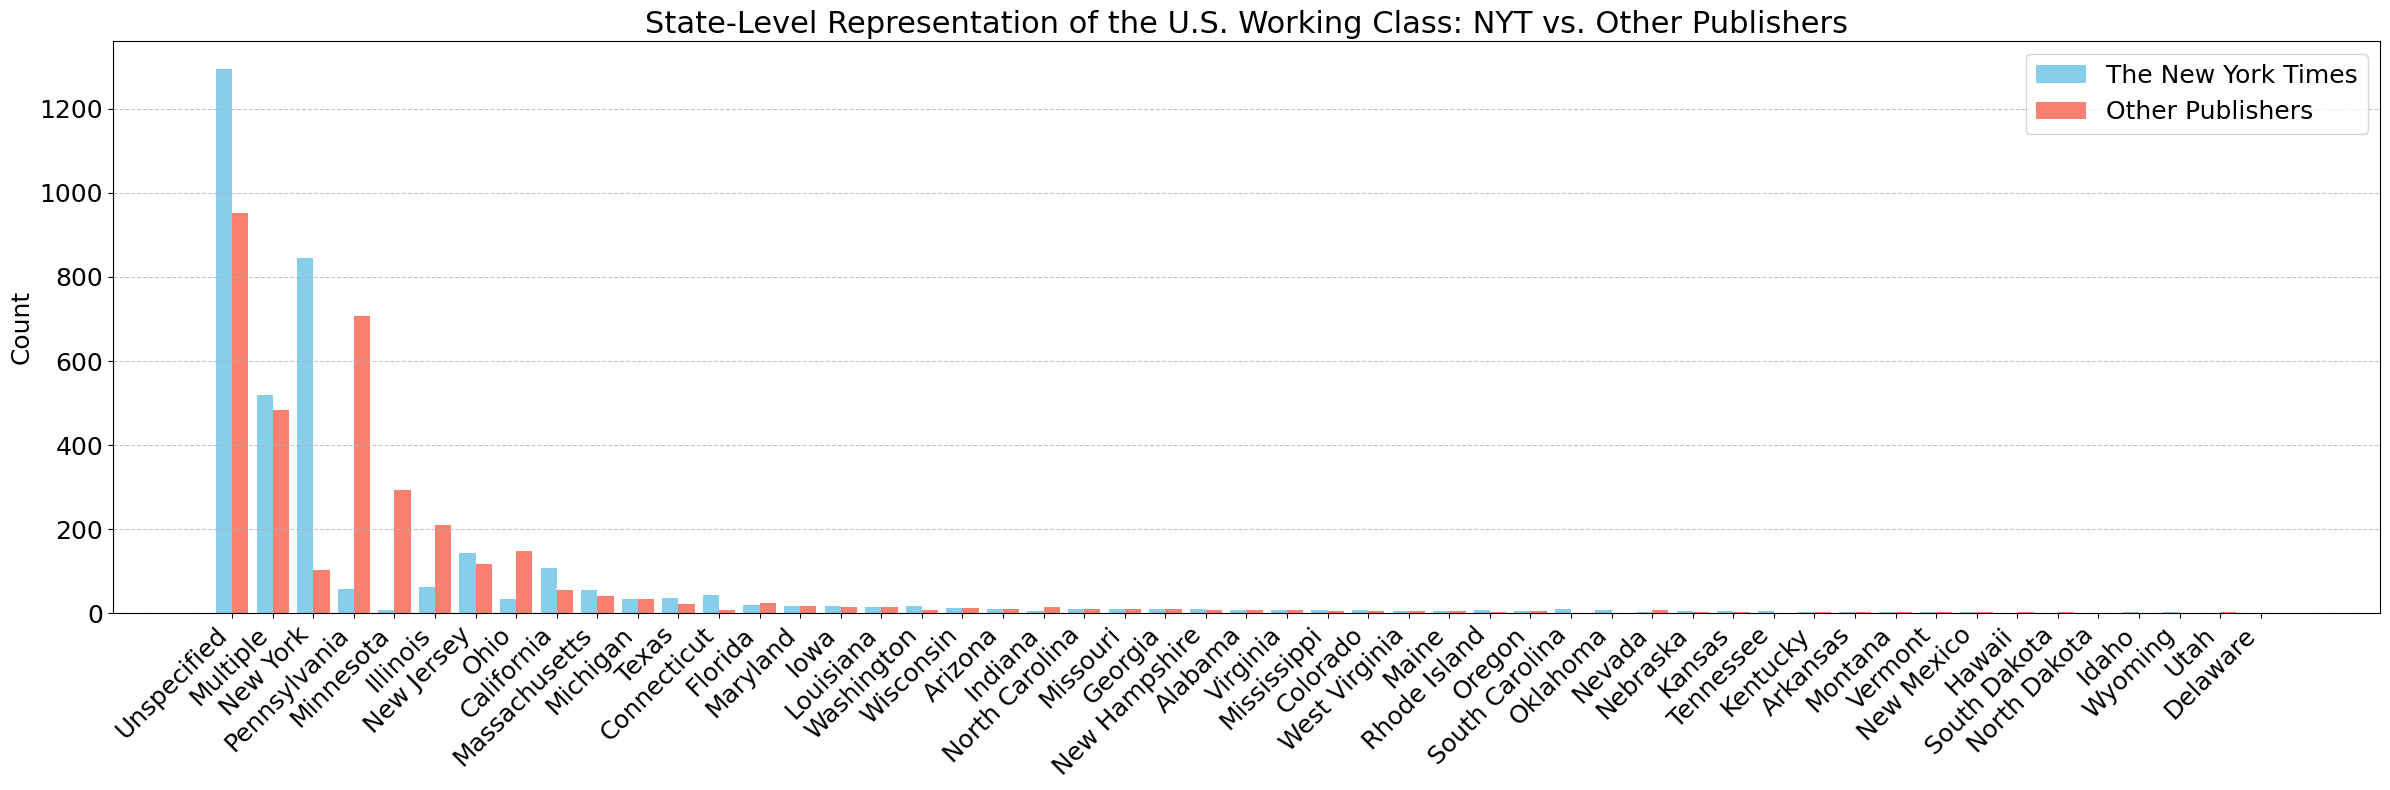

In [38]:
nyt_series = df_articles_with_results[nyt_mask]['states_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['states_stand_flat']

title = 'State-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_states.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [39]:
var = 'states_stand_flat'
var_original = 'locations'
save_examples_to_folder(var, df_articles_with_results, examples_dir, var_original)

✅ Articles saved successfully.


In [40]:
from collections import Counter

state_counts = Counter(list(nyt_series) + list(other_series))
high_freq_states = {key: value for key, value in state_counts.items() if value >= 300}
high_freq_states

{'New York': 949,
 'Unspecified': 2249,
 'Pennsylvania': 764,
 'Multiple': 1002,
 'Minnesota': 300}

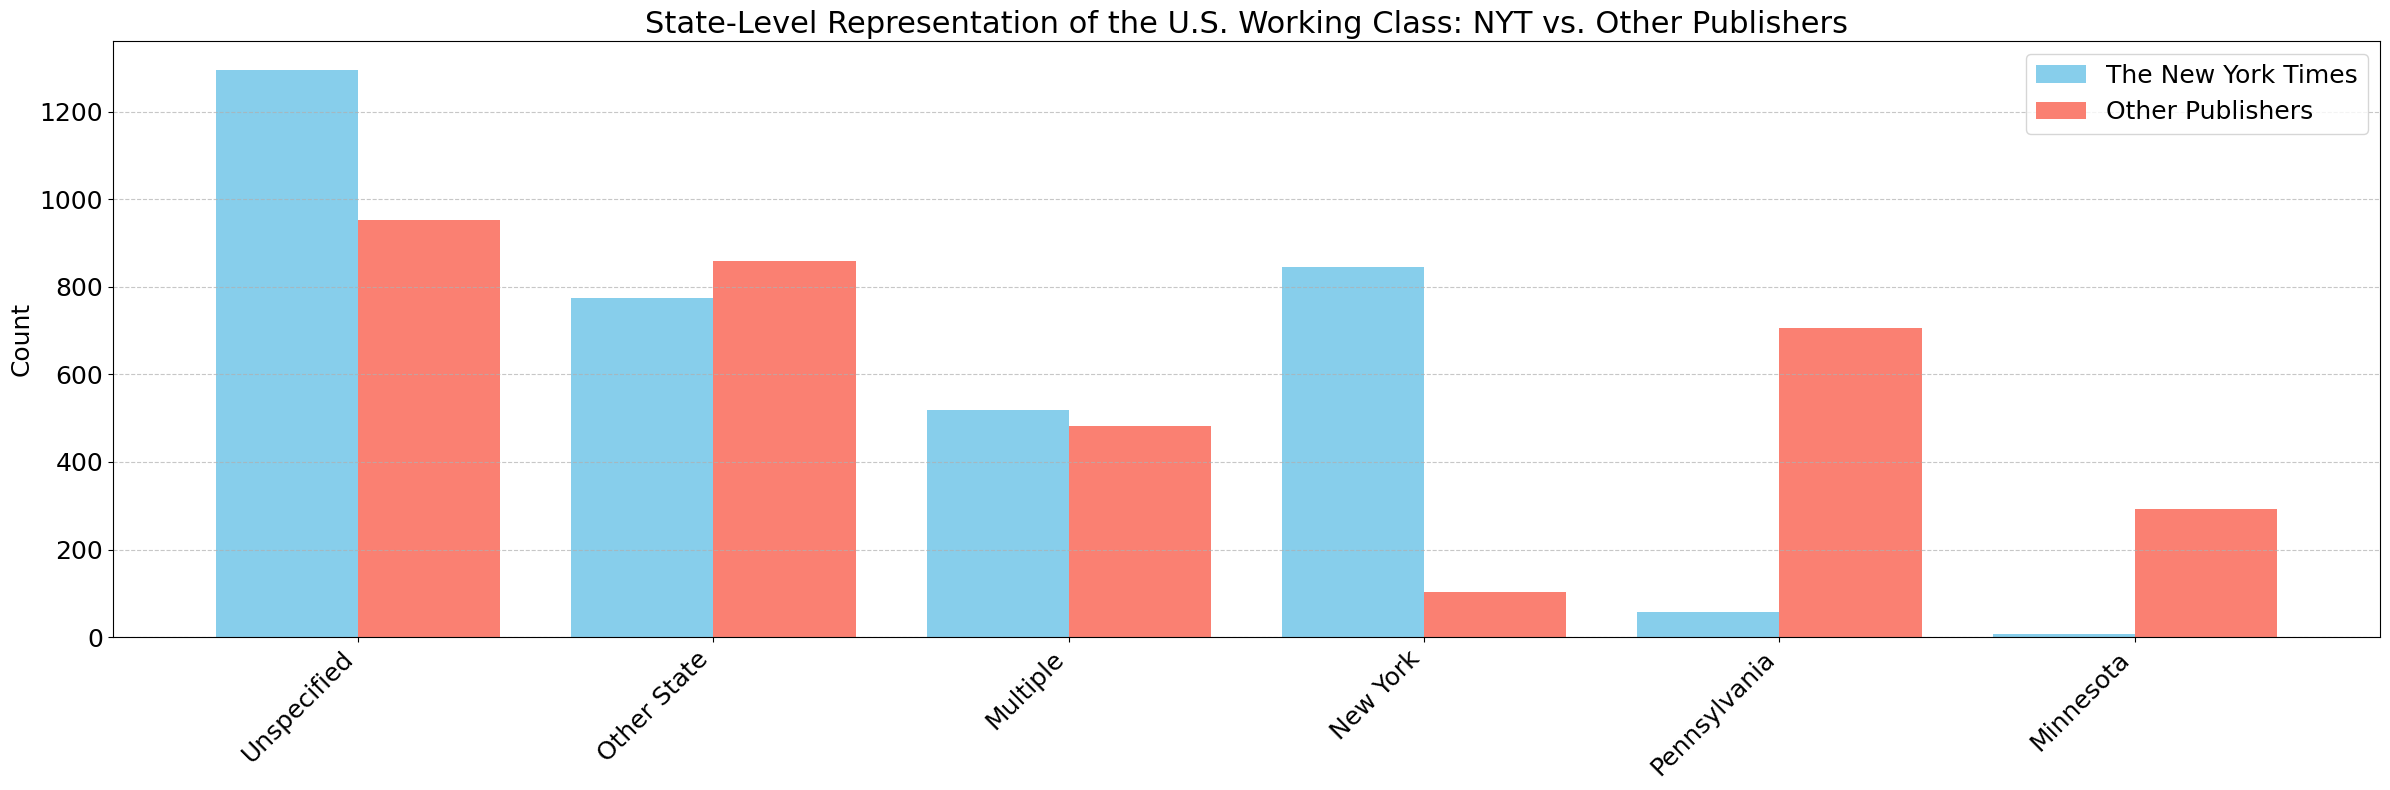

In [41]:
df_articles_with_results["states_stand_flat_cat"] = df_articles_with_results["states_stand_flat"].apply(lambda x: x if x in high_freq_states.keys() else "Other State" )

nyt_series = df_articles_with_results[nyt_mask]['states_stand_flat_cat']
other_series = df_articles_with_results[~nyt_mask]['states_stand_flat_cat']

title = 'State-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_states_categorized.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
year_mask = df_articles_with_results["year"] > 1991

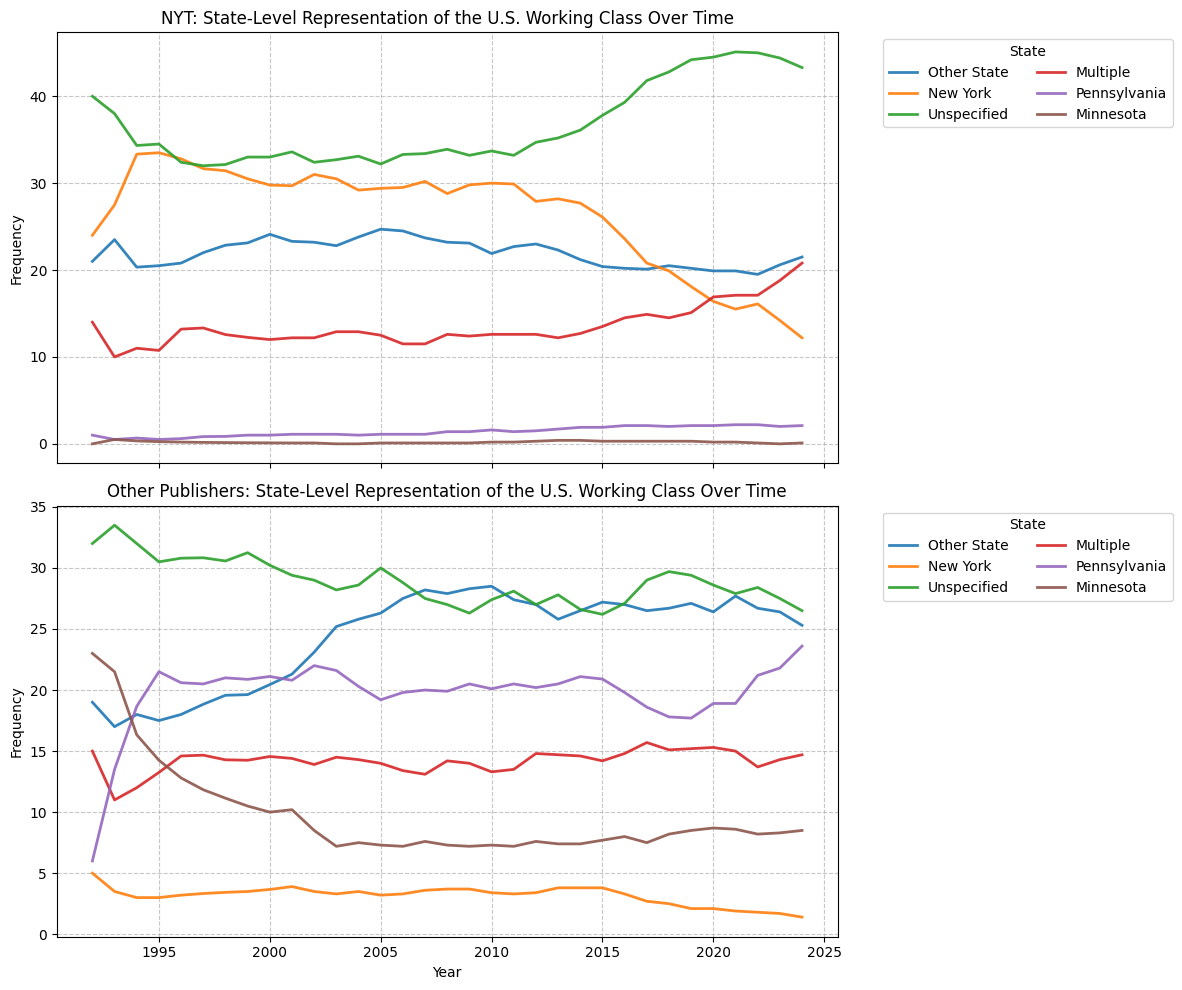

In [44]:
variable = "states_stand_flat_cat"
filename = "../plots/comparison_states_categorized_time_chart.png"
title = 'State-Level Representation of the U.S. Working Class Over Time'
line_time_plot(df_articles_with_results[year_mask], nyt_mask[year_mask], variable, title, filename, variable_label="State", smooth_window=10)

#### Region-level Representation

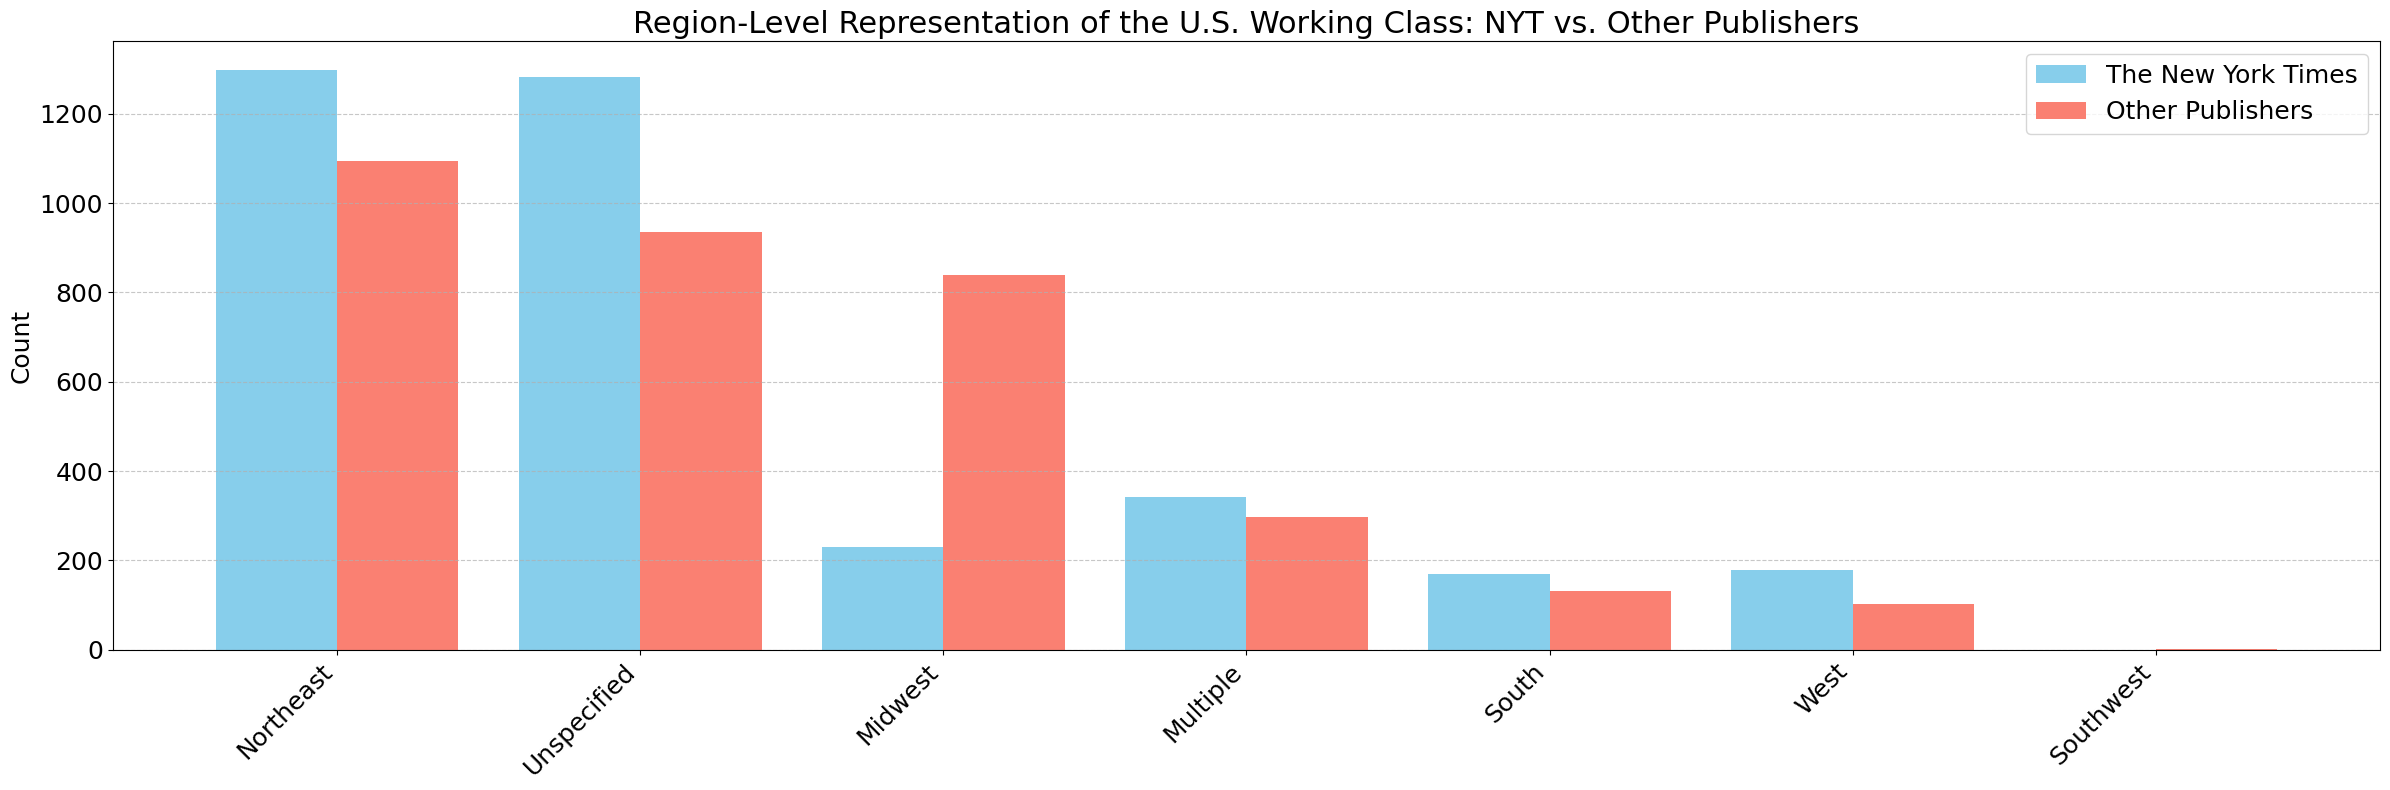

In [45]:
nyt_series = df_articles_with_results[nyt_mask]['us_region_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['us_region_stand_flat']

title = 'Region-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_regions.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [46]:
var = 'us_region_stand_flat'
var_original = 'locations'
save_examples_to_folder(var, df_articles_with_results, examples_dir, var_original)

✅ Articles saved successfully.


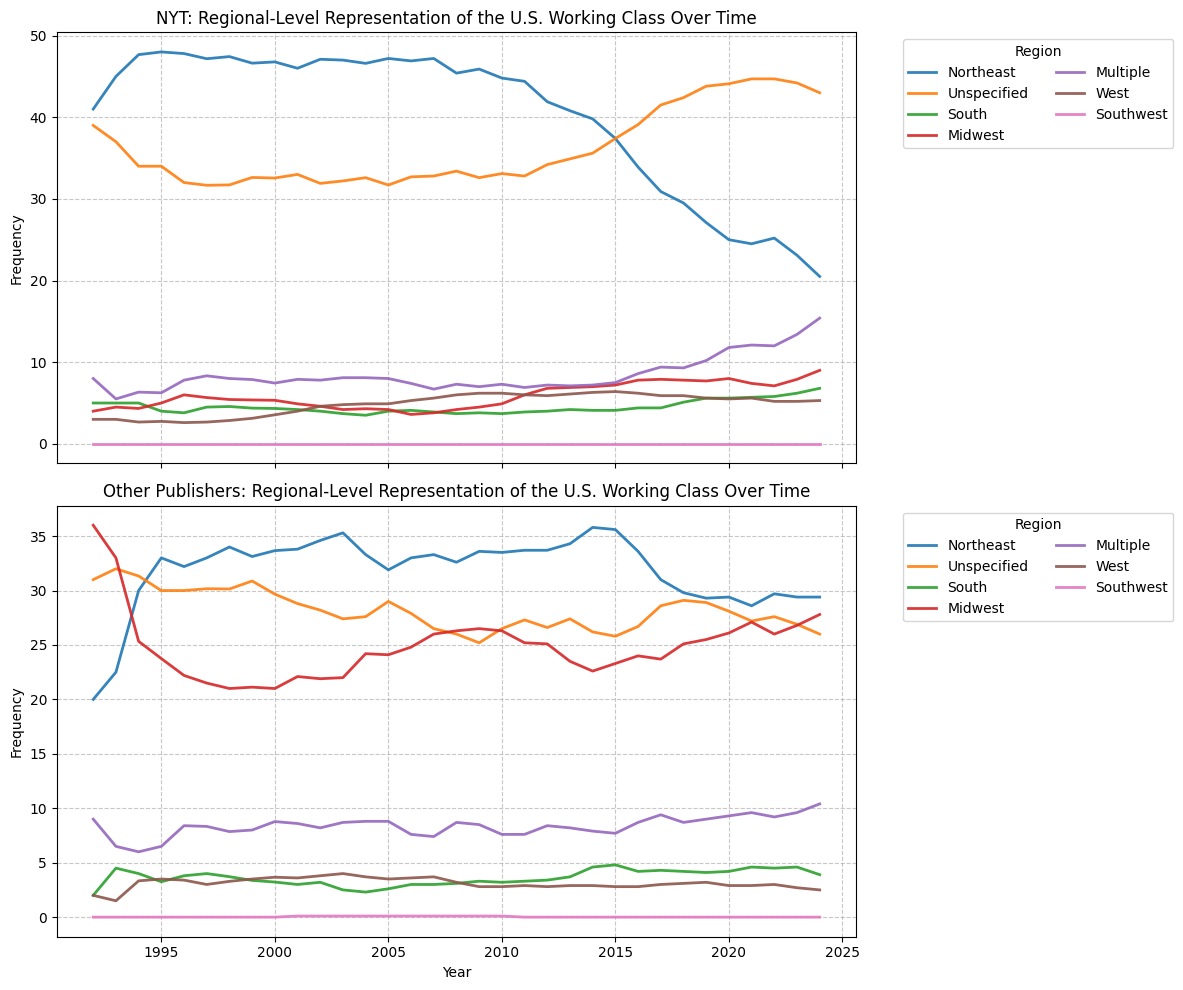

In [47]:
variable = 'us_region_stand_flat'
filename = "../plots/comparison_regions_time_chart.png"
title = 'Regional-Level Representation of the U.S. Working Class Over Time'
line_time_plot(df_articles_with_results[year_mask], nyt_mask[year_mask], variable, title, filename, variable_label="Region", smooth_window=10)

#### Urban, Suburban, and Rural Representation

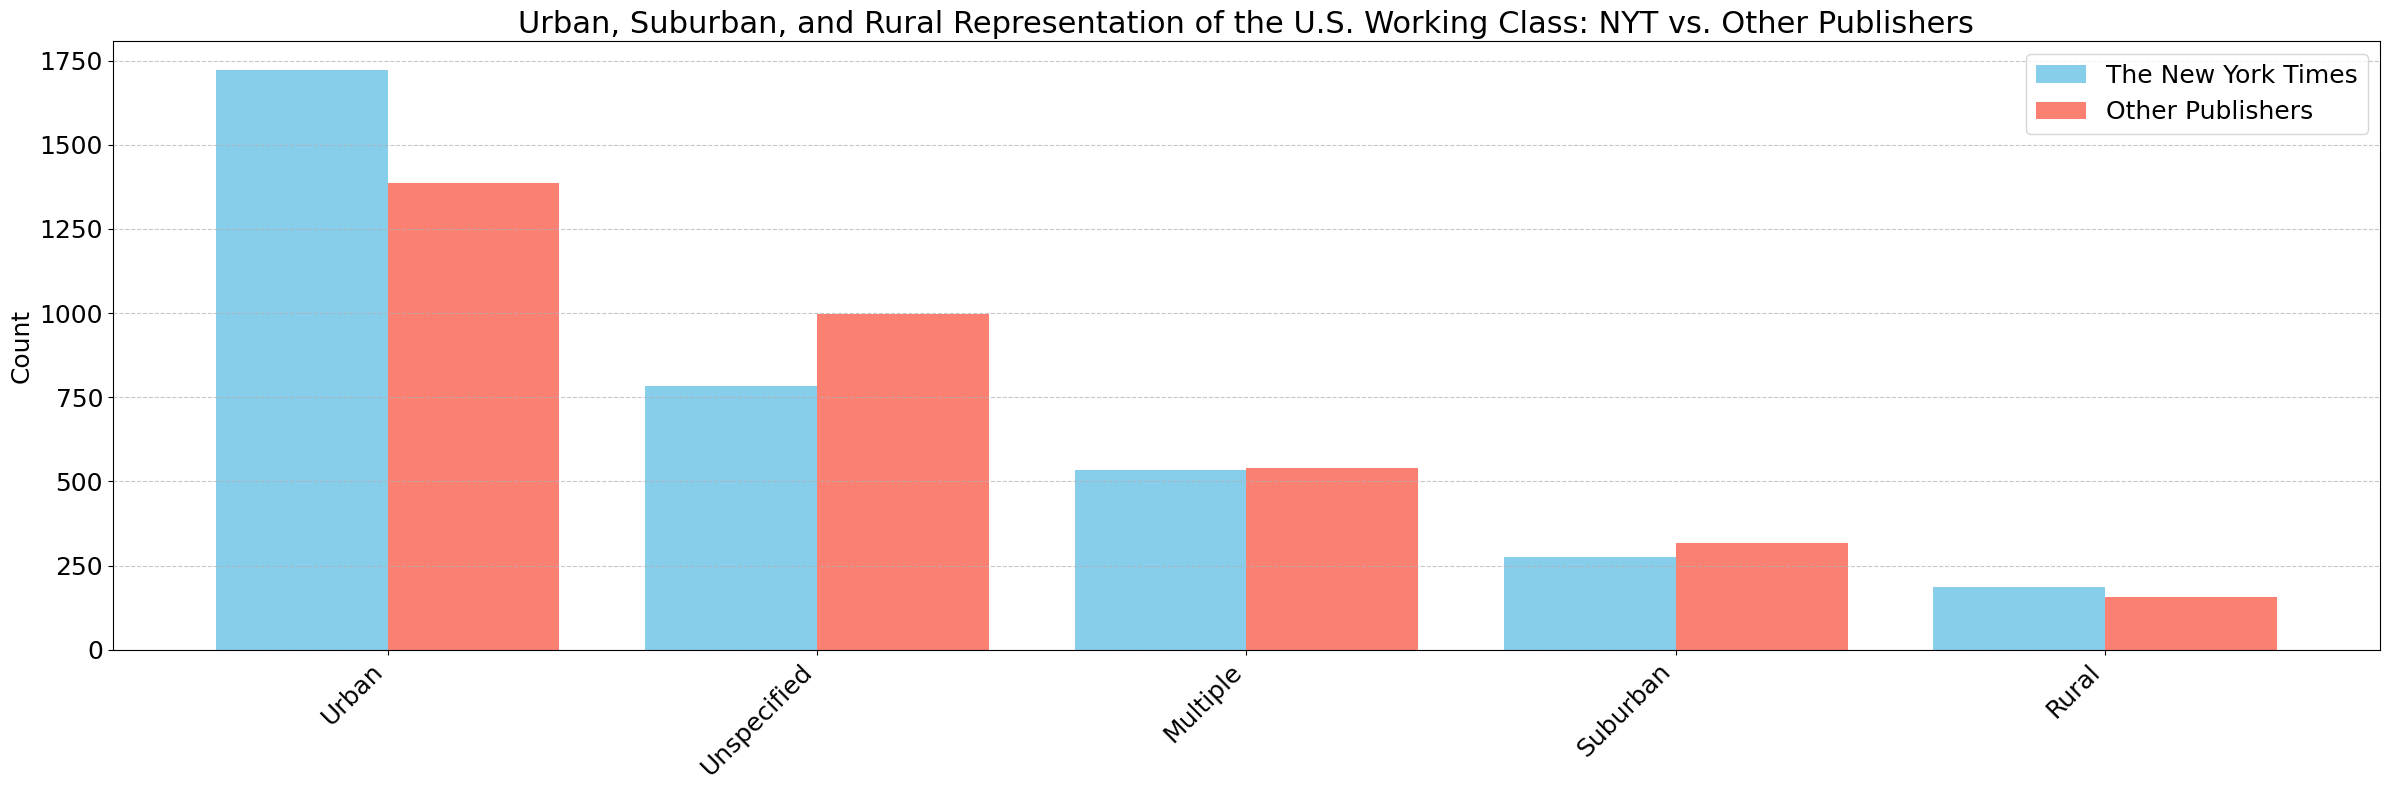

In [48]:
nyt_series = df_articles_with_results[nyt_mask]['setting_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['setting_stand_flat']

title = 'Urban, Suburban, and Rural Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_location_setting.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [49]:
var = 'setting_stand_flat'
var_original = 'locations'
save_examples_to_folder(var, df_articles_with_results, examples_dir, var_original)

✅ Articles saved successfully.


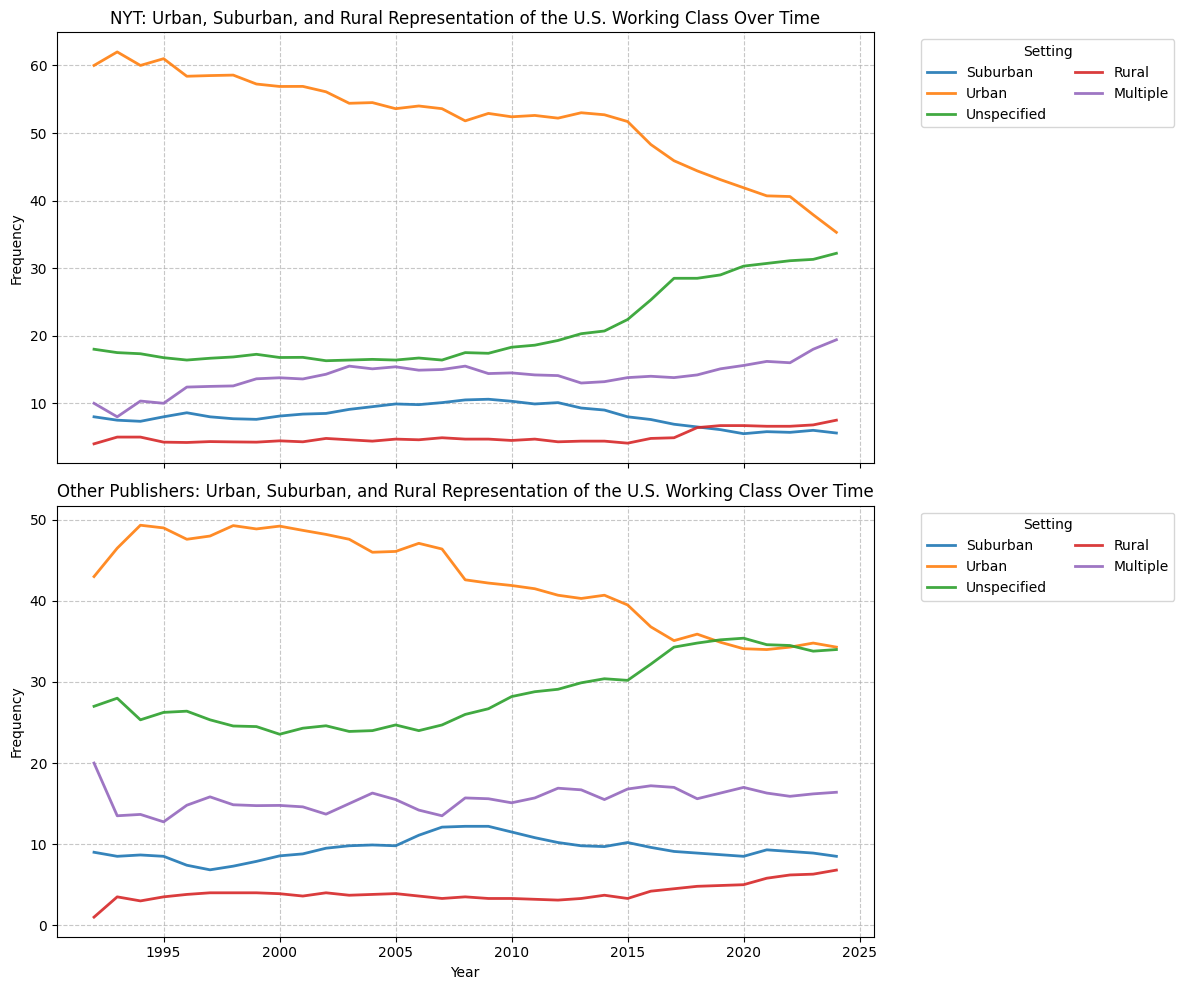

In [50]:
variable = 'setting_stand_flat'
filename = "../plots/comparison_setting_time_chart.png"
title = 'Urban, Suburban, and Rural Representation of the U.S. Working Class Over Time'
line_time_plot(df_articles_with_results[year_mask], nyt_mask[year_mask], variable, title, filename, variable_label="Setting", smooth_window=10)

To do:

* Track smoothing window (remove later)

<a id="occupations"></a>
### 3.2. Occupations  

[⬆ Return to Top](#table-of-contents) 

**Occupations** – What kinds of jobs does this working-class group hold? (List all that apply.) 
   - Categories: Manufacturing, Service, Construction, Administrative/Clerical, Transportation.
   - If "Other", please specify.

**Employment Type** – Are members of this working-class group primarily **self-employed (business owners)** or **employees**? If not specified, enter "NA."

Update:

* Updated prompt to reflect broader occupation categories and new employment type (business-owner vs employee) variable.


To do:

* After running new prompt, display updated charts +  employment type.

* Update occupation_categories below.

* Review option 1 vs option 2

In [51]:
for i in df_articles_with_results['occupations']:
    print(i)

['Other']
['NA']
['Other']
['Manufacturing and Industrial Jobs', 'Skilled Trades and Manual Labor', 'Service and Maintenance', 'Other']
['NA']
['NA']
['NA']
['NA']
['Other']
['NA']
['Manufacturing and Industrial Jobs', 'Skilled Trades and Manual Labor']
['Skilled Trades and Manual Labor', 'Service and Maintenance', 'Other']
['NA']
['Skilled Trades and Manual Labor', 'Fishing/Seafood (lobstermen)']
['Service and Maintenance', 'Administrative/Clerical (Secretary, Administrative Assistant, Data Entry)', 'Retail and Customer Service', 'Education (school system staff, aspiring teacher)', 'Other (managing rental homes)']
['Education (teachers, school aides, guidance counselor)', 'School administration (principal, assistant principal)']
['Retail and Customer Service']
['NA']
['Retail and Customer Service', 'Service and Maintenance', 'Food Service']
['NA']
['Skilled Trades and Manual Labor', 'Other (vocational training)']
['Skilled Trades and Manual Labor', 'Manufacturing and Industrial Jobs',

In [52]:
occupation_categories = ['Skilled Trades and Manual Labor',
              'Manufacturing and Industrial Jobs',
              'Service and Maintenance',
              'Transportation and Delivery',
              'Food Service',
              'Retail and Customer Service',
              'Health and Personal Care',
              'Other']

__Option 1: combine standardize and flattening (more efficient)__

In [53]:
def standardize_and_flatten(values_list, categories): # better function name?
    if len(values_list) > 1:
        return "Multiple" # to do: need to address issue that sometimes after standardization, values are repeated => could not actually be mixed
    if len(values_list) == 0 or values_list == ["NA"]:
        return "Unspecified"
    value = values_list[0]
    for cat in categories:
        if cat in value:
            return cat
    # to do: use a secondary LLM to categorize
    return "Other"
    

In [54]:
df_articles_with_results["occupations_stand_flat"] = df_articles_with_results["occupations"].apply(lambda x:
                                                                                              standardize_and_flatten(x, occupation_categories))


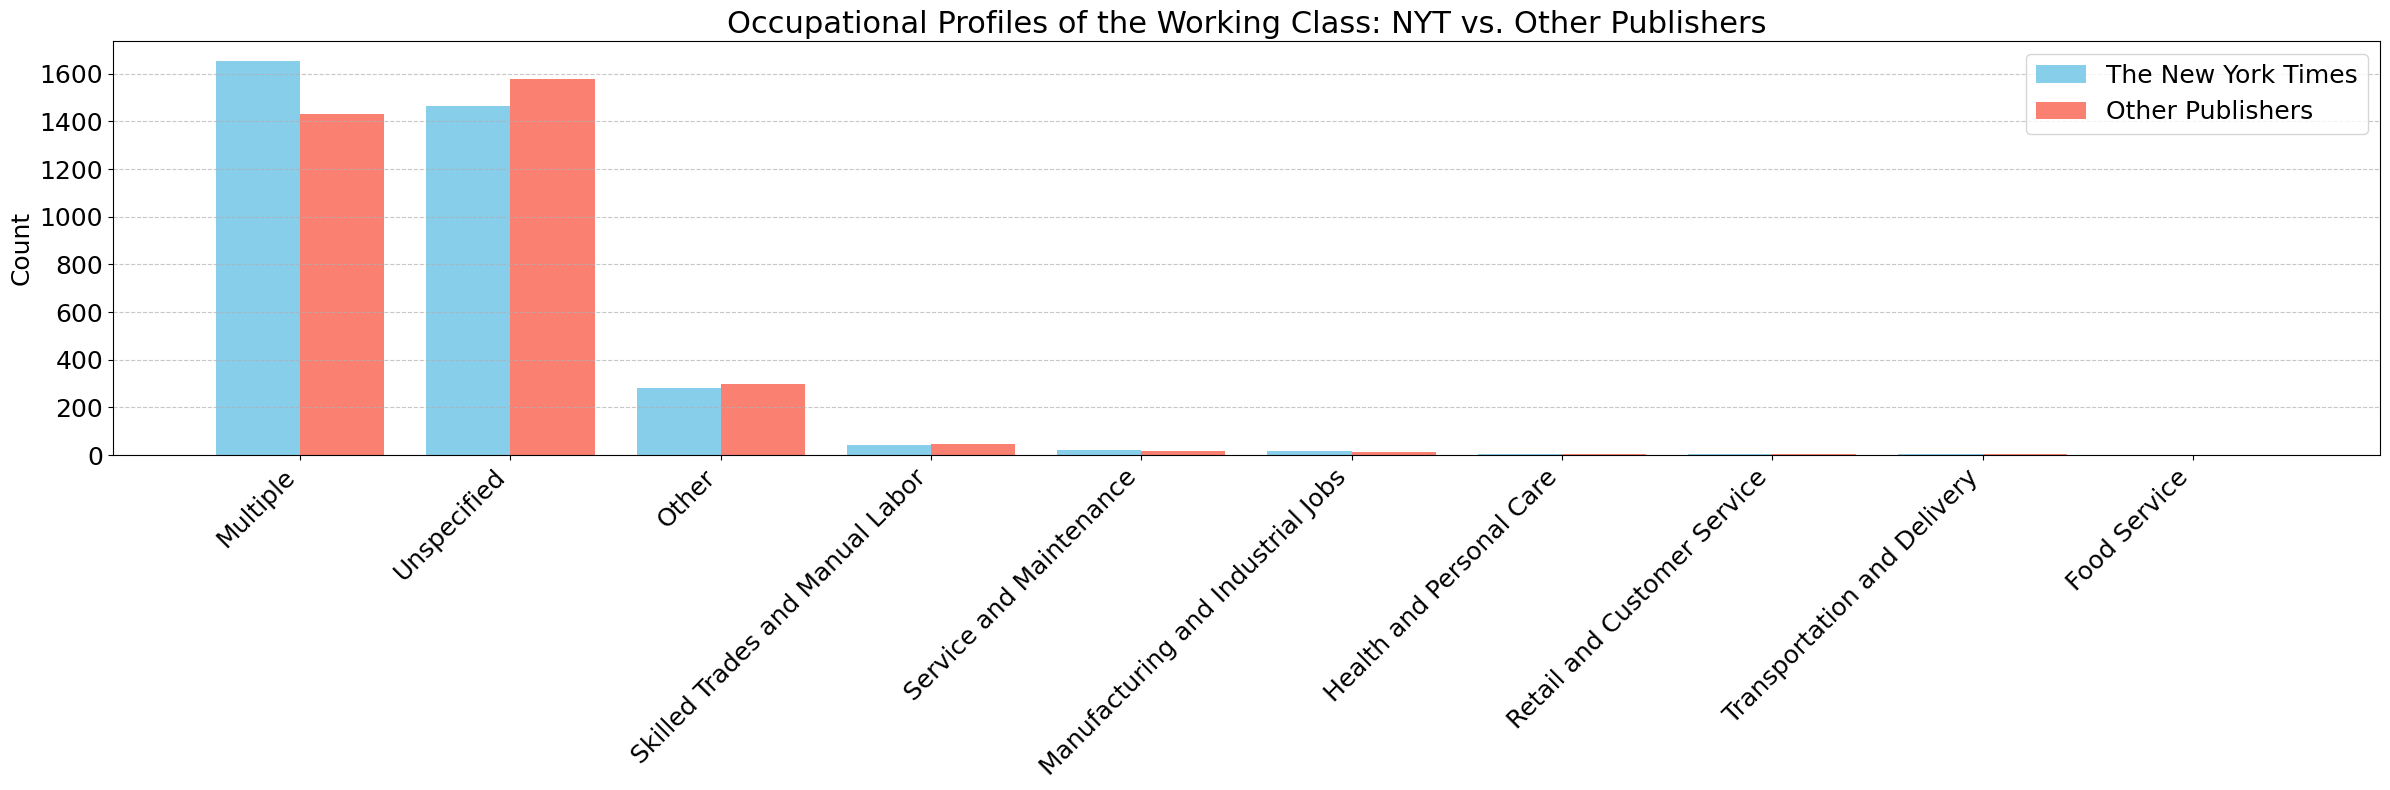

In [55]:
nyt_series = df_articles_with_results[nyt_mask]['occupations_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['occupations_stand_flat']

title = "Occupational Profiles of the Working Class: NYT vs. Other Publishers"
filename = "../plots/comparison_occupations.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

__Option 2: standardize and flatten seperately to view inside the "Mixed category"__

In [56]:
def standardize(values_list, categories):
    stand_list = []
    if values_list == ["NA"]:
        return []
    for value in values_list:
        for cat in categories:
            if cat.lower() in value.lower():
                stand_list.append(cat)
                break
            # if reached here, not found
            # to do: use a secondary LLM to categorize
            stand_list.append("Other")
    return list(set(stand_list))

def flatten_column(stand_values):
    if len(stand_values) > 1:
        return "Multiple"
    if len(stand_values) == 0:
        return "Unspecified"
    return stand_values[0]

In [57]:
df_articles_with_results["occupations_stand"] = df_articles_with_results["occupations"].apply(lambda x: standardize(x, occupation_categories))
df_articles_with_results["occupations_flat"] = df_articles_with_results["occupations_stand"].apply(flatten_column)

In [58]:
all_occupations_nyt = flatten(df_articles_with_results[nyt_mask]["occupations_stand"])
all_occupations_other = flatten(df_articles_with_results[~nyt_mask]["occupations_stand"])

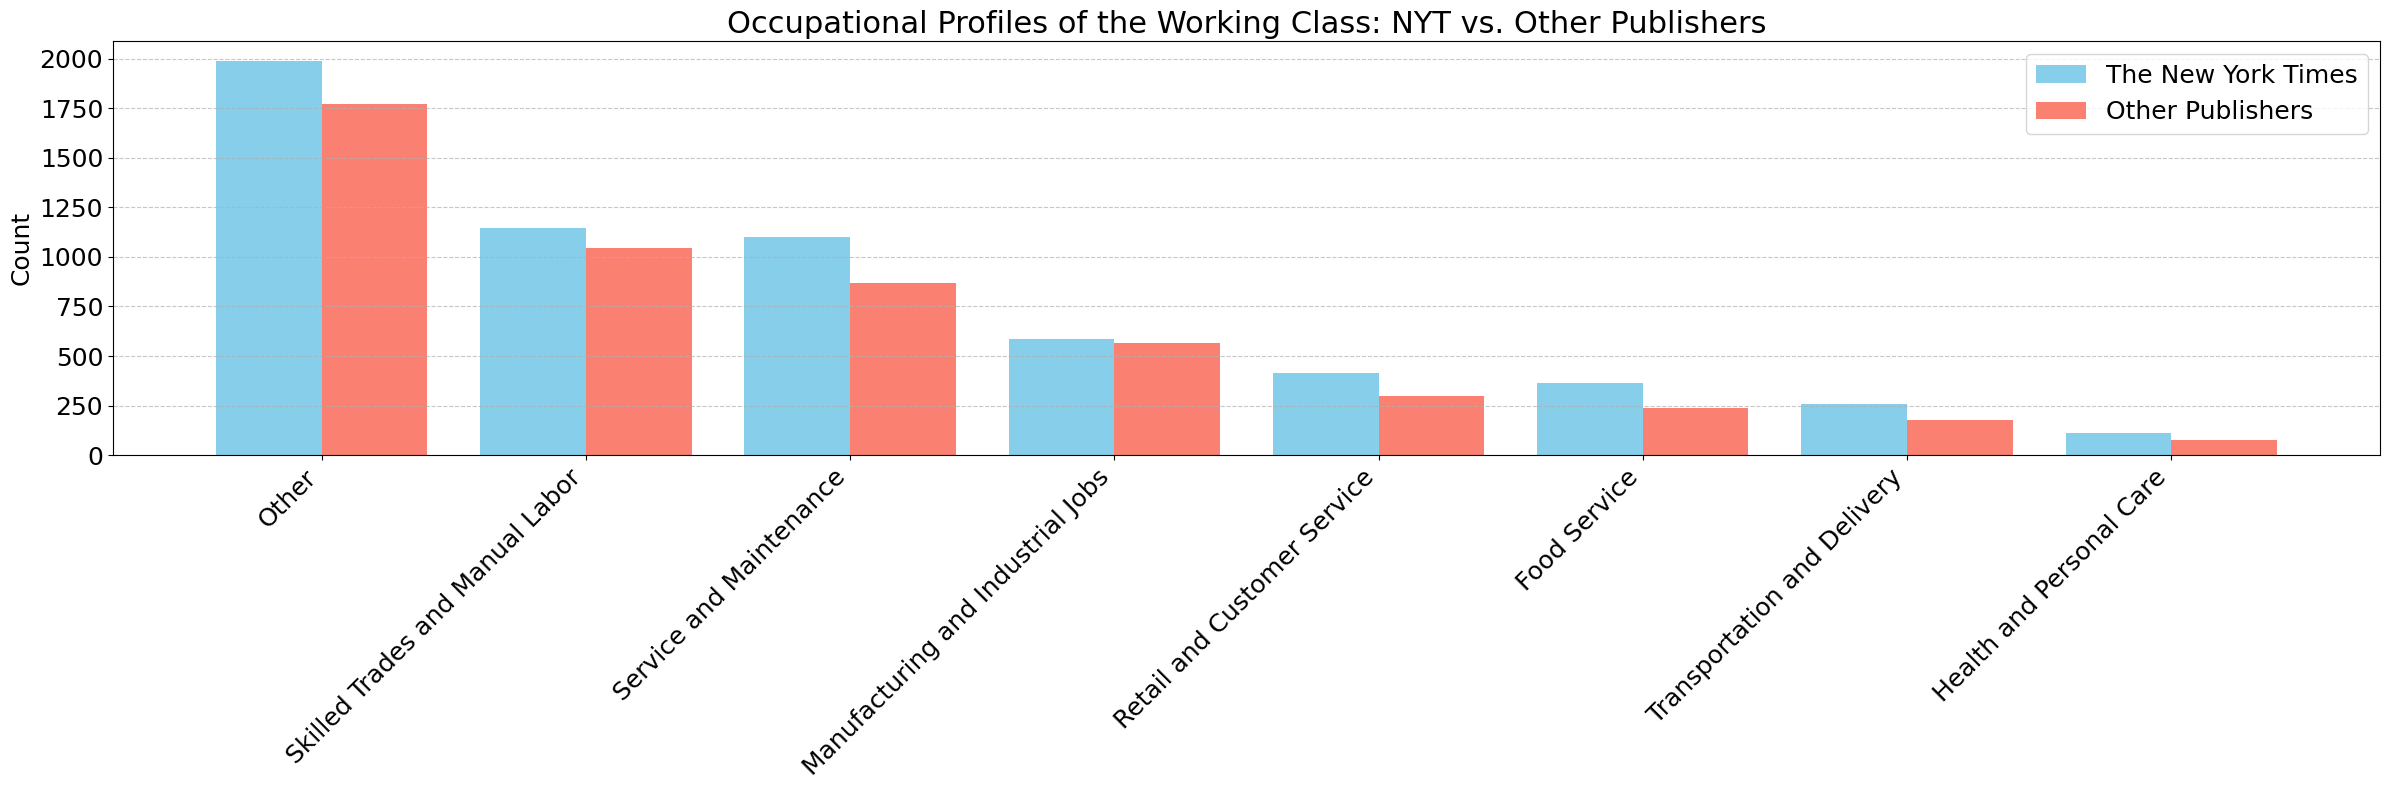

In [59]:
title = "Occupational Profiles of the Working Class: NYT vs. Other Publishers"
filename = "../plots/comparison_occupations_all.png"

compare_histograms(all_occupations_nyt, all_occupations_other, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [60]:
var = 'occupations_stand_flat'
save_examples_to_folder(var, df_articles_with_results, examples_dir, var_original)

✅ Articles saved successfully.


<a id="race-ethnicity"></a>
### 3.3. Race/Ethnicity  

[⬆ Return to Top](#table-of-contents) 

What racial or ethnic backgrounds are identified for this working-class group?  

In [61]:
race_ethnicity_categories = ['White', 'Black or African American',
                             'American Indian or Alaska Native', 'Asian', 'Native Hawaiian or Other Pacific Islander']

In [62]:
import re

In [63]:
df_articles_with_results['race_ethnicity_list'] = df_articles_with_results['race_ethnicity'].apply(lambda x: re.split(';|,', x))
df_articles_with_results['race_ethnicity_stand_flat'] = df_articles_with_results['race_ethnicity_list'].apply(lambda x: standardize_and_flatten(x, race_ethnicity_categories))

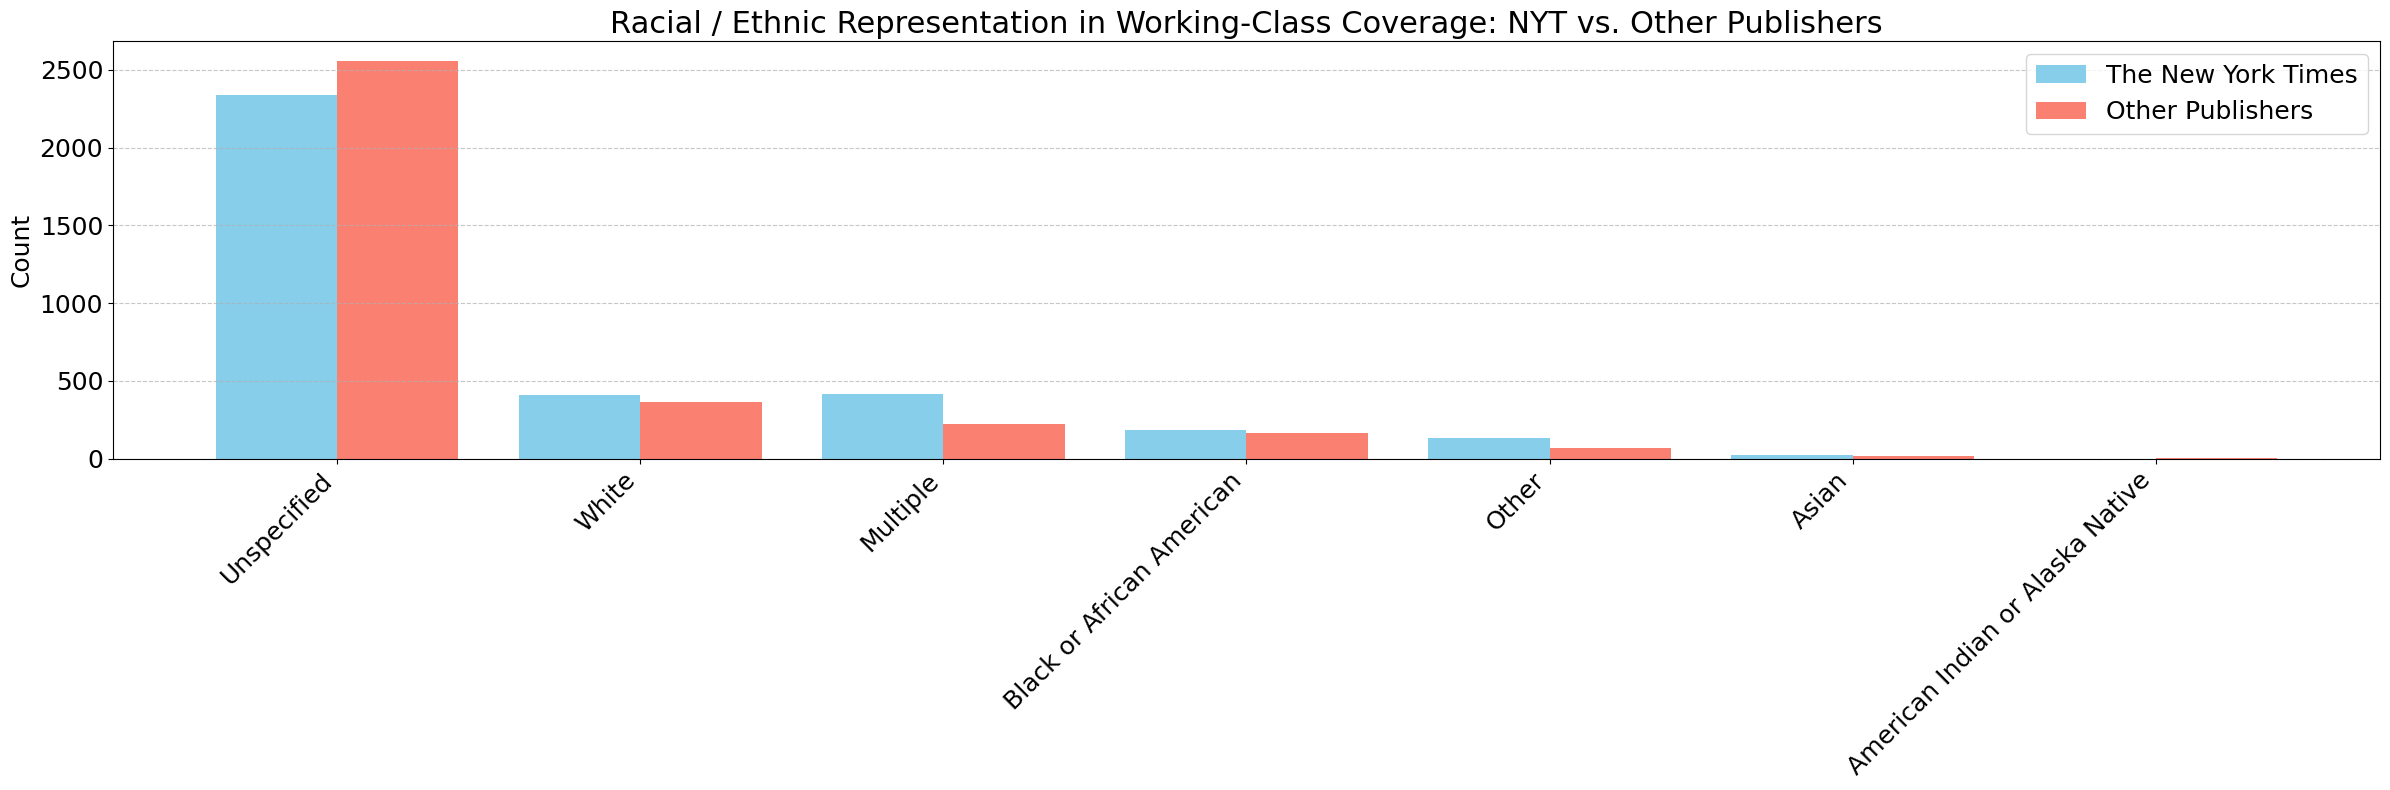

In [64]:
nyt_series = df_articles_with_results[nyt_mask]['race_ethnicity_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['race_ethnicity_stand_flat']

title = 'Racial / Ethnic Representation in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_race_ethnicity.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [65]:
var =  'race_ethnicity_stand_flat'
save_examples_to_folder(var, df_articles_with_results, examples_dir)

✅ Articles saved successfully.


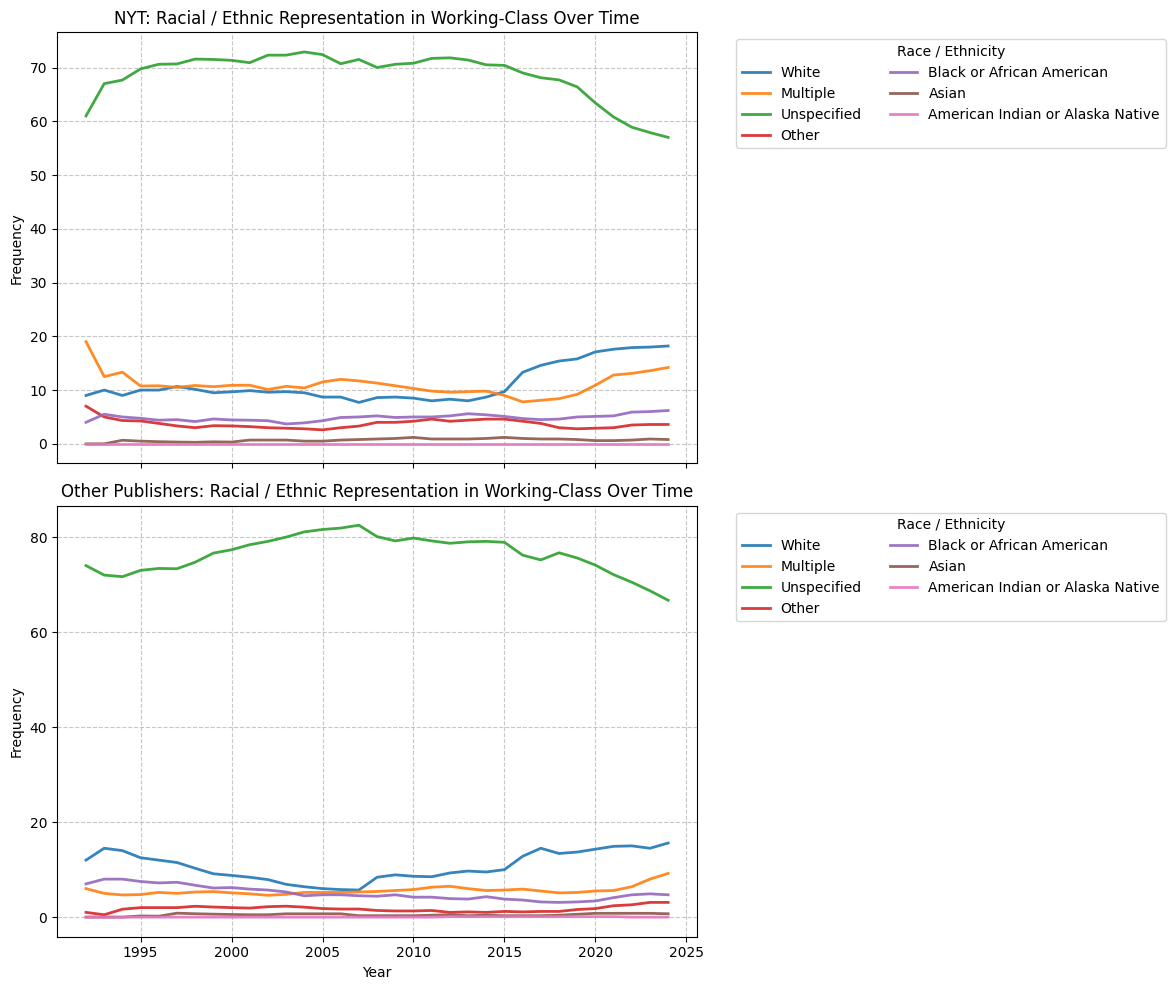

In [66]:
variable = 'race_ethnicity_stand_flat'
filename = "../plots/comparison_race_ethnicity_time_chart.png"
title = 'Racial / Ethnic Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results[year_mask], nyt_mask[year_mask], variable, title, filename, variable_label="Race / Ethnicity", smooth_window=10)

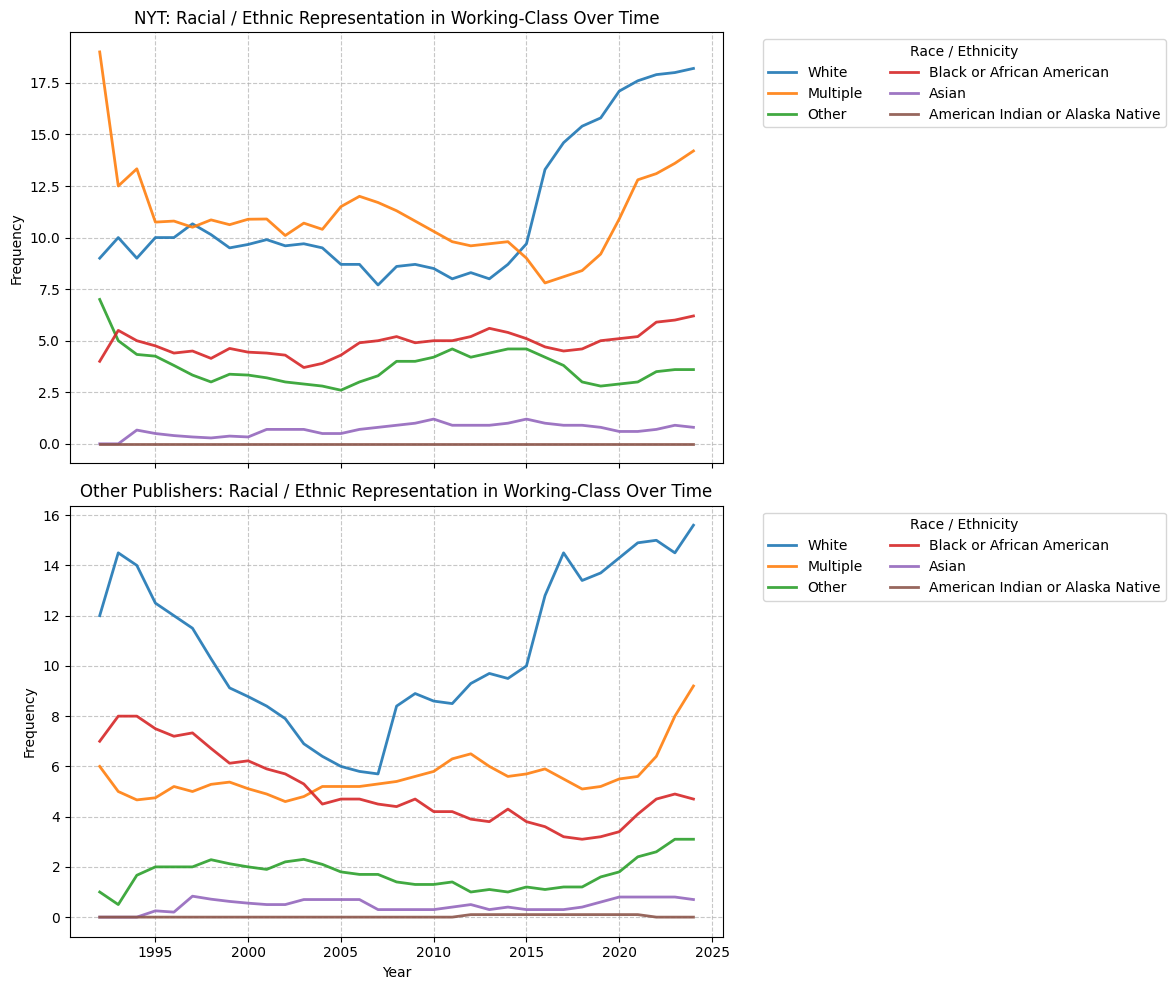

In [67]:
exclude = 'Unspecified'

df_articles_with_results_filter = df_articles_with_results.loc[df_articles_with_results['race_ethnicity_stand_flat'] != "Unspecified"]

nyt_mask_filter = df_articles_with_results_filter["publisher"] == "New York Times"
year_mask_filter = df_articles_with_results_filter["year"] > 1991


variable = 'race_ethnicity_stand_flat'
filename = "../plots/comparison_race_ethnicity_time_chart.png"
title = 'Racial / Ethnic Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results_filter[year_mask_filter], nyt_mask_filter[year_mask_filter], variable, title, filename, variable_label="Race / Ethnicity", smooth_window=10)


To do:


* See in progress function below

<a id="gender"></a>
### 3.4. Gender  

[⬆ Return to Top](#table-of-contents)  

What is the gender composition of the working-class group?  

To do:

* Put examples of "Other" in the bin.

* Look into "Other" more deeply

* "Mostly Men" --> "Men"; same with woman

In [68]:
df_articles_with_results["gender"].value_counts()

gender
NA                                                                                                                     4294
Mixed                                                                                                                  1158
Mostly men                                                                                                              199
Mostly women                                                                                                            157
Mixed (men and women)                                                                                                    60
                                                                                                                       ... 
Mostly men (referenced as 'protesters' being observed; working-class neighborhood residents described male subject)       1
Mostly women (working-class lesbians/women)                                                                               1
M

In [69]:
gender_categories = ["Mostly Women", "Mostly Men", "Mixed", "Nonbinary"] # Plus Unspecified

# To do: See "Mixed" here

In [70]:
# Note: already flat

def standardize_value(value, categories):
    if value == "NA":
        return "Unspecified"
    for cat in categories:
        if cat.lower() in value.lower():
            return cat
    return "Other"

In [71]:
df_articles_with_results["gender_stand"] = df_articles_with_results["gender"].apply(lambda x: standardize_value(x, gender_categories))

Question for Elena:

* Better gender categories?

* Review question to LLM

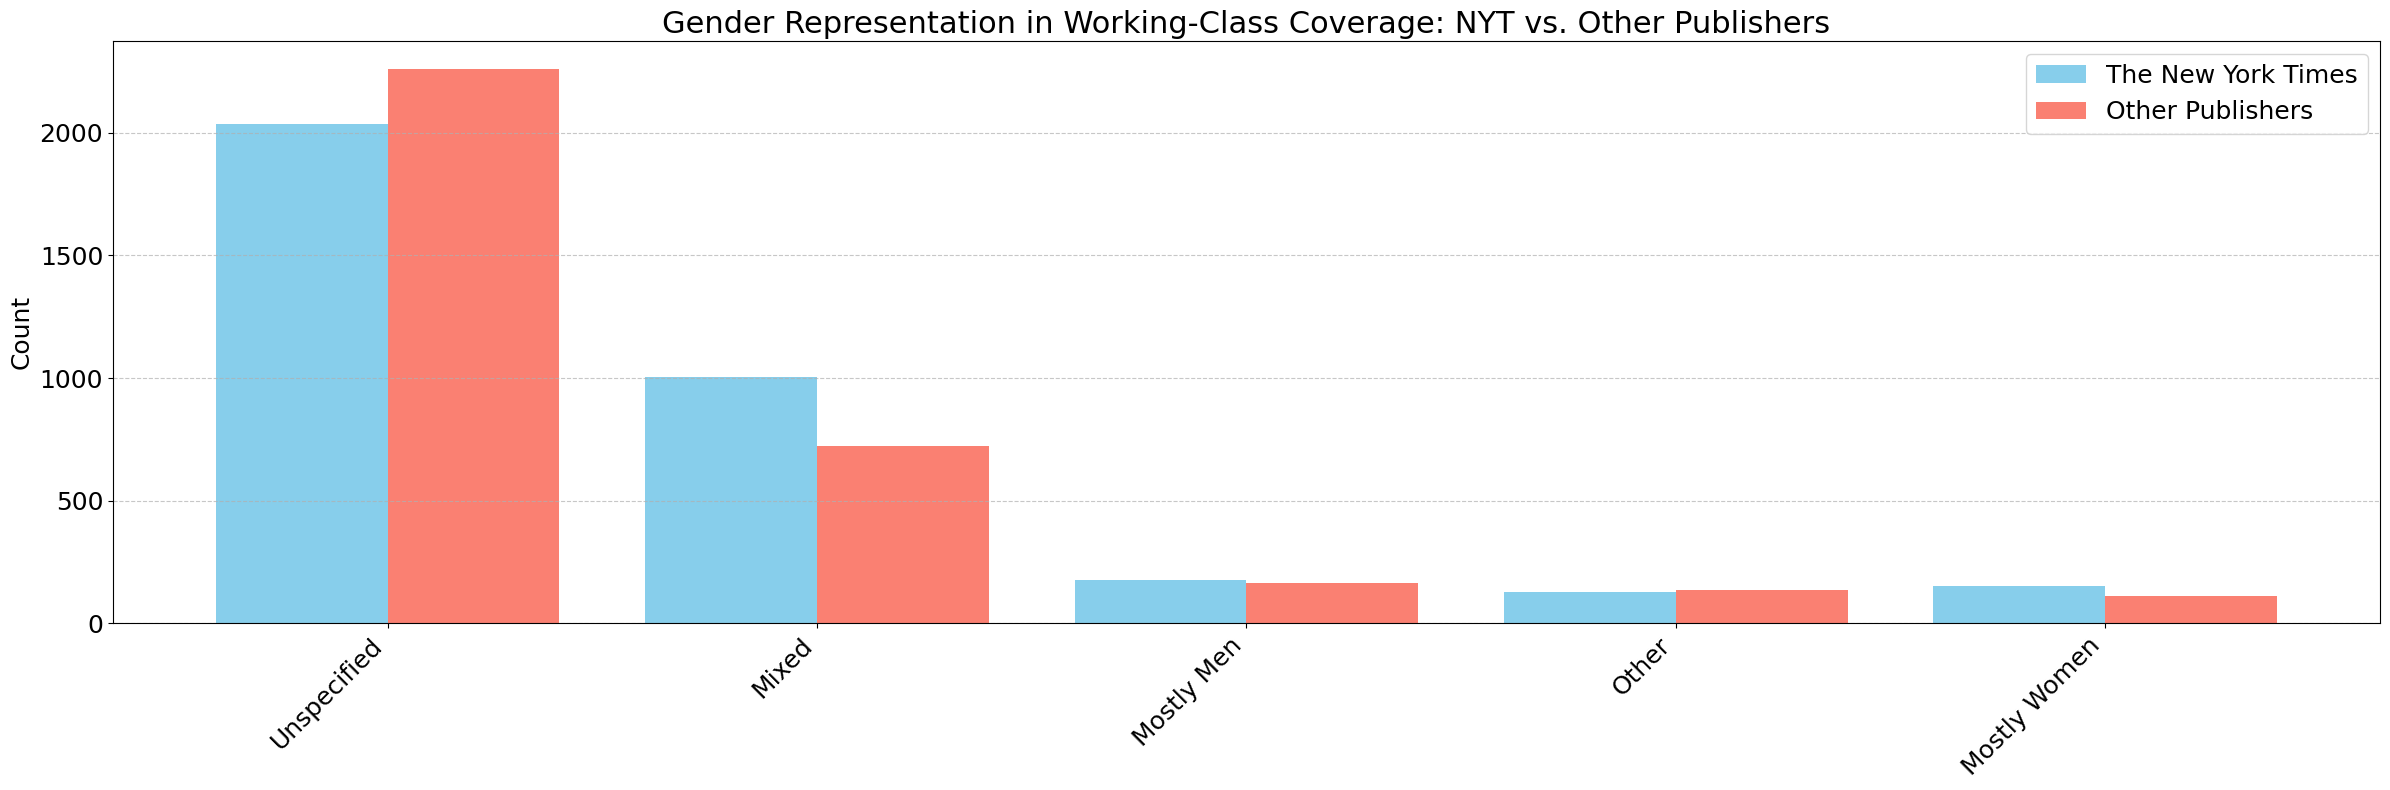

In [72]:
nyt_series = df_articles_with_results[nyt_mask]['gender_stand']
other_series = df_articles_with_results[~nyt_mask]['gender_stand']

title = 'Gender Representation in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_gender.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [73]:
var = 'gender_stand'
save_examples_to_folder(var, df_articles_with_results, examples_dir)

✅ Articles saved successfully.


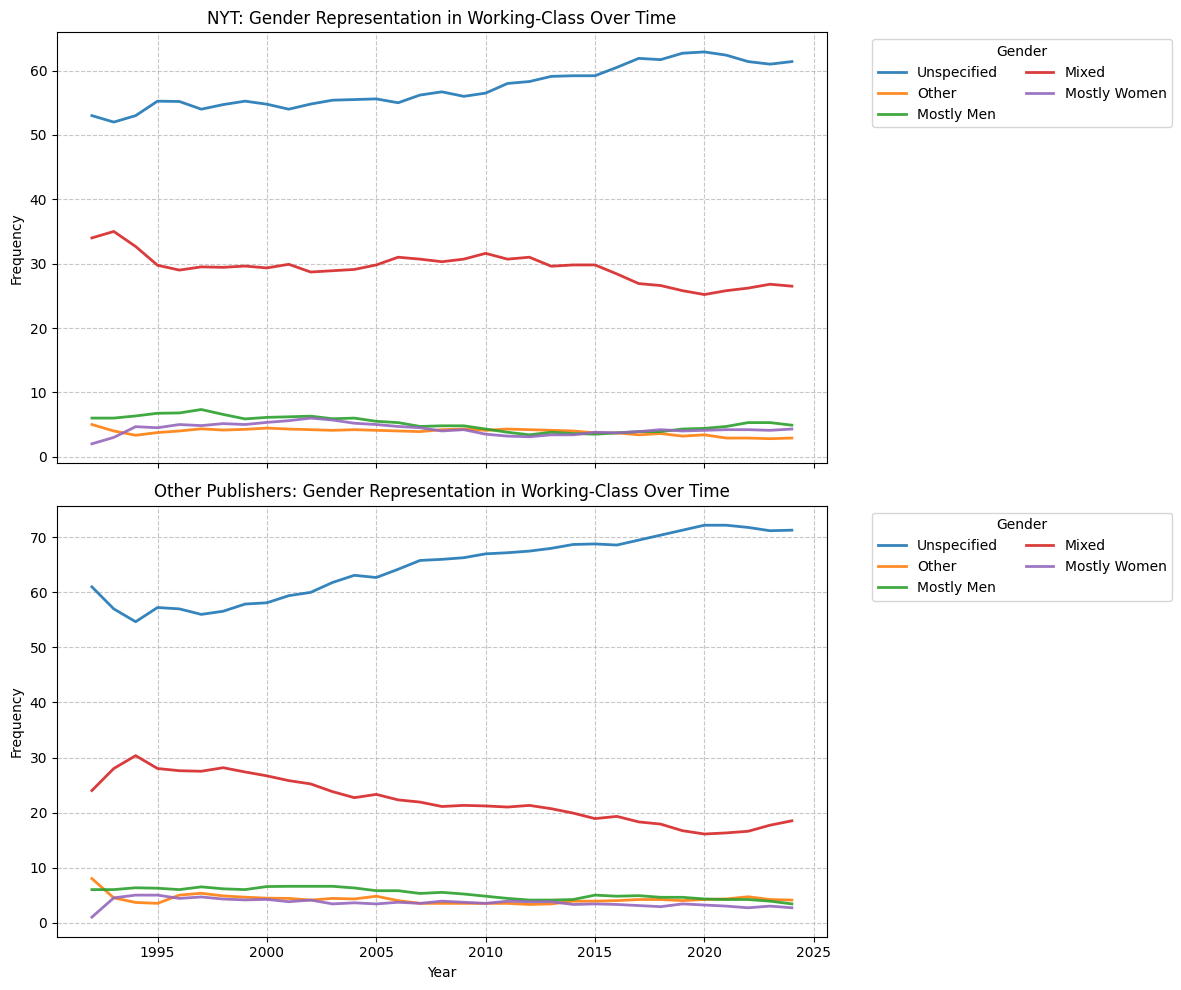

In [74]:
variable = 'gender_stand'
filename = "../plots/comparison_gender_time_chart.png"
title = 'Gender Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results[year_mask], nyt_mask[year_mask], variable, title, filename, variable_label="Gender", smooth_window=10)

To do:
* Review variable_label in time chart
* Review file names

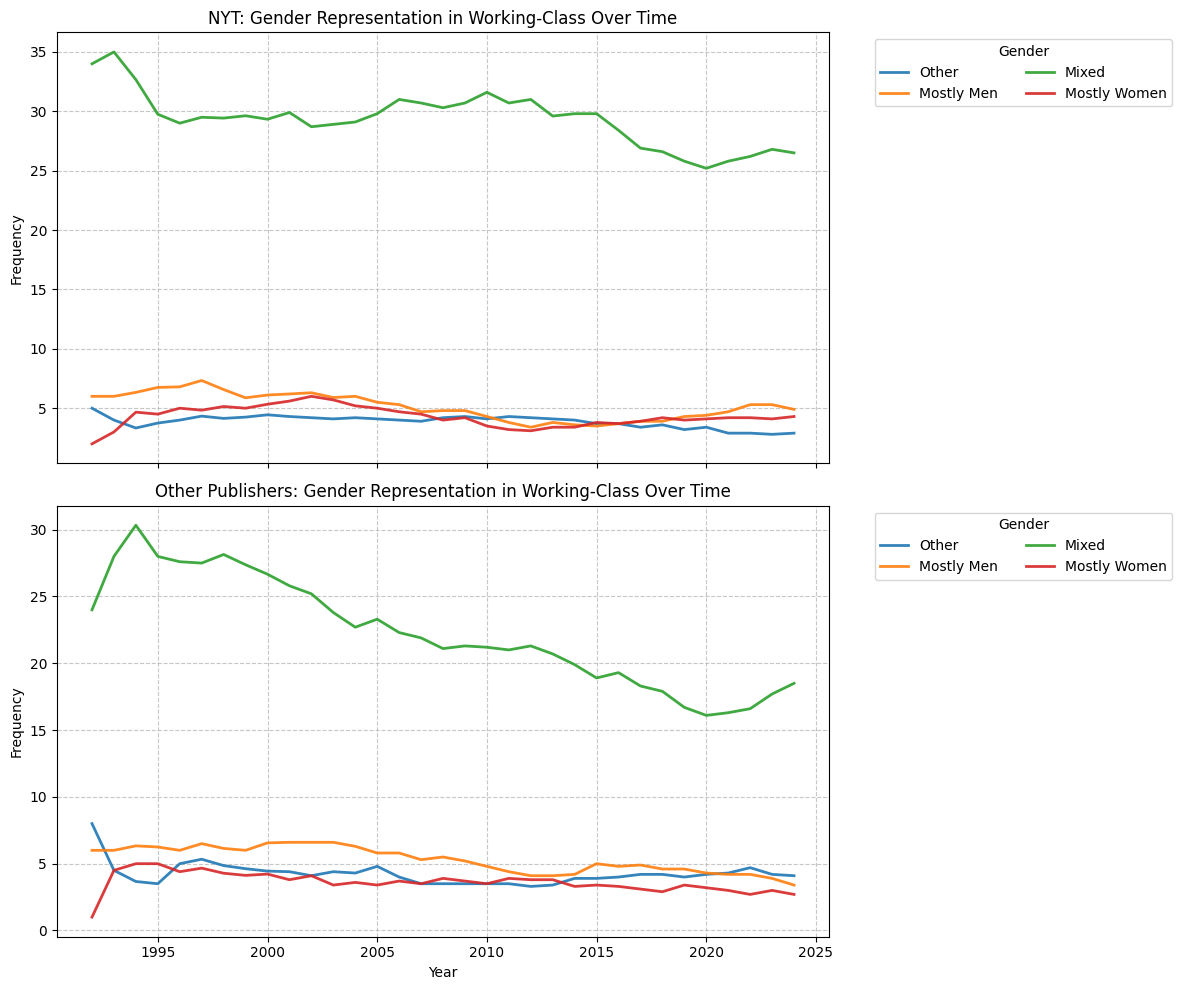

In [75]:
exclude = ['Unspecified'] # ['Unspecified', 'Mixed']

df_articles_with_results_filter = df_articles_with_results.loc[~df_articles_with_results['gender_stand'].isin(exclude)]

nyt_mask_filter = df_articles_with_results_filter["publisher"] == "New York Times"
year_mask_filter = df_articles_with_results_filter["year"] > 1991




variable = 'gender_stand'
filename = "../plots/comparison_gender_time_chart_filter.png"
title = 'Gender Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results_filter[year_mask_filter], nyt_mask_filter[year_mask_filter], variable, title, filename, variable_label="Gender", smooth_window=10)



<a id="education"></a>
### 3.5. Education  

[⬆ Return to Top](#table-of-contents)  

What education levels are mentioned for this working-class group? (Examples: less than high school, high school diploma, some college, college degree, vocational/technical training, NA.)  

To do:

* Remove from LLM call

In [76]:
education_categories = 'less than high school', 'high school diploma', 'some college', 'college degree', 'vocational/technical training'

In [77]:
df_articles_with_results["education_stand"] = df_articles_with_results["education"].apply(lambda x: standardize_value(x, education_categories))

In [78]:
df_articles_with_results[["education", "education_stand"]]

,education,education_stand
0,NA,Unspecified
1,NA,Unspecified
2,NA,Unspecified
3,NA,Unspecified
4,NA,Unspecified
...,...,...
6892,NA,Unspecified
6893,High school diploma or less; low college degre...,high school diploma
6894,NA,Unspecified
6895,NA,Unspecified


In [79]:
df_articles_with_results["education"].iloc[6893]

"High school diploma or less; low college degree attainment (many lack bachelor's degrees; drop in higher-education enrollment among Latino men)"

In [80]:
df_articles_with_results.loc[df_articles_with_results["education_stand"] == "Other"][["education", "education_stand"]]

,education,education_stand
20,Vocational high school (working-class youths a...,Other
23,"Some attended boarding schools, elite public h...",Other
28,High school,Other
30,High school (implied for many); NA,Other
39,Unlettered (implied low formal education),Other
...,...,...
6802,Low education levels mentioned (areas where ed...,Other
6807,Mixed (includes college-educated and non-colle...,Other
6811,High school graduates / recent high-school sen...,Other
6853,Varied — some with limited formal schooling (n...,Other


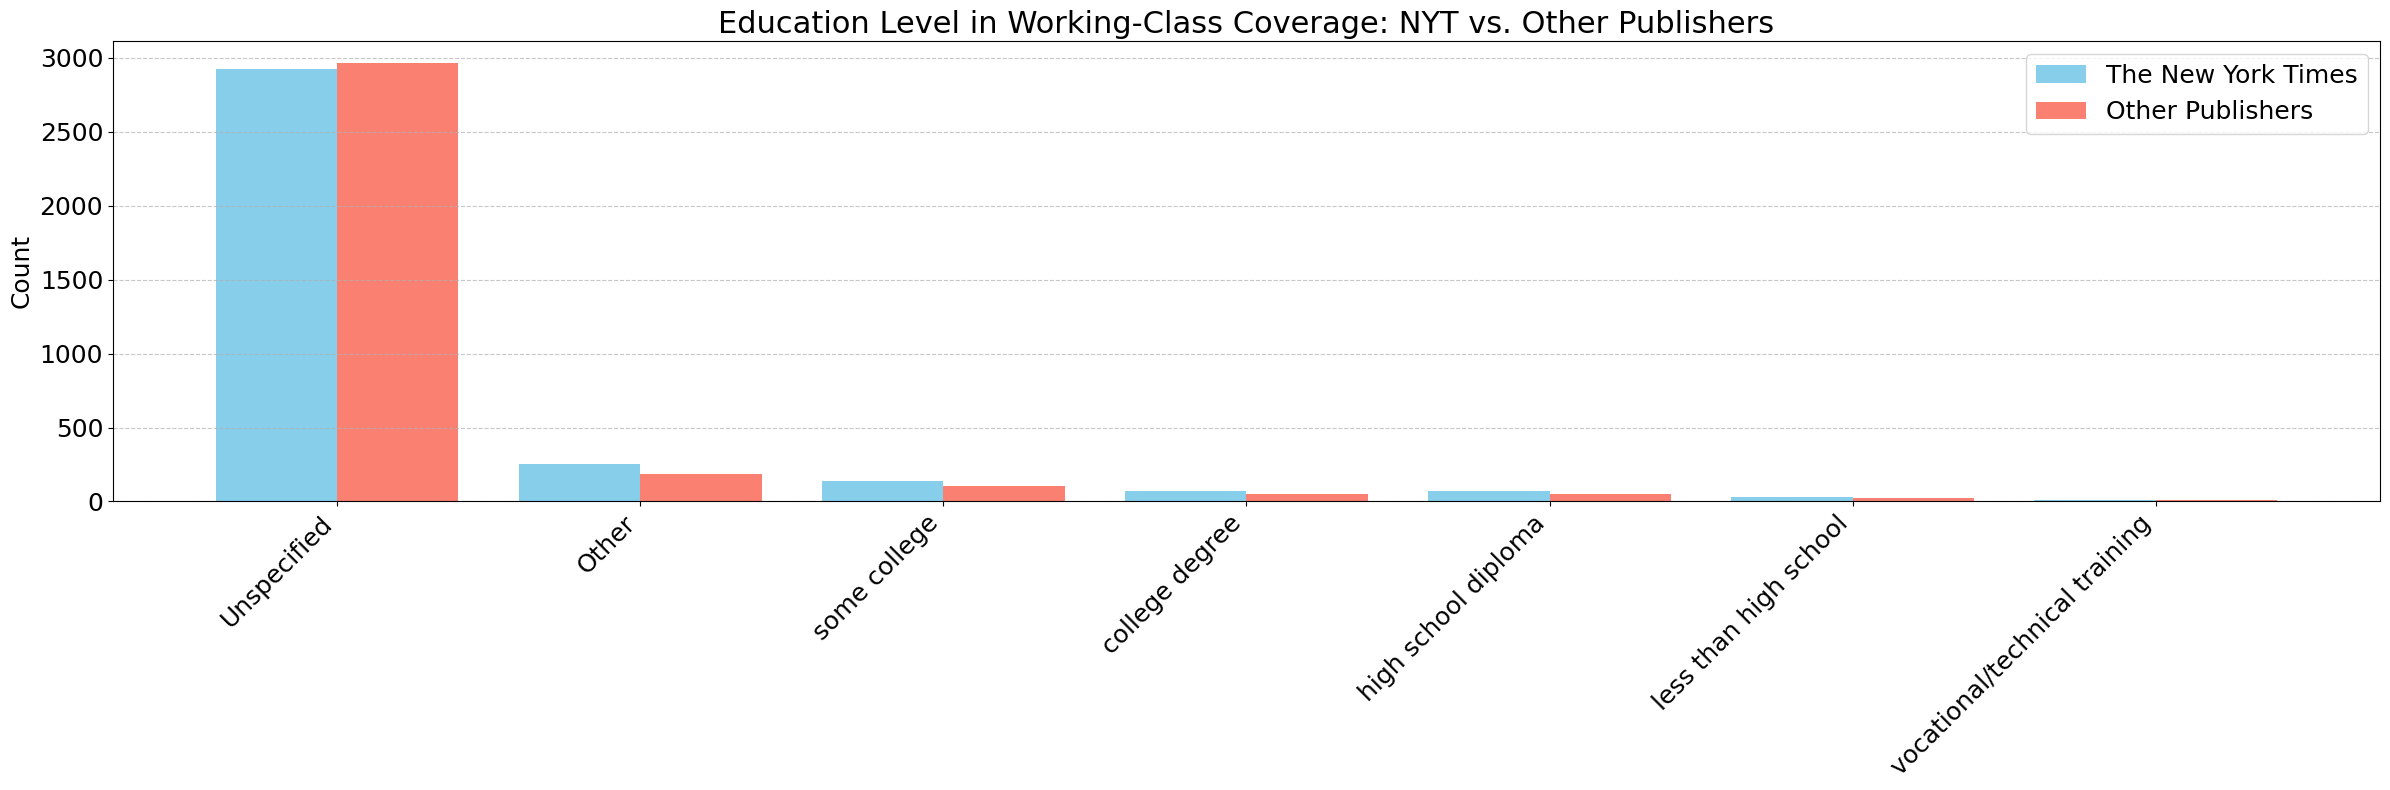

In [81]:
nyt_series = df_articles_with_results[nyt_mask]['education_stand']
other_series = df_articles_with_results[~nyt_mask]['education_stand']

title = 'Education Level in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_education.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

Note for Elena:

* confirm definitions including examples / categories.

* Look into other?

* very low counts => probably will still be relatively low even with bigger sample. May want to exclude from analysis.

<a id="immigration-status"></a>
### 3.6. Immigration Status  

[⬆ Return to Top](#table-of-contents)  

What is the immigration status of the working-class group? (Examples: immigrants, undocumented workers, refugees, naturalized citizens, citizens, NA.)  

To do:

* Binary category: immigrant / guest workers / refugees, or not. (if multiple --> immigrants)

In [82]:
immigration_categories = ["Immigrants", "Undocumented workers", "Refugees", "Naturalized citizens", "Citizens"]

In [83]:
df_articles_with_results["immigration_status_stand"] = df_articles_with_results["immigration_status"].apply(lambda x: standardize_value(x, immigration_categories))

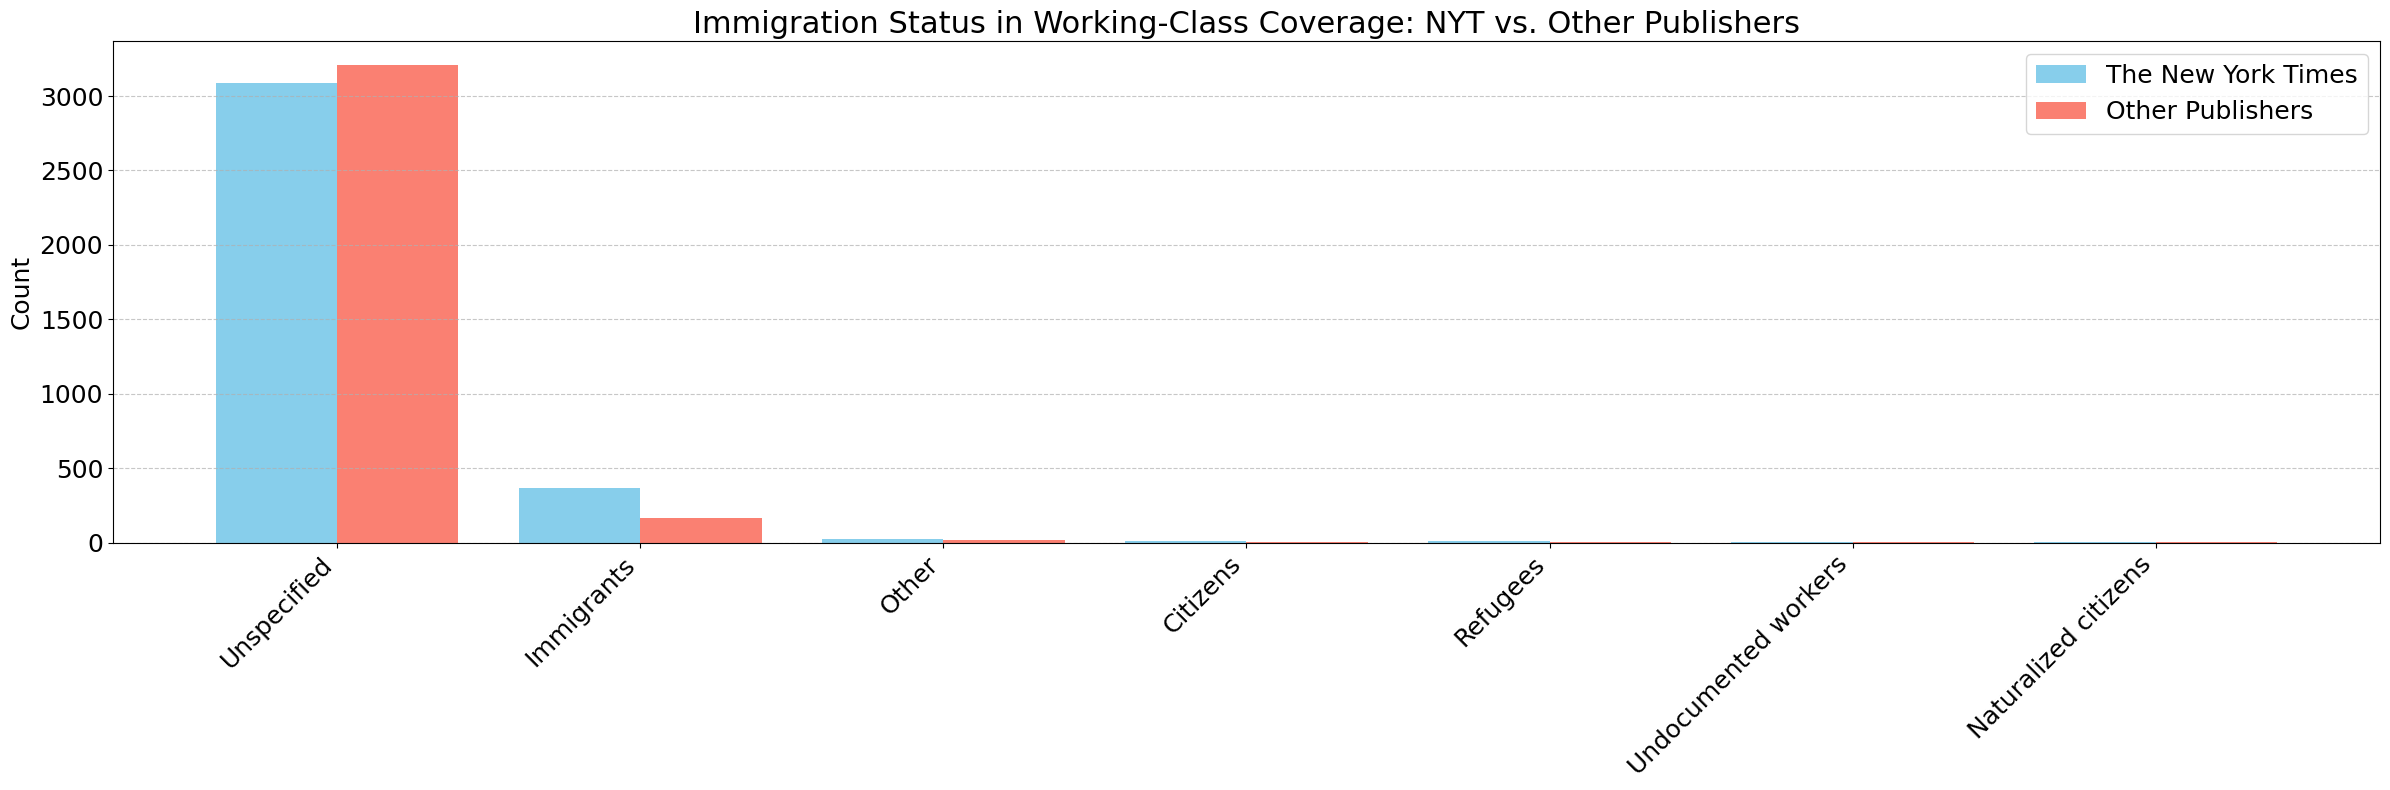

In [84]:
nyt_series = df_articles_with_results[nyt_mask]['immigration_status_stand']
other_series = df_articles_with_results[~nyt_mask]['immigration_status_stand']

title = 'Immigration Status in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_immigration.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [85]:
var = "immigration_status_stand"
save_examples_to_folder(var, df_articles_with_results, examples_dir)

✅ Articles saved successfully.


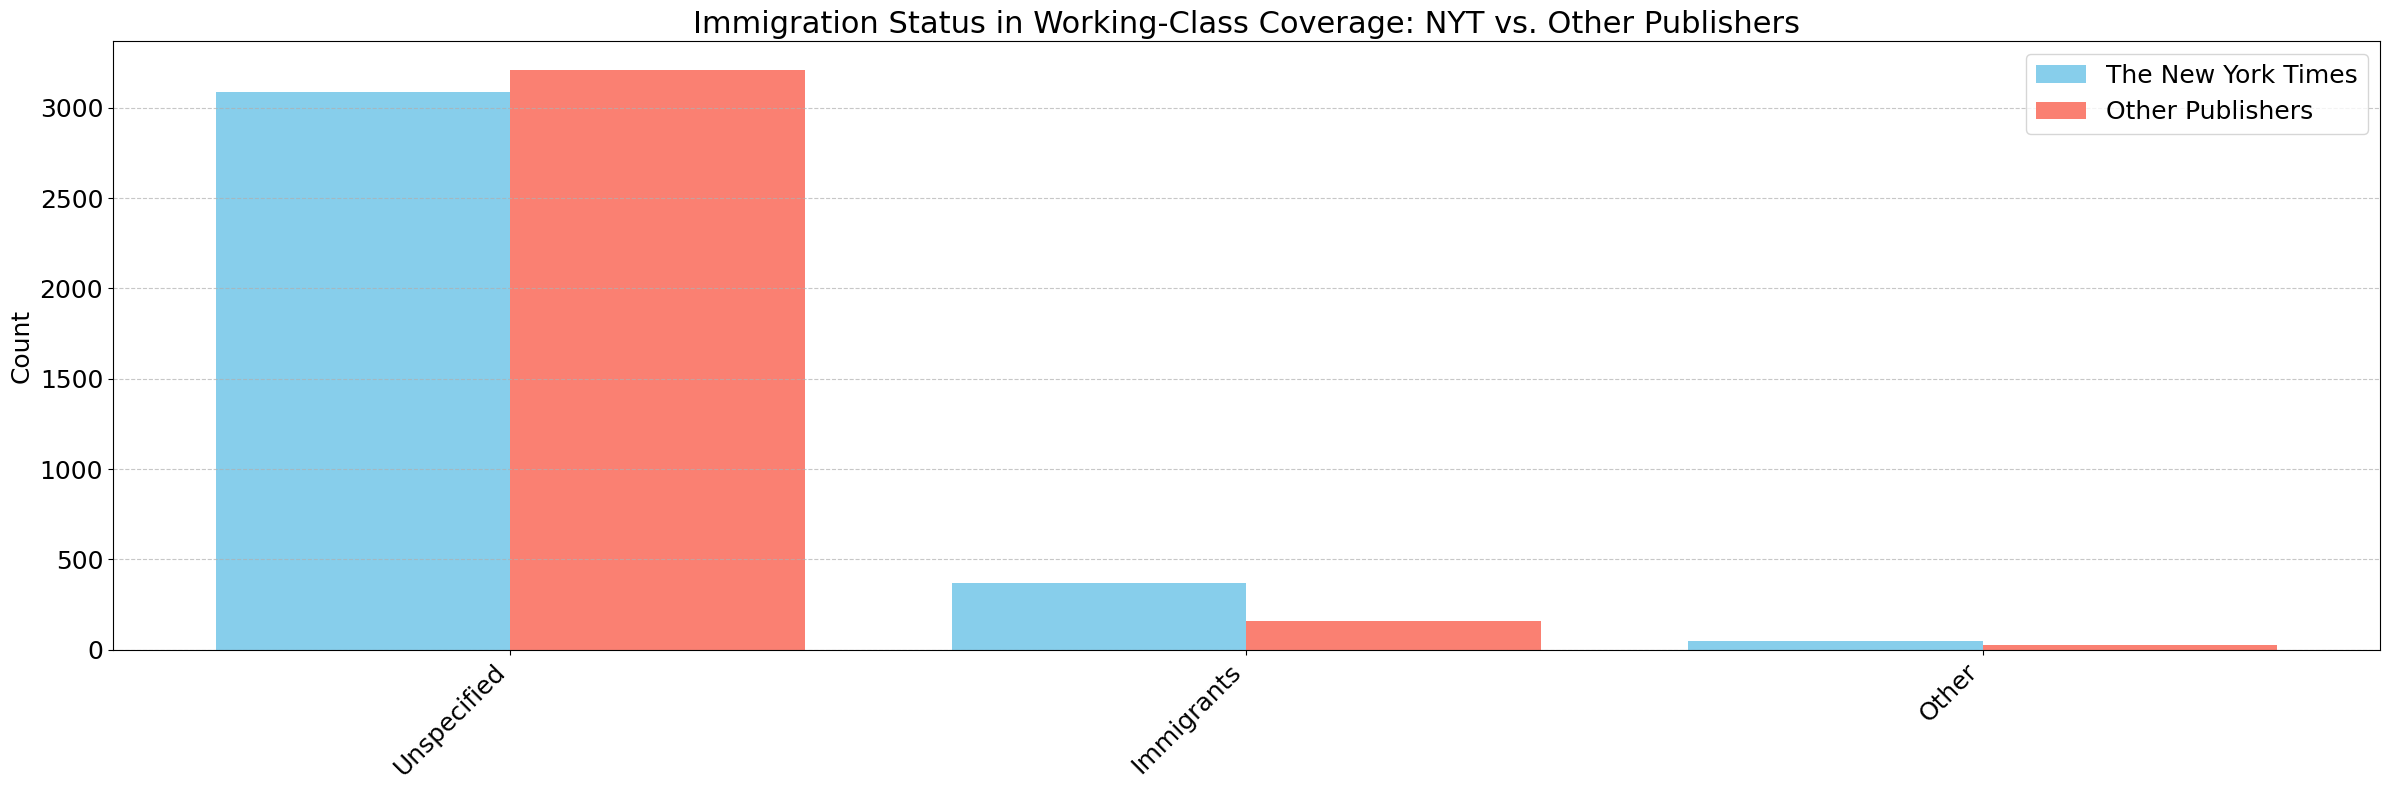

In [86]:
immigration_categories = ["Immigrants"]
df_articles_with_results["immigration_status_stand"] = df_articles_with_results["immigration_status"].apply(lambda x: standardize_value(x, immigration_categories))
nyt_series = df_articles_with_results[nyt_mask]['immigration_status_stand']
other_series = df_articles_with_results[~nyt_mask]['immigration_status_stand']

title = 'Immigration Status in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_immigration.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

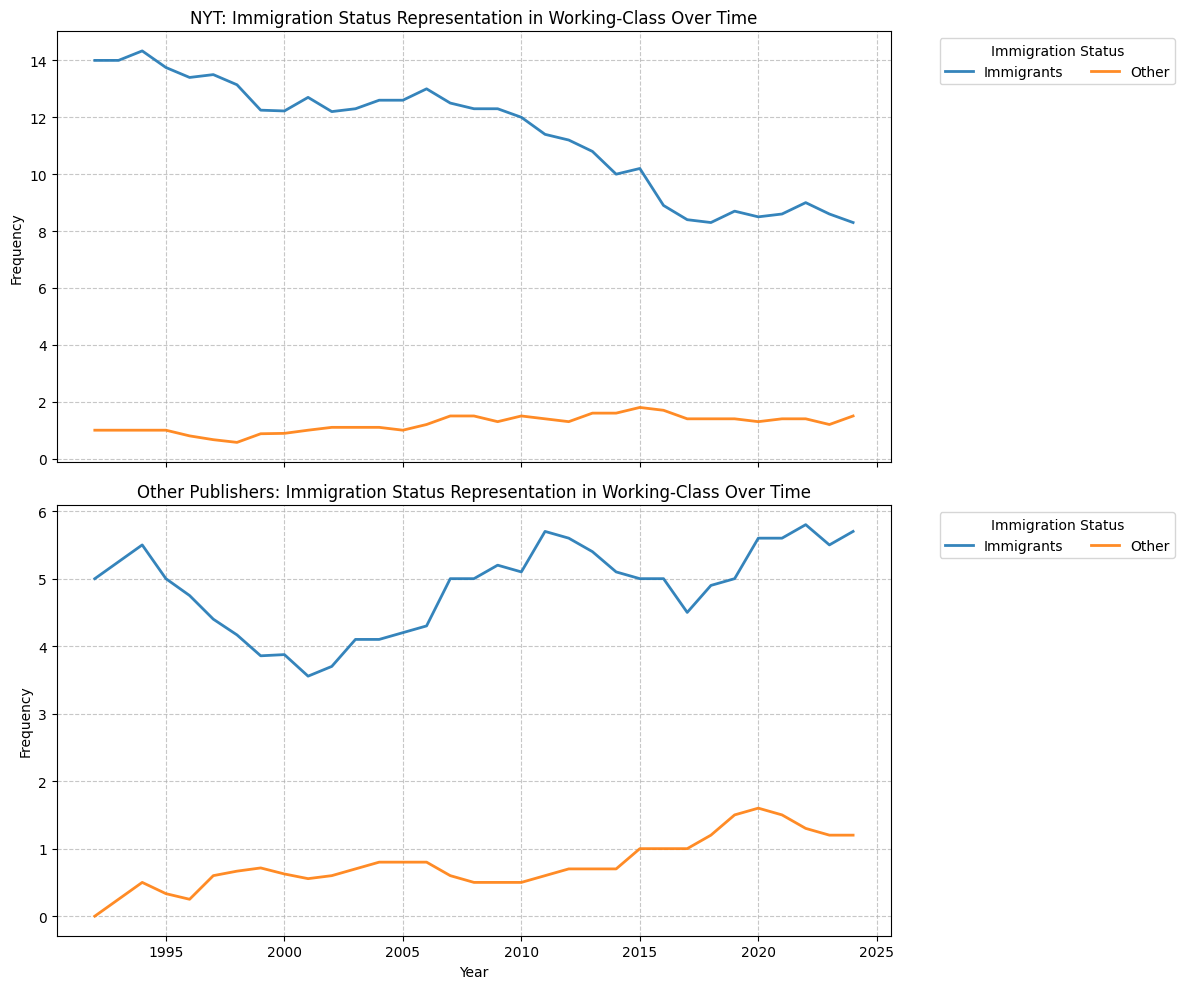

In [87]:
exclude = ['Unspecified'] # ['Unspecified', 'Mixed']

df_articles_with_results_filter = df_articles_with_results.loc[~df_articles_with_results['immigration_status_stand'].isin(exclude)]

nyt_mask_filter = df_articles_with_results_filter["publisher"] == "New York Times"
year_mask_filter = df_articles_with_results_filter["year"] > 1991



variable = 'immigration_status_stand'
filename = "../plots/comparison_immigration_time_chart.png"
title = 'Immigration Status Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results_filter[year_mask_filter], nyt_mask_filter[year_mask_filter], variable, title, filename, variable_label="Immigration Status", smooth_window=10)

To do:

* Interesting trend but too few articles where immigration status of working-class group is mentioned

<a id="union-membership"></a>
### 3.7. Union Membership  

[⬆ Return to Top](#table-of-contents)  

What role does union membership play for this working-class group? (Examples: unionized, non-unionized, mixed, NA.)  


In [88]:
df_articles_with_results['union_membership'].value_counts()

union_membership
NA                                                                                                                                  6275
Unionized                                                                                                                            194
Mixed                                                                                                                                 85
Non-unionized                                                                                                                          7
Mixed (many are unionized; some sectors like banking are highly organized; unions represent about a quarter of the workforce)          1
                                                                                                                                    ... 
Mixed (discussion notes associations of apprenticeships with unions and some resistance; implies both union and non-union exist)       1
Mixed (some unionized ho

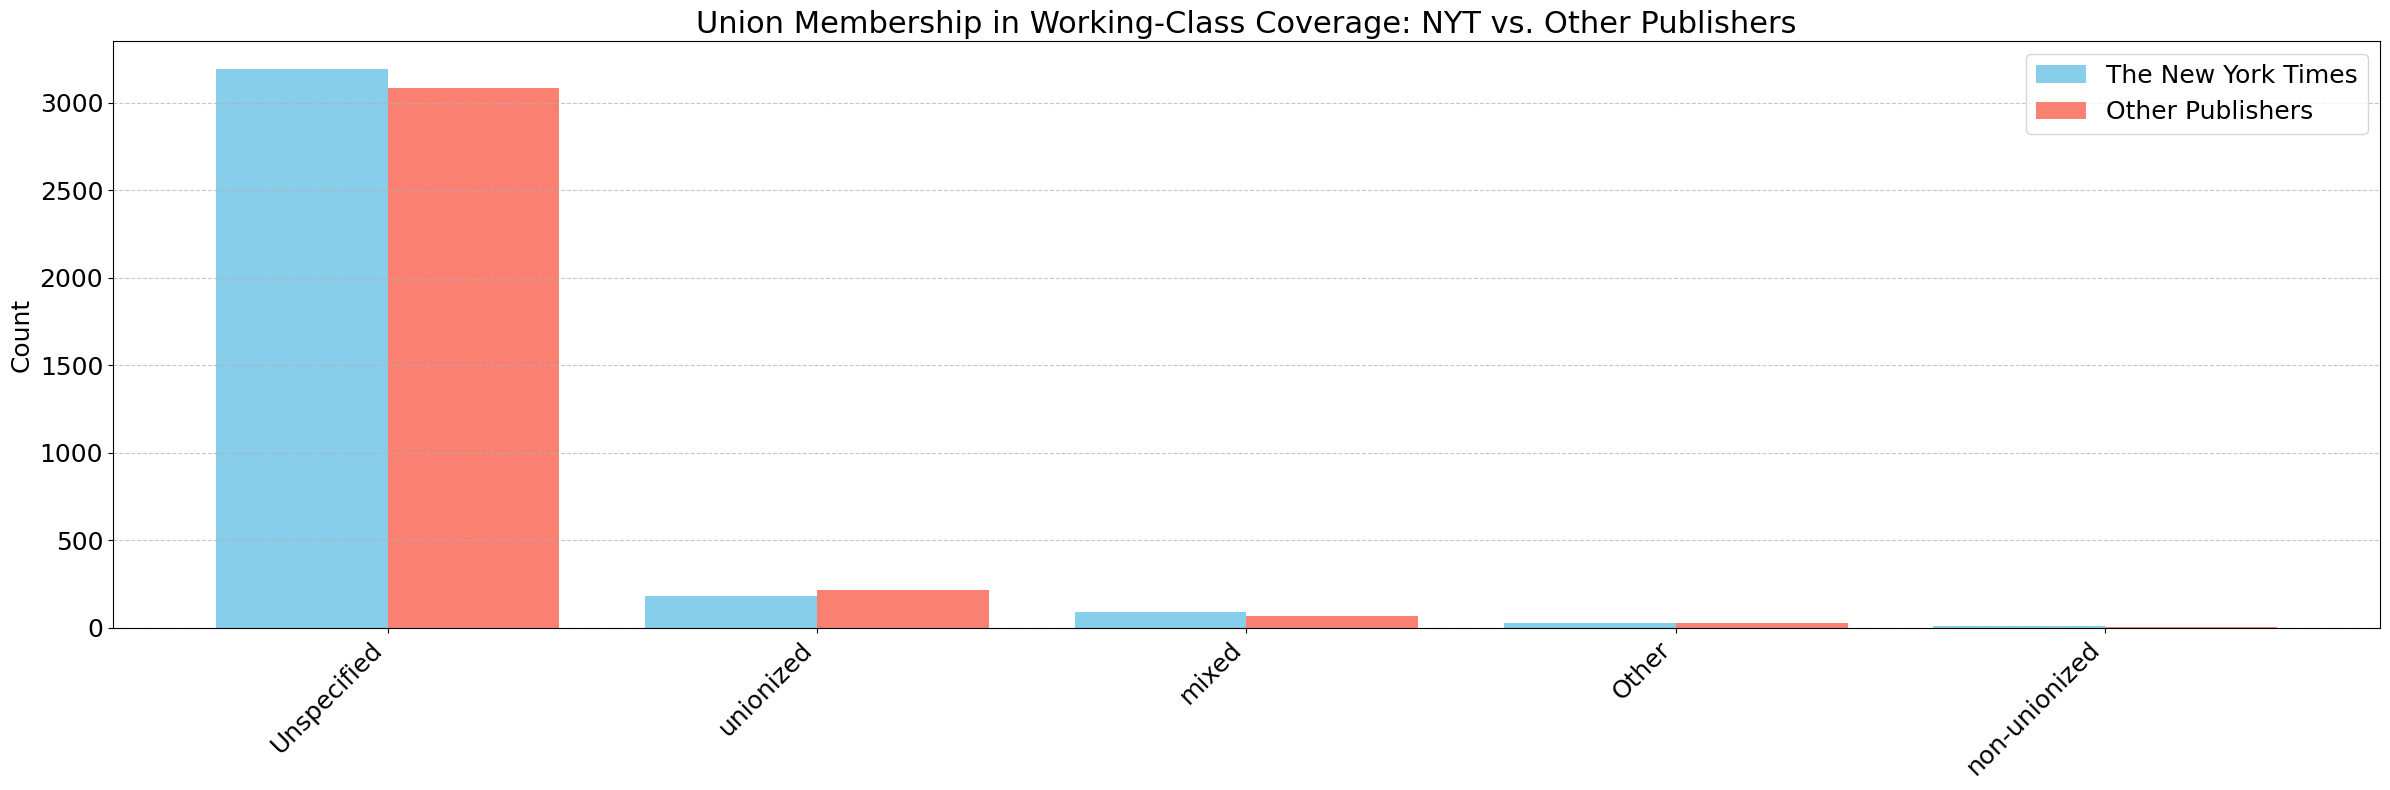

In [89]:
union_categories = ['non-unionized','unionized', 'mixed']
df_articles_with_results["union_membership_stand"] = df_articles_with_results["union_membership"].apply(lambda x: standardize_value(x, union_categories))

nyt_series = df_articles_with_results[nyt_mask]['union_membership_stand']
other_series = df_articles_with_results[~nyt_mask]['union_membership_stand']

title = 'Union Membership in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_union.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

To do:

* Eliminate this section?

Note for Elena:

* Very few specified cases. However, I specifically asked the model about the union memembership of the working class group. the topic of unions could be discussed more often.

* By the way, union topics may not explicitly mention the "working-class" keywords even if of interest to the working-class. Side topic.


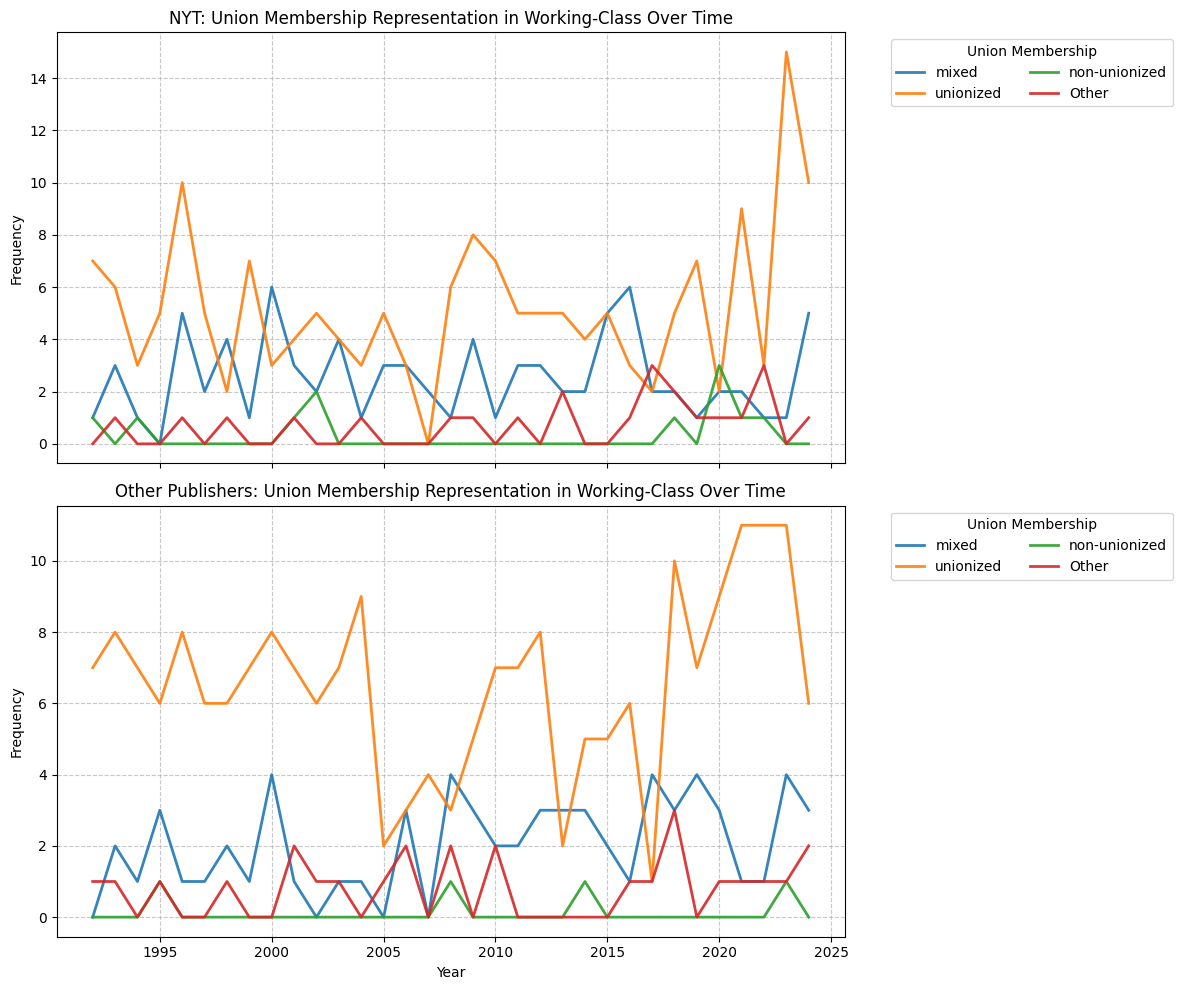

In [100]:
exclude = ['Unspecified'] # ['Unspecified', 'Mixed']

df_articles_with_results_filter = df_articles_with_results.loc[~df_articles_with_results['union_membership_stand'].isin(exclude)]

nyt_mask_filter = df_articles_with_results_filter["publisher"] == "New York Times"
year_mask_filter = df_articles_with_results_filter["year"] > 1991



variable = 'union_membership_stand'
filename = "../plots/comparison_union_time_chart.png"
title = 'Union Membership Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results_filter[year_mask_filter], nyt_mask_filter[year_mask_filter], variable, title, filename, variable_label="Union Membership", smooth_window=10)

<a id="other-characteristics"></a>
### 3.8. Other Characteristics  

[⬆ Return to Top](#table-of-contents)  

What other relevant characteristics not already captured are mentioned about the working-class group? (Examples: income level, age, housing situation, family structure, etc.) 

In [77]:
other_characterists_nyt = [i for i in list(df_articles_with_results[nyt_mask]['other_characteristics']) if i != "NA"]
other_characterists_nyt = " ".join(other_characterists_nyt).replace("working", "").replace("class", "")

other_characterists_other = [i for i in list(df_articles_with_results[~nyt_mask]['other_characteristics']) if i != "NA"]
other_characterists_other = " ".join(other_characterists_other).replace("working", "").replace("class", "")

In [78]:
#!pip install wordcloud matplotlib
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(other_characterists, title, filename):

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(other_characterists)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off axes
    plt.title(title, fontsize=20)
    plt.savefig(filename, dpi=300, facecolor='white', edgecolor='none')
    plt.show()

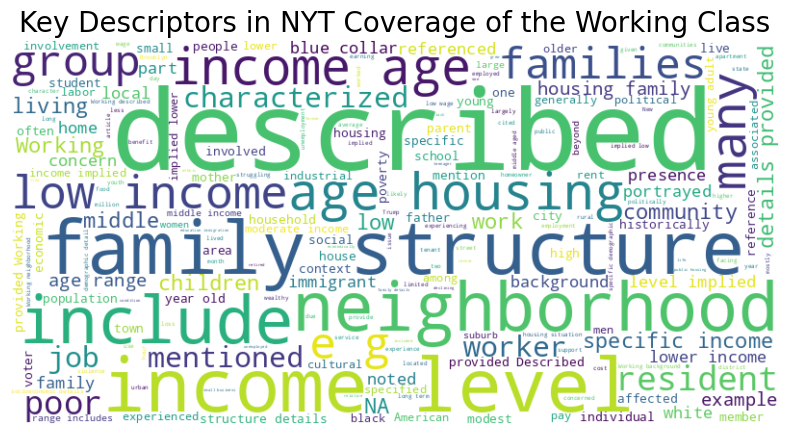

In [79]:
title = "Key Descriptors in NYT Coverage of the Working Class"
filename = "../plots/wordcloud_additional_characteristics_nyt.png"
plot_wordcloud(other_characterists_nyt, title, filename)

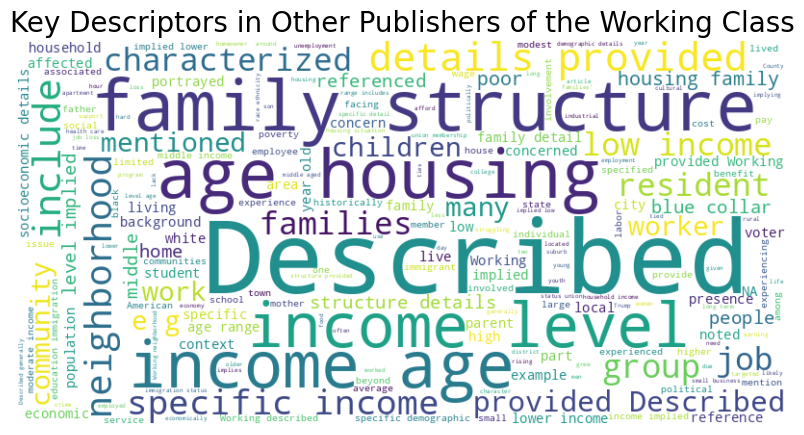

In [80]:
title = "Key Descriptors in Other Publishers of the Working Class"
filename = "../plots/wordcloud_additional_characteristics_other.png"
plot_wordcloud(other_characterists_other, title, filename)

Elena

* Note on why "Described" so big: it relates on how other characteristics is created. A broader work cloud may be more interesting. But relate to topics, rather than who the working class is.


<a id="conclusion"></a>
## 4. Conclusion


[⬆ Return to Top](#table-of-contents)

(TK: explain)

<a id="next-steps"></a>
## 5. Next Steps


[⬆ Return to Top](#table-of-contents)

(TK: explain)

<a id="reproducibility"></a>
## 6. Reproducibility


[⬆ Return to Top](#table-of-contents)

(TK: explain)

In [81]:
import pandas as pd
import matplotlib
import openai
import wordcloud
import ast

print("pandas==", pd.__version__)
print("matplotlib==", matplotlib.__version__)
print("openai==", openai.__version__)
print("wordcloud==", wordcloud.__version__)

pandas== 2.2.3
matplotlib== 3.10.1
openai== 1.70.0
wordcloud== 1.9.4


<a id="bibliography"></a>

## 7. Bibliography

[⬆ Return to Top](#table-of-contents)

* Census race and ethnicity categories: https://www.census.gov/topics/population/race/about.html

# Alternatives (Temp)

#### Country-Level Representation

In [32]:
# Extract locations for each publisher
publishers = {
    "nyt": df_articles_with_results["publisher"] == "New York Times",
    "other": df_articles_with_results["publisher"] != "New York Times"
}

columns = ["states_stand", "countries_stand", "other_locations_stand", "us_region_stand", "setting_stand"]

locations = {
    pub: {col.replace("_stand", ""): flatten(df_articles_with_results.loc[mask, col])
          for col in columns}
    for pub, mask in publishers.items()
}

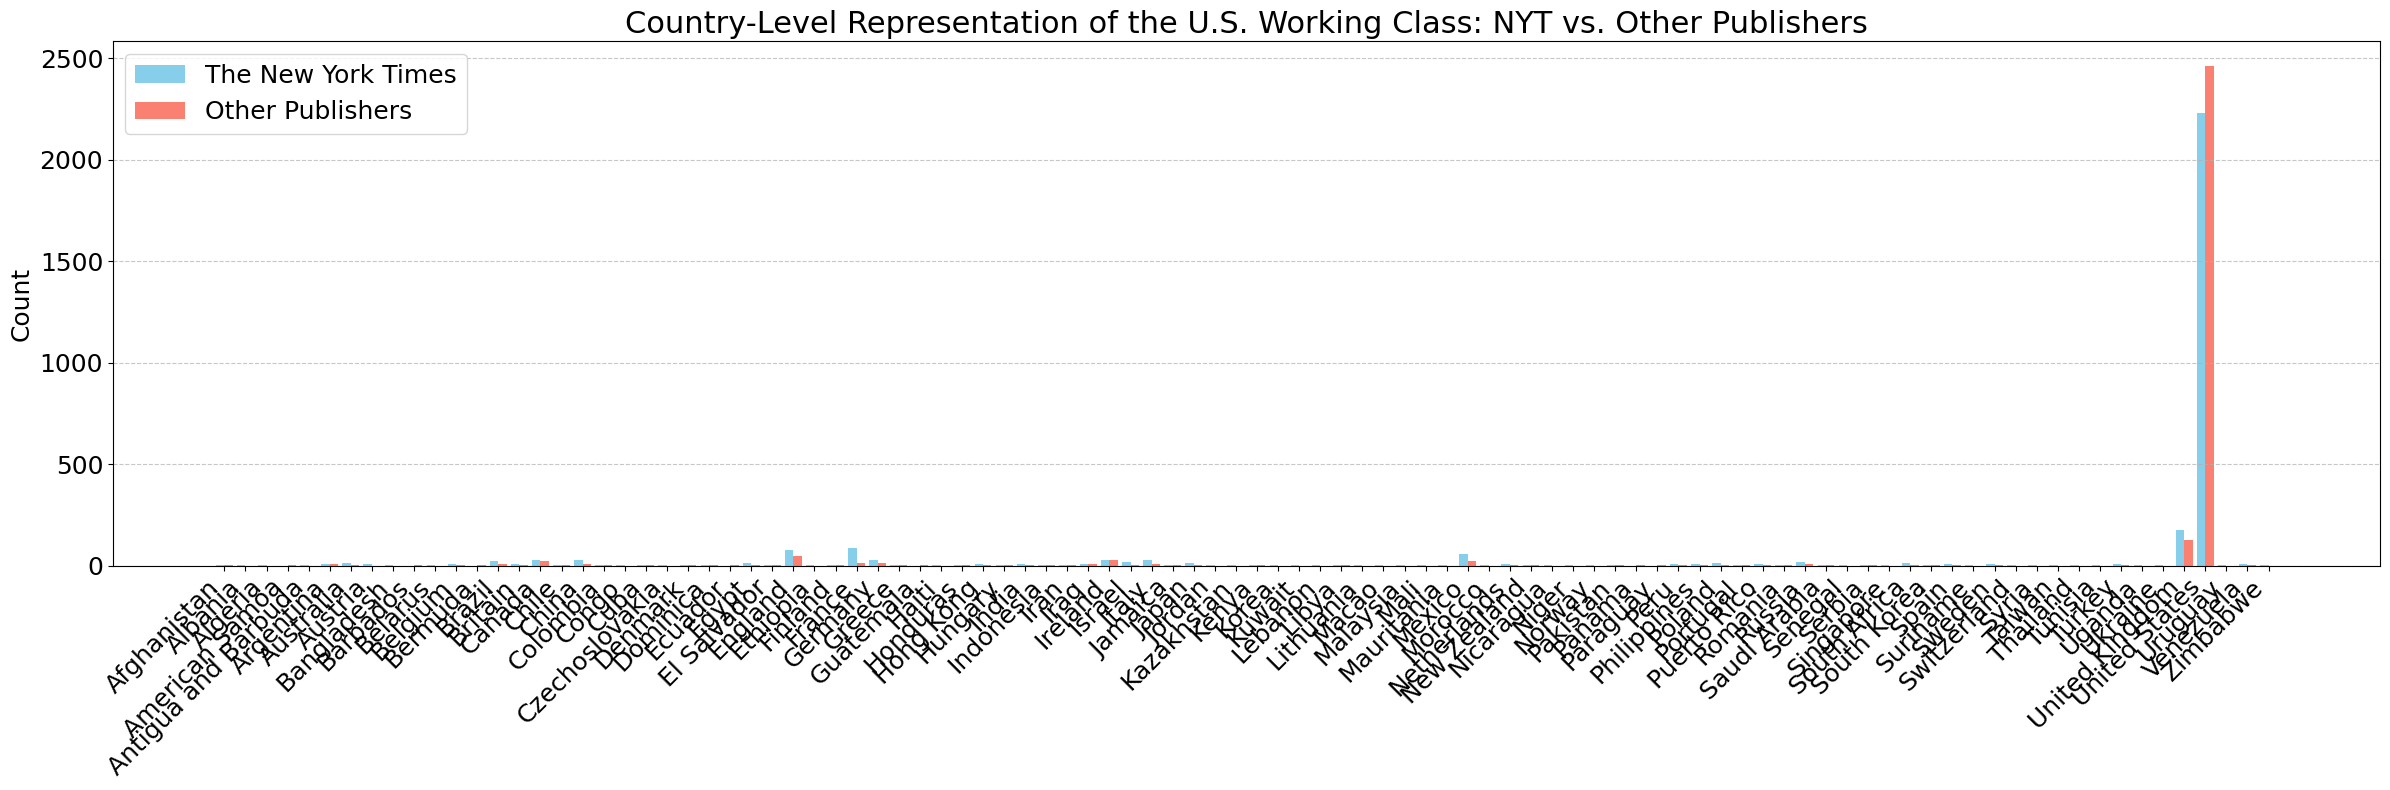

In [33]:
title = 'Country-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_countries.png"
compare_histograms(locations["nyt"]["countries"], locations["other"]["countries"], title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False)

In [34]:
nyt_mask = df_articles_with_results["publisher"] == "New York Times"

# Counts
unspecified_nyt = df_articles_with_results[nyt_mask]["countries_stand"].apply(lambda x: x == []).sum()
unspecified_other = df_articles_with_results[~nyt_mask]["countries_stand"].apply(lambda x: x == []).sum()

# Output
print("Number of unspecified countries:")
print(f"\tNYT articles: {unspecified_nyt}")
print(f"\tOther publishers articles: {unspecified_other}\n")

Number of unspecified countries:
	NYT articles: 561
	Other publishers articles: 569



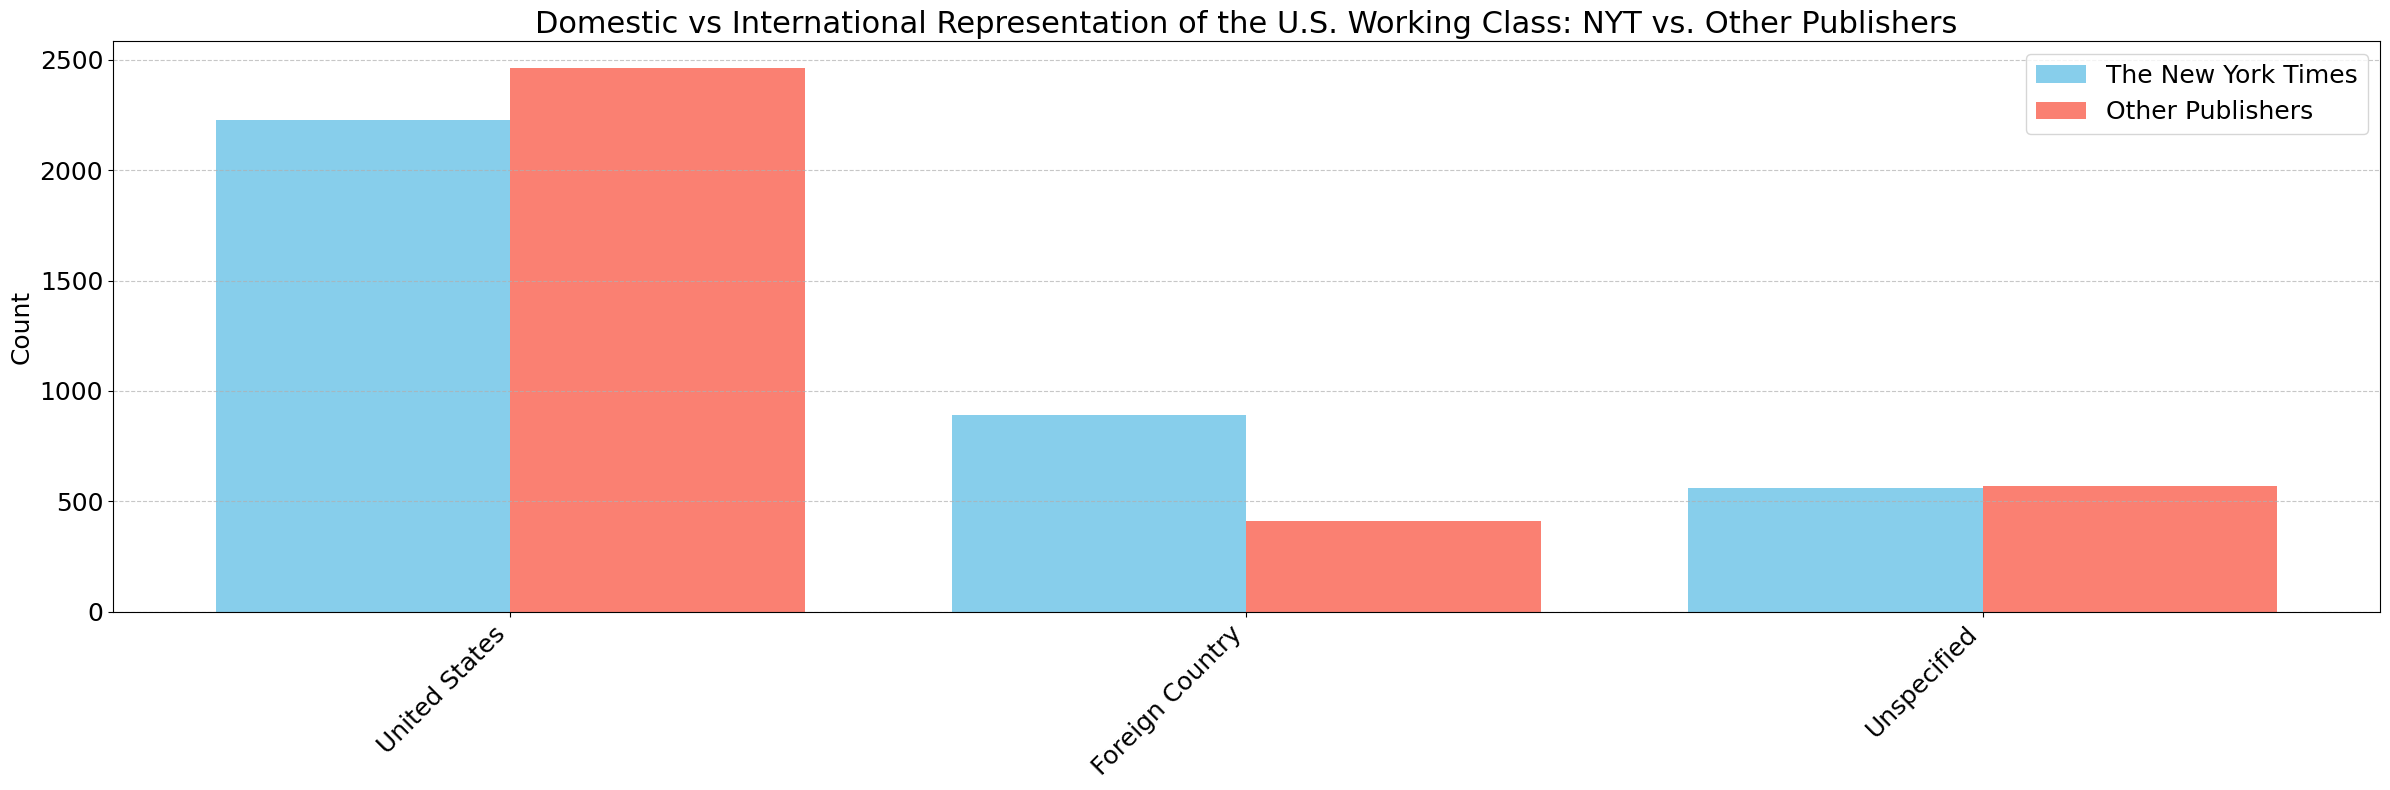

In [35]:
countries_cat_nyt = [i if i == "United States" else "Foreign Country" for i in locations["nyt"]["countries"]] + int(unspecified_nyt) * ["Unspecified"]
countries_cat_other = [i if i == "United States" else "Foreign Country" for i in locations["other"]["countries"]] + int(unspecified_other) * ["Unspecified"]

title = 'Domestic vs International Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_countries_cat.png"
compare_histograms(countries_cat_nyt, countries_cat_other, title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

#### State-Level Representation

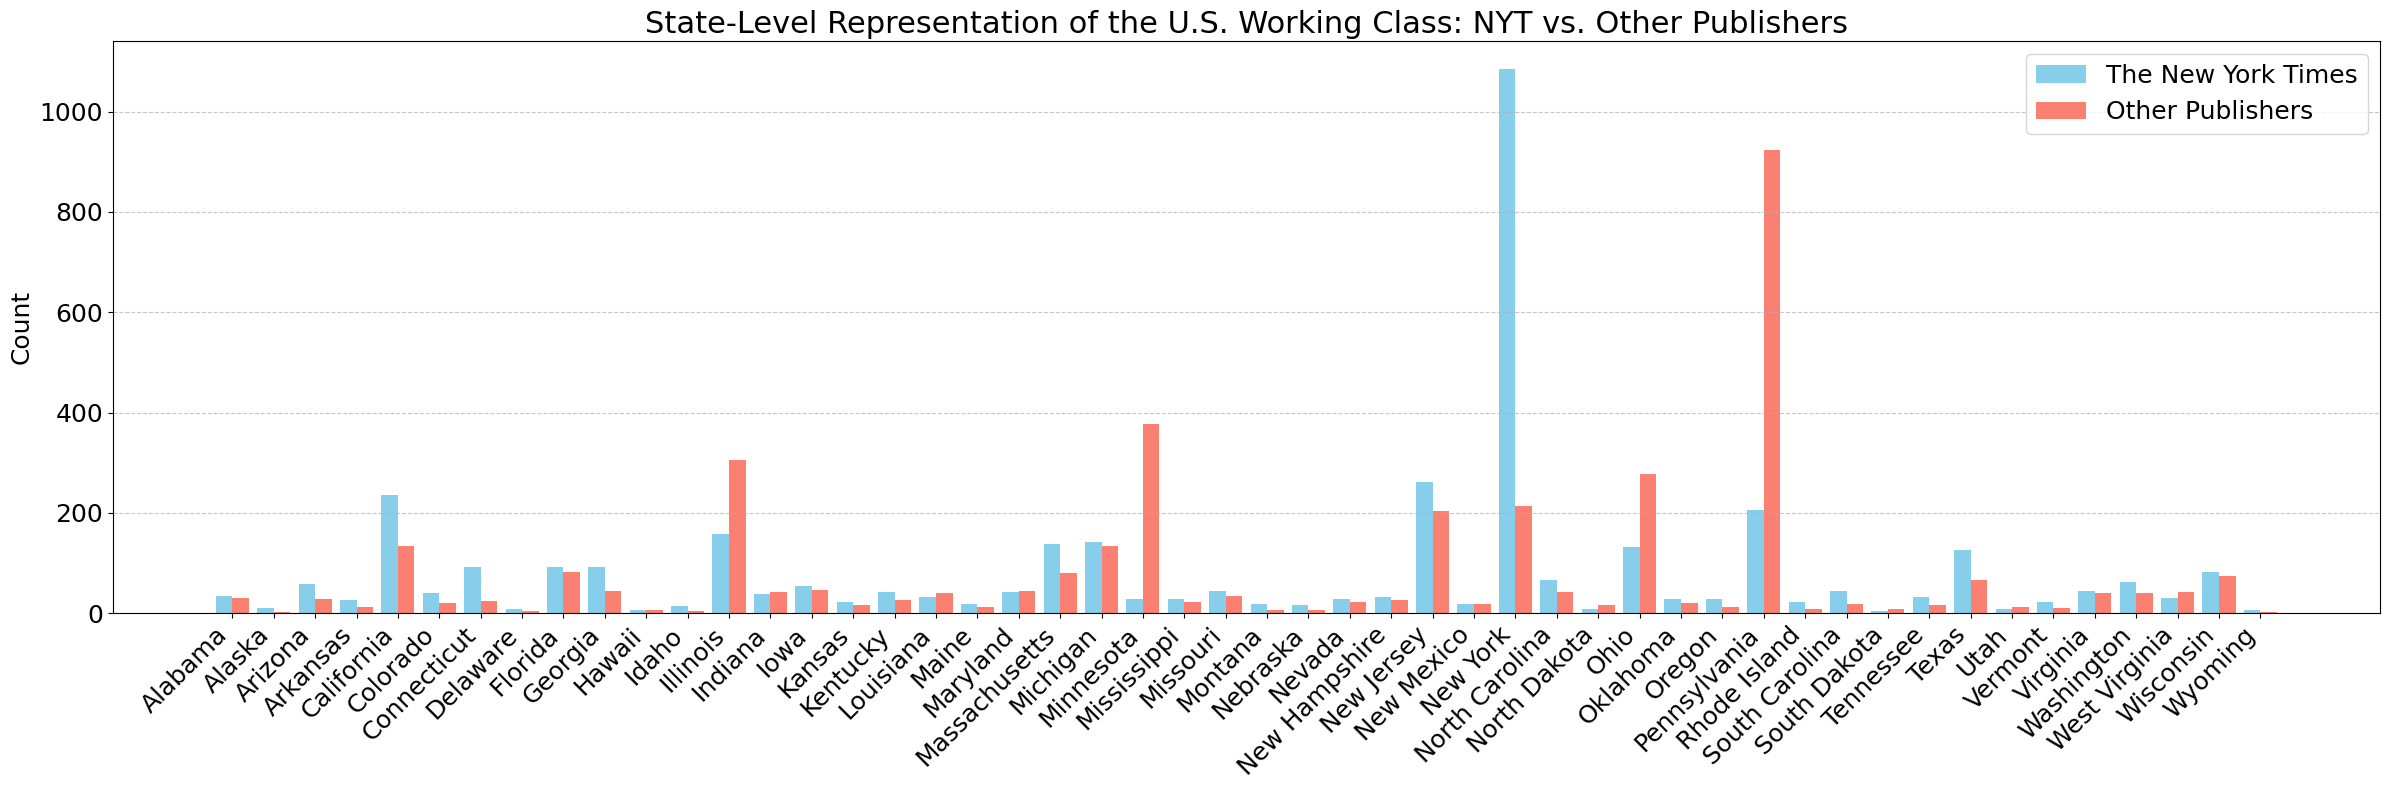

In [36]:
title = 'State-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_states.png"
compare_histograms(locations["nyt"]["states"], locations["other"]["states"], title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False)

In [37]:
nyt_mask = df_articles_with_results["publisher"] == "New York Times"

# Counts
unspecified_nyt = df_articles_with_results[nyt_mask]["states_stand"].apply(lambda x: x == []).sum()
unspecified_other = df_articles_with_results[~nyt_mask]["states_stand"].apply(lambda x: x == []).sum()

# Output
print("Number of unspecified states:")
print(f"\tNYT articles: {unspecified_nyt}")
print(f"\tOther publishers articles: {unspecified_other}\n")

Number of unspecified states:
	NYT articles: 1296
	Other publishers articles: 953



In [38]:
from collections import Counter

state_counts = Counter(locations["nyt"]["states"] + locations["other"]["states"])
high_freq_states = {key: value for key, value in state_counts.items() if value > 200}

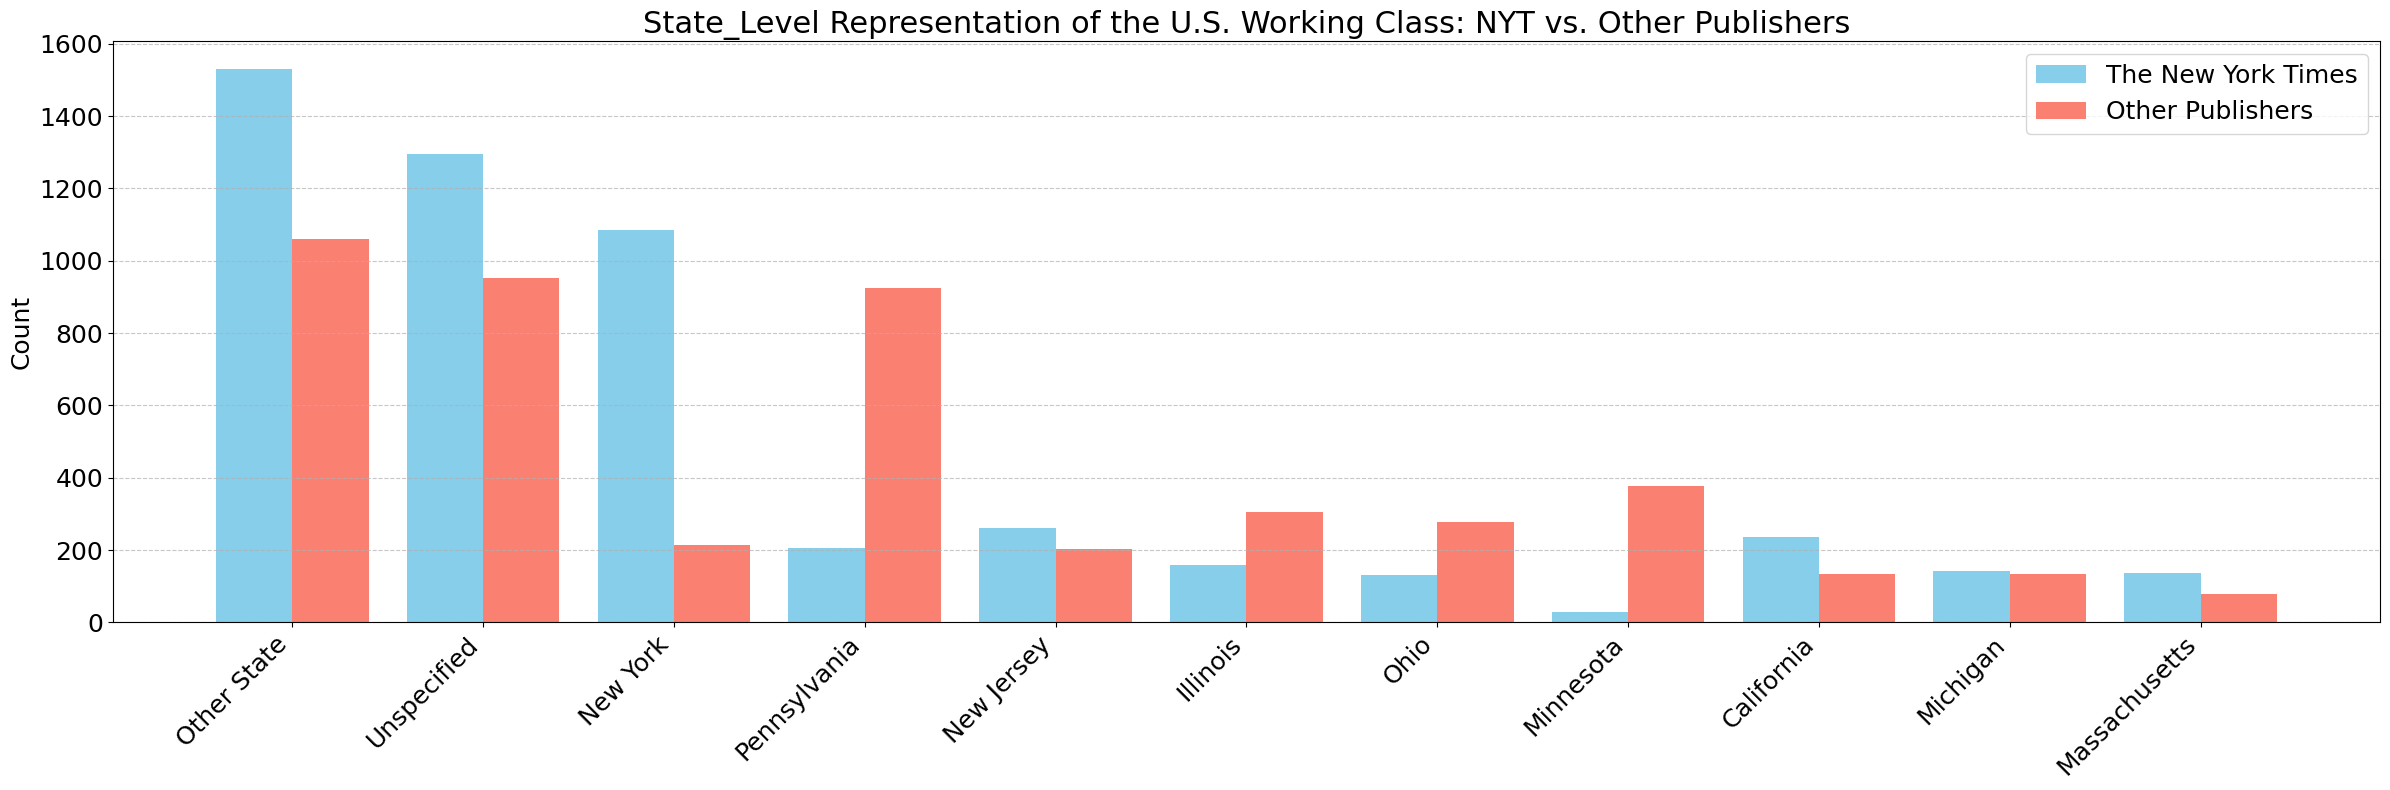

In [39]:
states_cat_nyt = [i if i in list(high_freq_states.keys())  else "Other State" for i in locations["nyt"]["states"]] + int(unspecified_nyt) * ["Unspecified"]
states_cat_other = [i if i in list(high_freq_states.keys())  else "Other State" for i in locations["other"]["states"]] + int(unspecified_other) * ["Unspecified"]

title = 'State_Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_countries_cat.png"
compare_histograms(states_cat_nyt, states_cat_other, title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

#### Region-level Representation

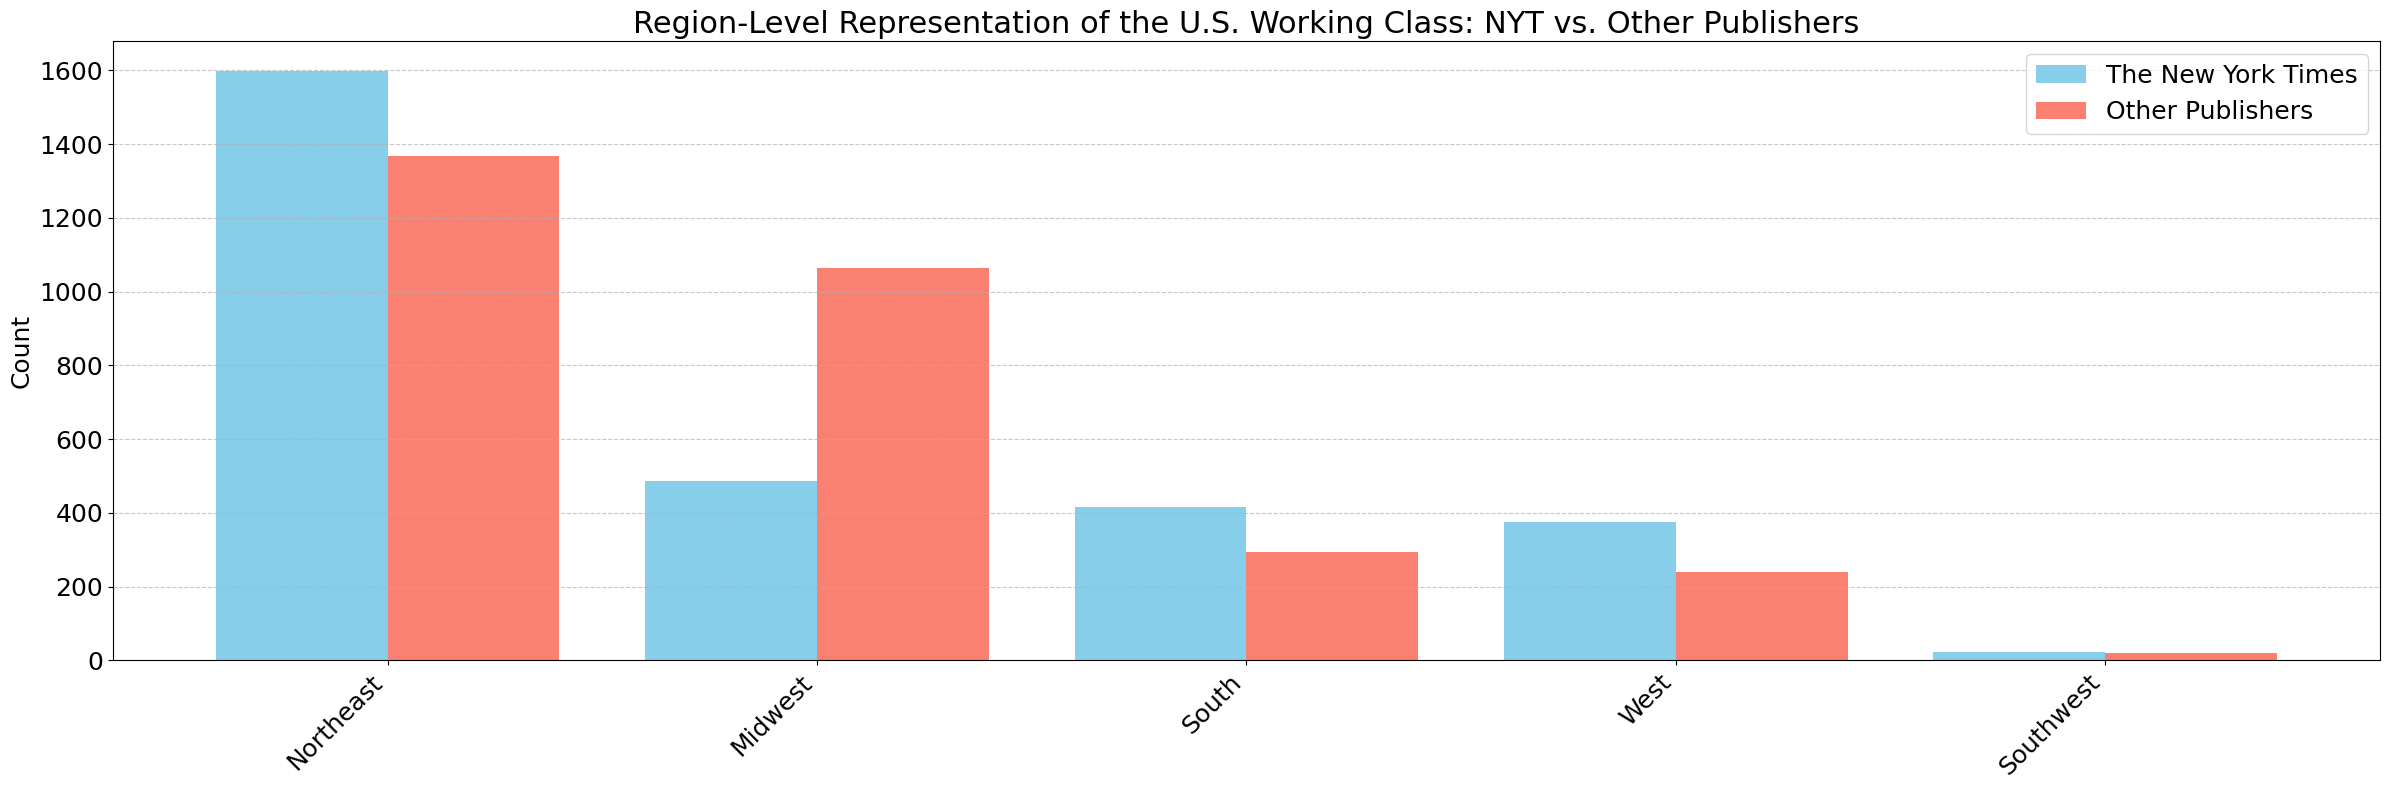

In [41]:
title = 'Region-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_regions.png"
compare_histograms(locations["nyt"]["us_region"], locations["other"]["us_region"], title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [42]:
# Counts
unspecified_nyt = df_articles_with_results[nyt_mask]["us_region_stand"].apply(lambda x: x == []).sum()
unspecified_other = df_articles_with_results[~nyt_mask]["us_region_stand"].apply(lambda x: x == []).sum()

# Output
print("Number of unspecified regions:")
print(f"\tNYT articles: {unspecified_nyt}")
print(f"\tOther publishers articles: {unspecified_other}\n")

Number of unspecified regions:
	NYT articles: 1282
	Other publishers articles: 934



To do:
* Add the Unspecified region?

#### Urban, Suburban, and Rural Representation

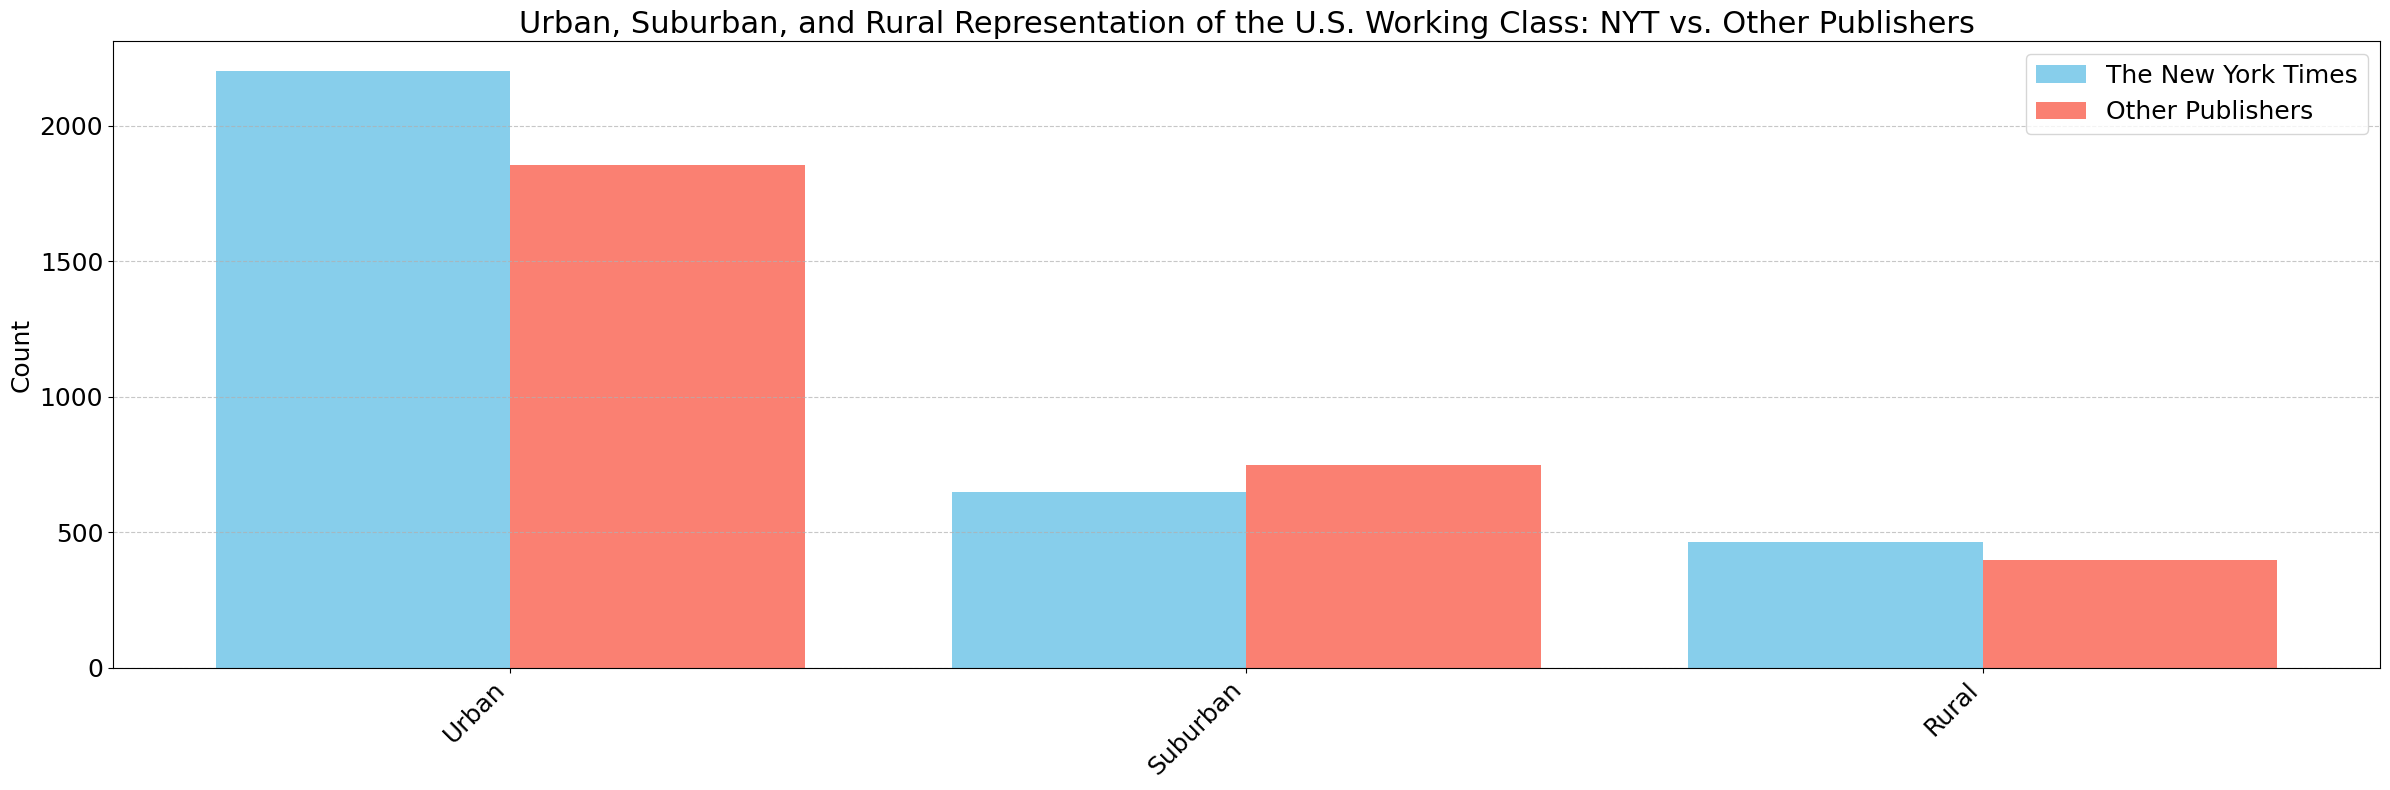

In [46]:
title = 'Urban, Suburban, and Rural Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_location_setting.png"
compare_histograms(locations["nyt"]["setting"], locations["other"]["setting"], title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

In [44]:
# Counts
unspecified_nyt = df_articles_with_results[nyt_mask]["setting_stand"].apply(lambda x: x == []).sum()
unspecified_other = df_articles_with_results[~nyt_mask]["setting_stand"].apply(lambda x: x == []).sum()

# Output
print("Number of unspecified urban, suburban, rural setting:")
print(f"\tNYT articles: {unspecified_nyt}")
print(f"\tOther publishers articles: {unspecified_other}\n")

Number of unspecified urban, suburban, rural setting:
	NYT articles: 782
	Other publishers articles: 997



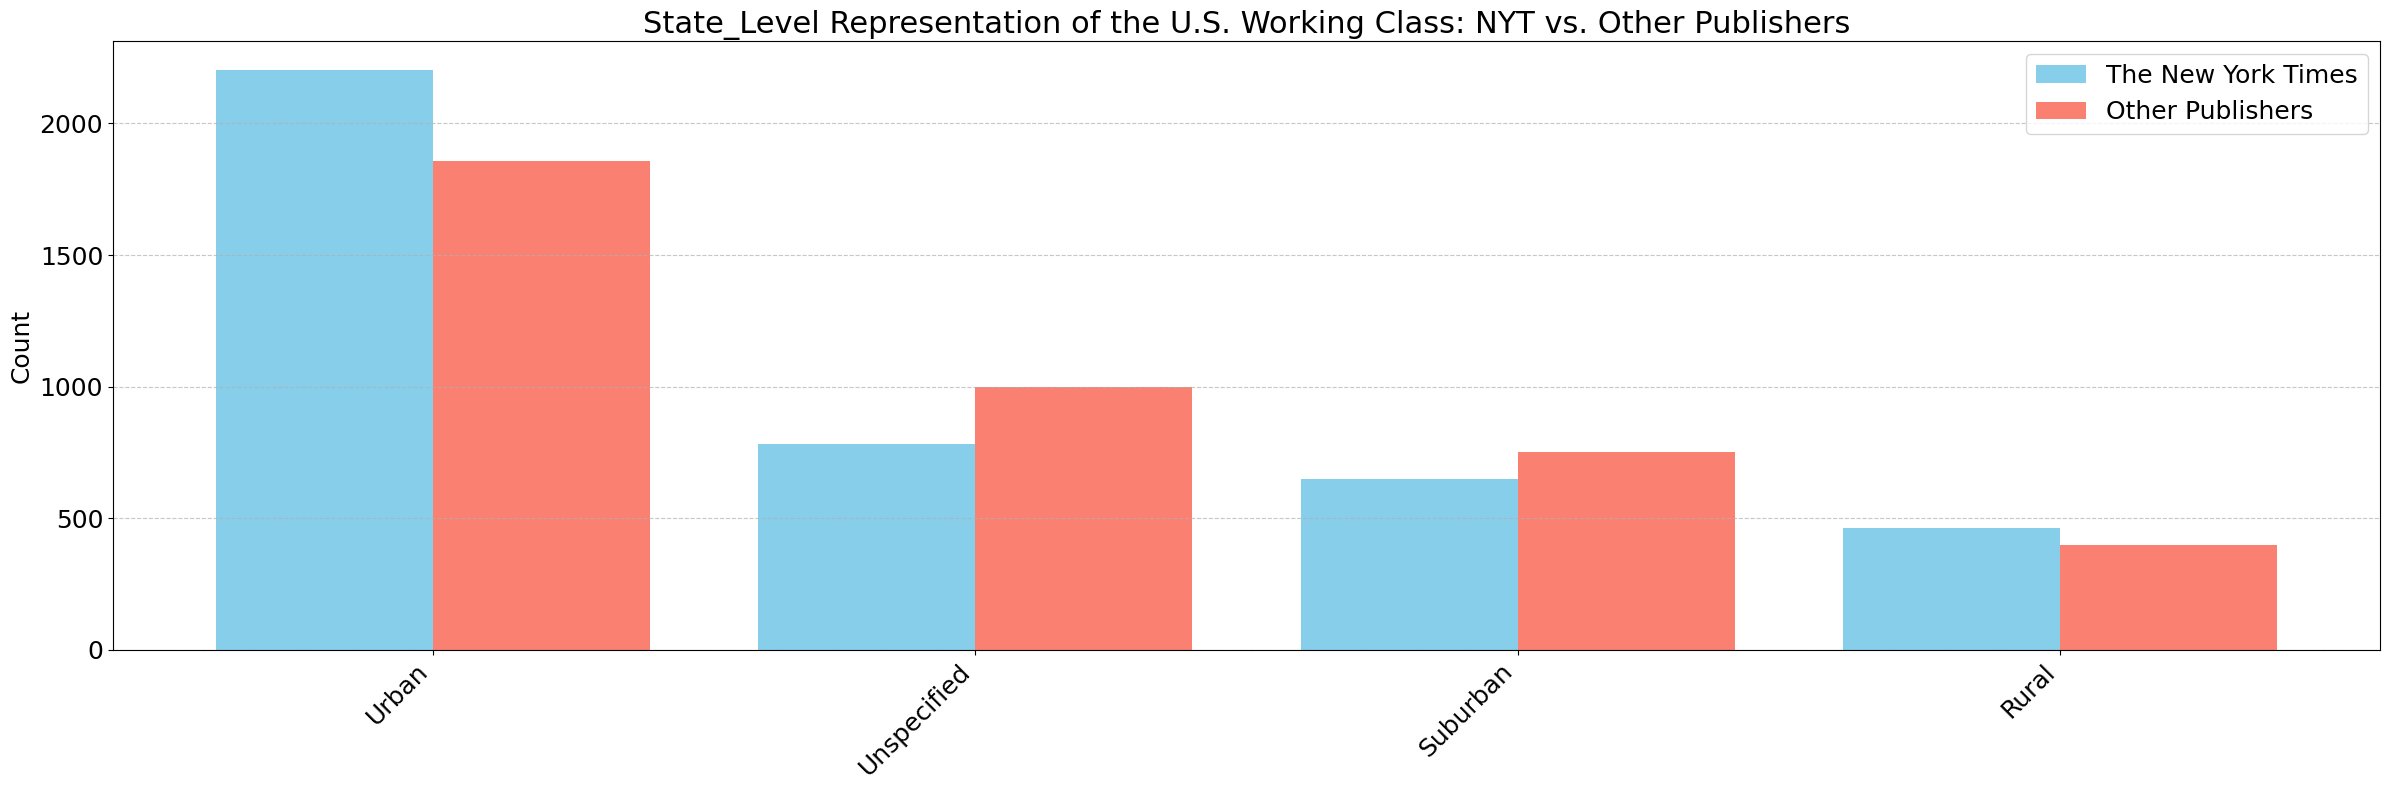

In [45]:
setting_cat_nyt = locations["nyt"]["setting"] + int(unspecified_nyt) * ["Unspecified"]
setting_cat_other = locations["other"]["setting"] + int(unspecified_other) * ["Unspecified"]


title = 'State_Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_location_setting_with_unsp.png"
compare_histograms(setting_cat_nyt, setting_cat_other, title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False, order_by_count=True)

Alternative way to count countries:

In [111]:
def categorize_country(countries, states):
    if ("United States" in countries) or len(states) > 1: # Note: now selecting only one choice per article, prioritizing US. May conflict with earlier view.
        return "United States"
    elif len(countries) > 1:
        return "Foreign Country"    
    else:
        return "Unspecified"

In [113]:
df_articles_with_results['country_cat'] = df_articles_with_results.apply(lambda df: categorize_country(df['countries_stand'], df['states_stand']), axis = 1)

In [115]:
df_articles_with_results['country_cat'].value_counts()

country_cat
United States      4725
Unspecified        2098
Foreign Country      74
Name: count, dtype: int64

# Earlier Version

In [113]:
assert 1 == 0

AssertionError: 

<a id="plots-of-nyt-sample-results"></a>

## 5. Plots of NYT Sample Results

[⬆ Return to Top](#table-of-contents)

In [29]:
# process the data

def generate_responses(df):
    responses = []
    for _, row in df.iterrows():
        user_prompt = f"Title: {row['title']}.\n\nBody: {row['body_cleaned']}"
        response = analyze_working_class(user_prompt)
        responses.append(response)
    return pd.DataFrame(responses)

Generate dataset:

In [22]:
# Reset index
df_nyt_sample.reset_index(drop=True, inplace=True)

# Generate responses
#df_responses_nyt = generate_responses(df_nyt_sample)
#df_nyt_sample_with_results = pd.concat([df_nyt_sample, df_responses_nyt], axis=1)
#df_responses_nyt.to_pickle("data/df_responses_nyt_200_sample.pkl") 
#df_nyt_sample_with_results.to_pickle("data/df_nyt_200_sample_with_responses.pkl") 

Load dataset:

In [7]:
df_responses_nyt =  pd.read_pickle("data/df_responses_nyt_200_sample.pkl")
#df_nyt_sample_with_results.read_pickle("data/df_nyt_200_sample_with_responses.pkl") 

In [4]:
# plots
import matplotlib.pyplot as plt
from collections import Counter

def plot_histogram(items_list, title, filename):
    # Count frequencies and sort from most to least frequent
    counter = Counter(items_list)
    sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)

    # Extract filtered labels and frequencies
    labels, frequencies = zip(*sorted_items)

    # Create the histogram
    plt.figure(figsize=(24, 8))
    plt.bar(labels, frequencies, color='skyblue')
    #plt.xlabel(xlabel, fontsize=18)
    plt.ylabel('Counts', fontsize=18)
    plt.title(title, fontsize=22)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=18)
    plt.yticks(fontsize=18)
    plt.tight_layout()

    # Save to file
    plt.savefig(filename, dpi=300, facecolor='white', edgecolor='none')

    # Show the plot
    plt.show()

In [33]:
# categorize results
import ast

racial_categories = ["White", "Black or African American", "American Indian or Alaska Native", "Asian", "Native Hawaiian or Other Pacific Islander", "Mixed / Multiple"]
ethnic_categories = ["Hispanic", "Latino", "Not Hispanic or Latino"]
gender_categories = ["Mostly Women", "Mostly Men", "Mixed", "Nonbinary"] # See "Mixed" here
#racial_ethnic_categories = racial_categories + ethnic_categories


def categorize_descriptors(race_ethnicity_list, category_list):
    
    categories_str = ", ".join(category_list)
    system_prompt_race_ethnicity_categorization = (
        f"Categorize each item in the user-provided Python list into one of the following categories: "
        f"{categories_str}. Return only a Python list as output. If cannot be categorized use 'NA'"
    )

    client = OpenAI()
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content":system_prompt_race_ethnicity_categorization},
            {"role": "user", "content": race_ethnicity_list}
        ],
        temperature=temperature
    )

    return ast.literal_eval(response.choices[0].message.content)

TODO: Match with initial dataframe (flatten at the end for charts)

TODO: use loop to categorize items to obtain list of the same size

### Location

In [8]:
# Set of U.S. states
us_states = {
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut',
    'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
    'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan',
    'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
    'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio',
    'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia',
    'Wisconsin', 'Wyoming'
}

# Function to split states and countries
def split_locations(locations):
    states = [loc for loc in locations if loc in us_states]
    countries = [loc for loc in locations if loc not in us_states and loc != "United States"]
    return states, countries

# Flatten and filter location lists
def flatten_and_filter(locations_column):
    return [item for sublist in locations_column for item in sublist if item != "NA"]

# Get and process NYT locations
locations_nyt = flatten_and_filter(df_responses_nyt["geographical_locations"])
print(f"NYT total locations: {len(locations_nyt)}")

states_nyt, countries_nyt = split_locations(locations_nyt)

NYT total locations: 363


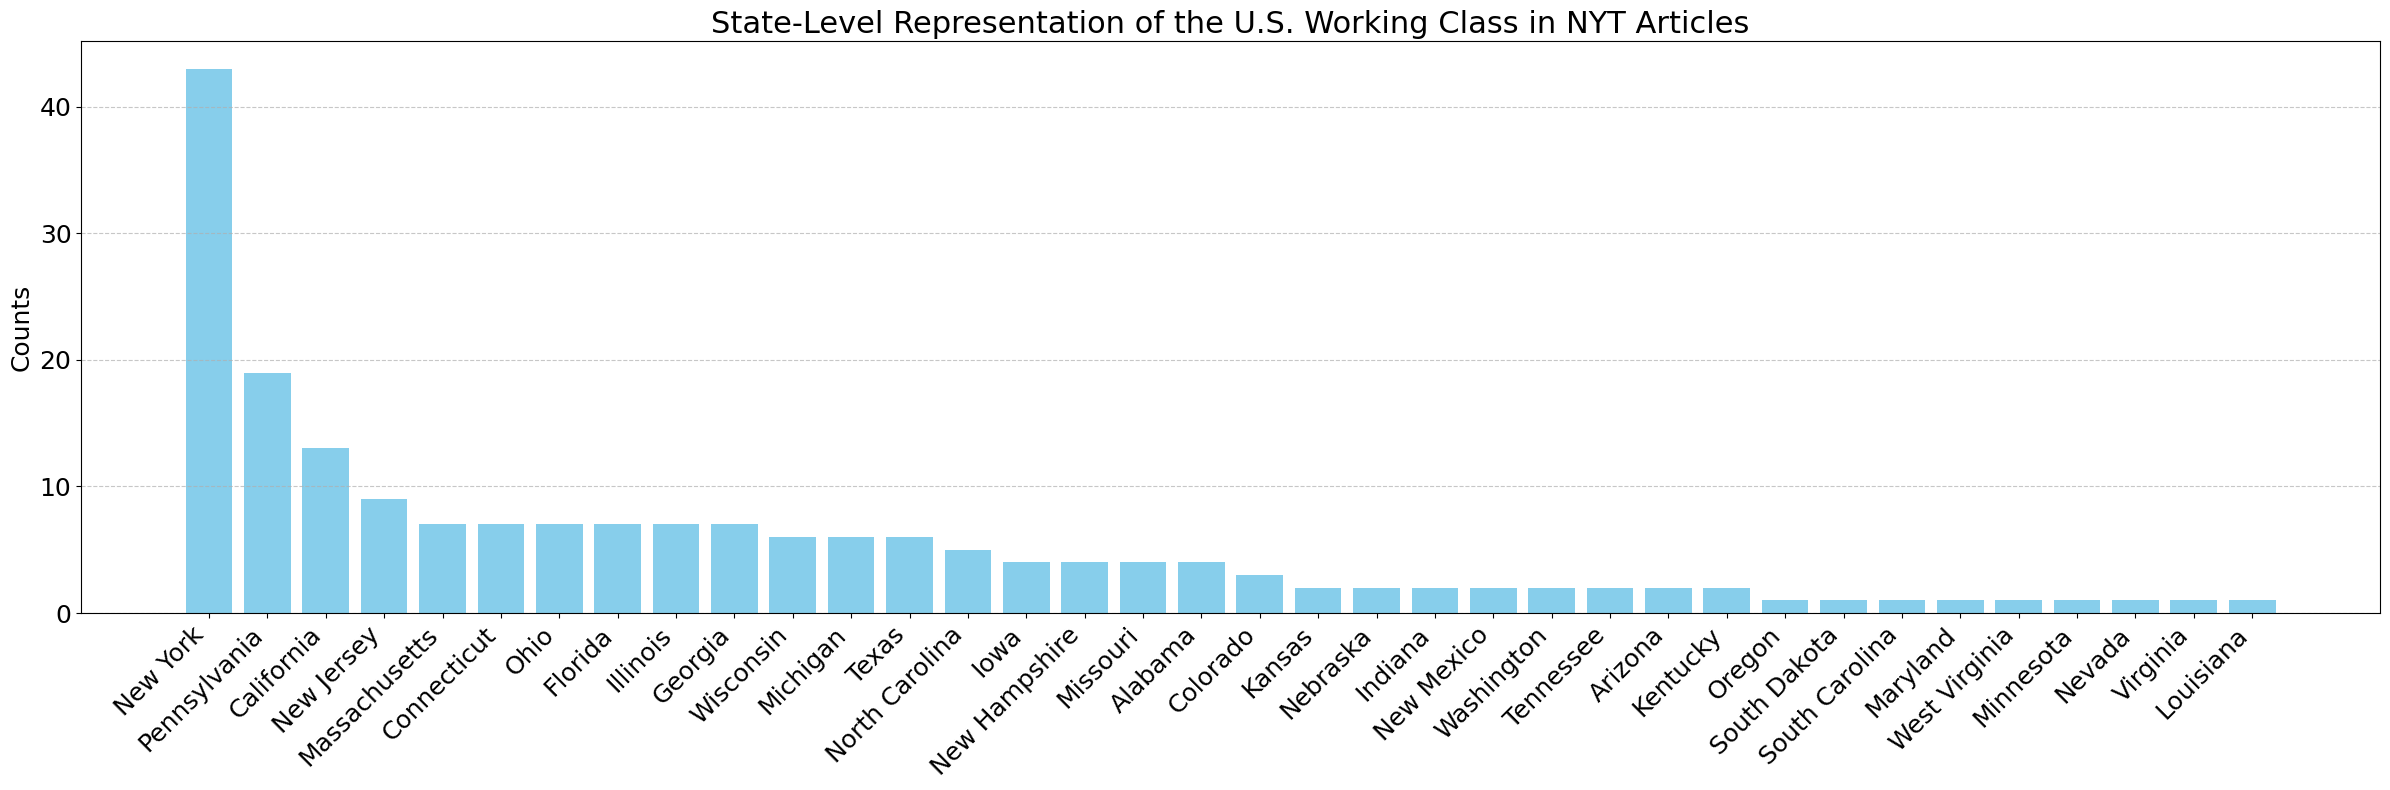

In [9]:
#xlabel = 'U.S. State'
title = "State-Level Representation of the U.S. Working Class in NYT Articles"
filename = 'plots/histogram_states_nyt.png'
plot_histogram(states_nyt, title, filename)

In [12]:
len(states_nyt)

193

In [11]:
len(countries_nyt)

165

TODO: Fix categorization, as some states fall into countries.

In [35]:
#xlabel = "Country"
#title = "International Coverage of the Working Class in NYT Articles (Excluding U.S.)" 
#filename = "plots/histogram_countries_nyt.png"
#plot_histogram(countries_nyt, xlabel, title, filename)

Question Elena: filter out articles related to other countries? (following characteristics may reflect immigrants to other countries - such as european countries - who have very different profiles; making it difficult to compare NYT to other publishers)


Agreed.

### Occupation

In [25]:
occupation_categories = ["Skilled Trades and Manual Labor", "Manufacturing and Industrial Jobs",
                         "Service and Maintenance", "Transportation and Delivery", "Food Service",
                         "Retail and Customer Service", "Health and Personal Care", "Education",
                         "Domestic Work", "Professional Services", "Other"] # paralegal

In [34]:
occupations_nyt = list(df_responses_nyt["occupations"])
occupations_nyt = [item for sublist in occupations_nyt for item in sublist if item != "NA"]
occupations_nyt_cat = categorize_descriptors(str(occupations_nyt), occupation_categories)
occupations_nyt_cat = [i if i in occupation_categories else "Other" for i in occupations_nyt_cat]

In [35]:
len(occupations_nyt_cat)

250

In [36]:
len(occupations_nyt)

252

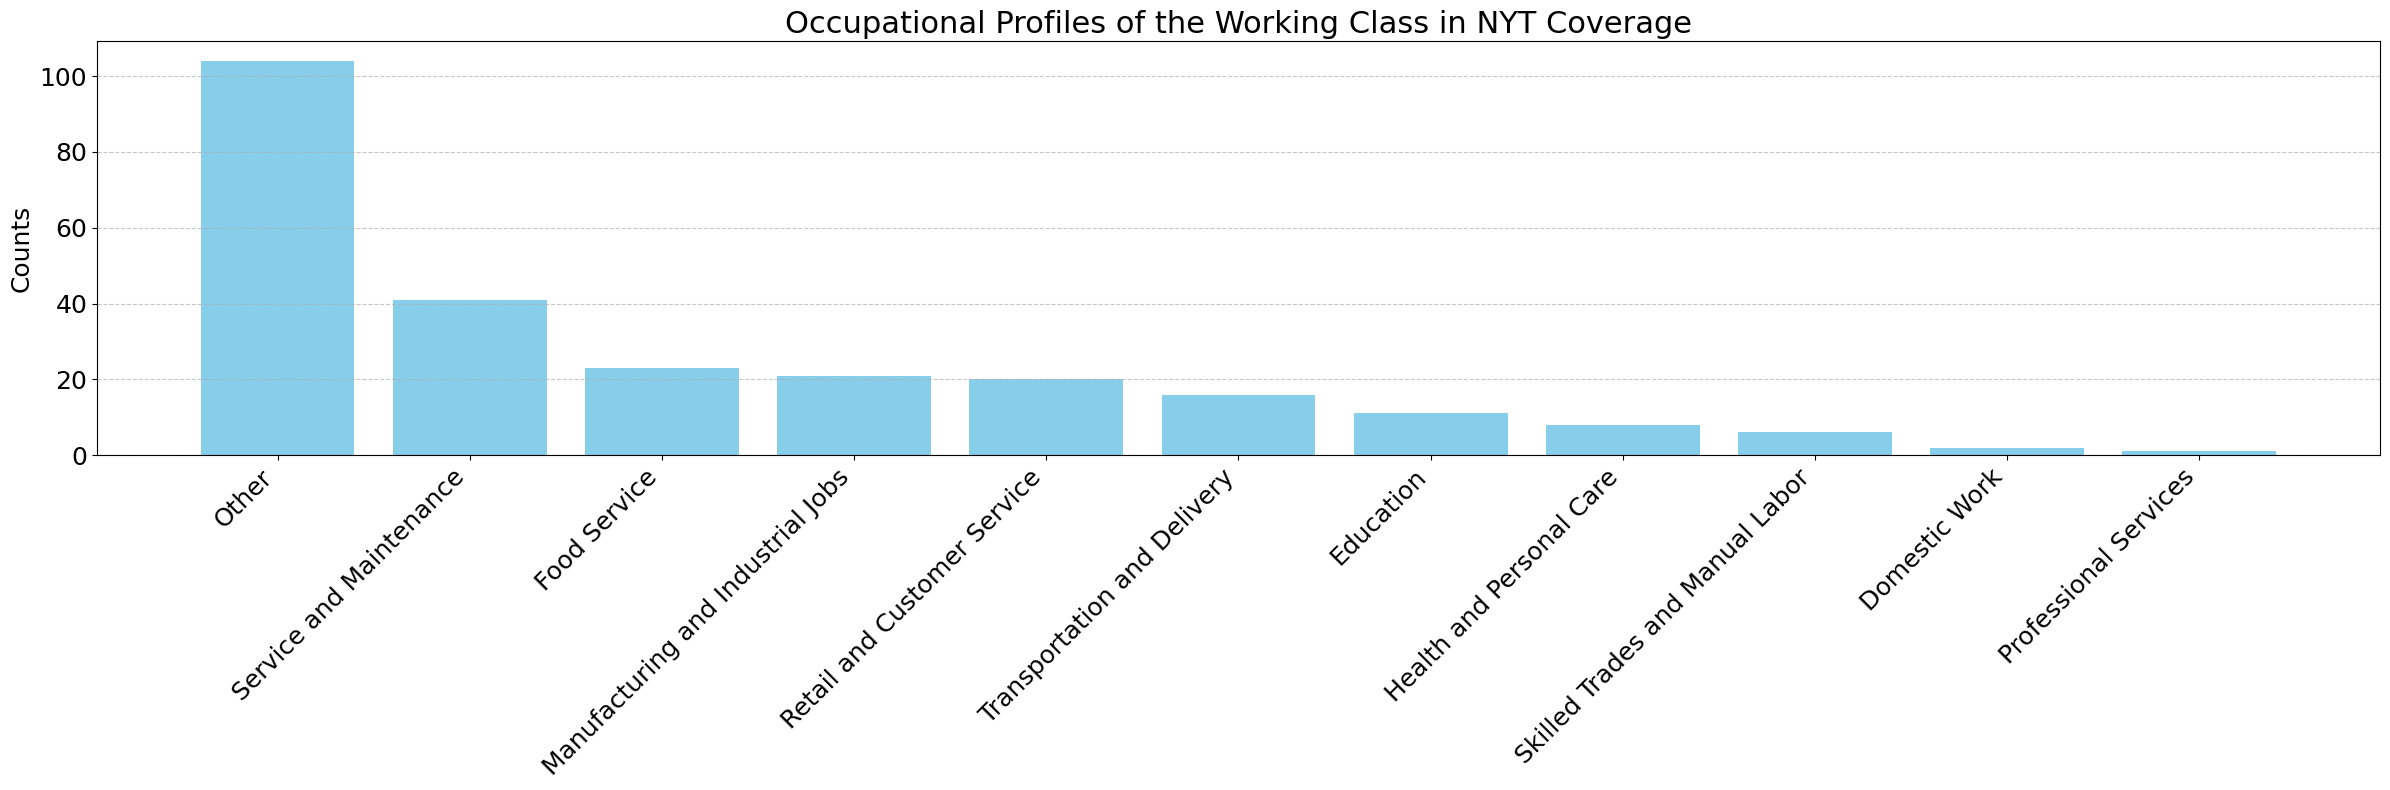

In [19]:
#xlabel = "Occupation"
title = "Occupational Profiles of the Working Class in NYT Coverage"
filename = "plots/histogram_occupations_nyt.png"
plot_histogram(occupations_nyt_cat, title, filename)

In [36]:
# "Raw" occupations (impossible to view)
#occupations_nyt_raw = list(df_responses_nyt["occupations"])
#occupations_nyt_raw = [item for sublist in occupations_nyt_raw for item in sublist if item != "NA"]
#title = "Occupational Profiles of the Working Class in NYT Coverage"
#filename = "plots/histogram_occupations_nyt_raw.png"
#plot_histogram(list(occupations_nyt_raw), title, filename)

TODO: What's in professional services? and what is in other?

### Race and ethnicity

In [39]:
def extract_race_ethnicity(df):
    # Extract and filter out "NA" strings
    race_ethnicity = df["race_ethnicity"].dropna()
    race_ethnicity = [resp for resp in race_ethnicity if resp != "NA"]
    
    # Categorize race and ethnicity
    race = categorize_descriptors(str(race_ethnicity), racial_categories)
    ethnicity = categorize_descriptors(str(race_ethnicity), ethnic_categories)

    # Filter out "NA" results from categorization
    race = [r for r in race if r != "NA"]
    ethnicity = [e for e in ethnicity if e != "NA"]

    return race, ethnicity

race_nyt, ethnicity_nyt = extract_race_ethnicity(df_responses_nyt)


In [42]:
#"Race / Ethnicity"
race_ethnicity = df_responses_nyt["race_ethnicity"].dropna()
print(list(race_ethnicity))

['NA', 'NA', 'Latino (including Guatemalan, Costa Rican)', 'Italian American', 'White', 'Predominantly North African (Algerian, Moroccan, Tunisian) and West African origin; also includes some from Turkey and Martinique.', "White (specifically 'white working-class voters')", 'NA', 'Latino, primarily immigrants from Central America (El Salvador, Honduras, Mexico)', 'White (predominantly Irish descent)', "White (specifically mentioned as 'white working-class' in some states); other racial or ethnic backgrounds not specified.", 'NA', 'NA', 'White', 'NA', 'NA', 'NA', 'NA', 'White', 'Highly ethnically diverse; includes immigrants from various backgrounds (specific groups not listed)', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'Black', "White (noted as 'white working-class voters' and reference to Italian immigrants)", 'NA', 'Indian descent (for the new pastry chef character)', 'Jewish (historically), Hispanic, African-American, Whit

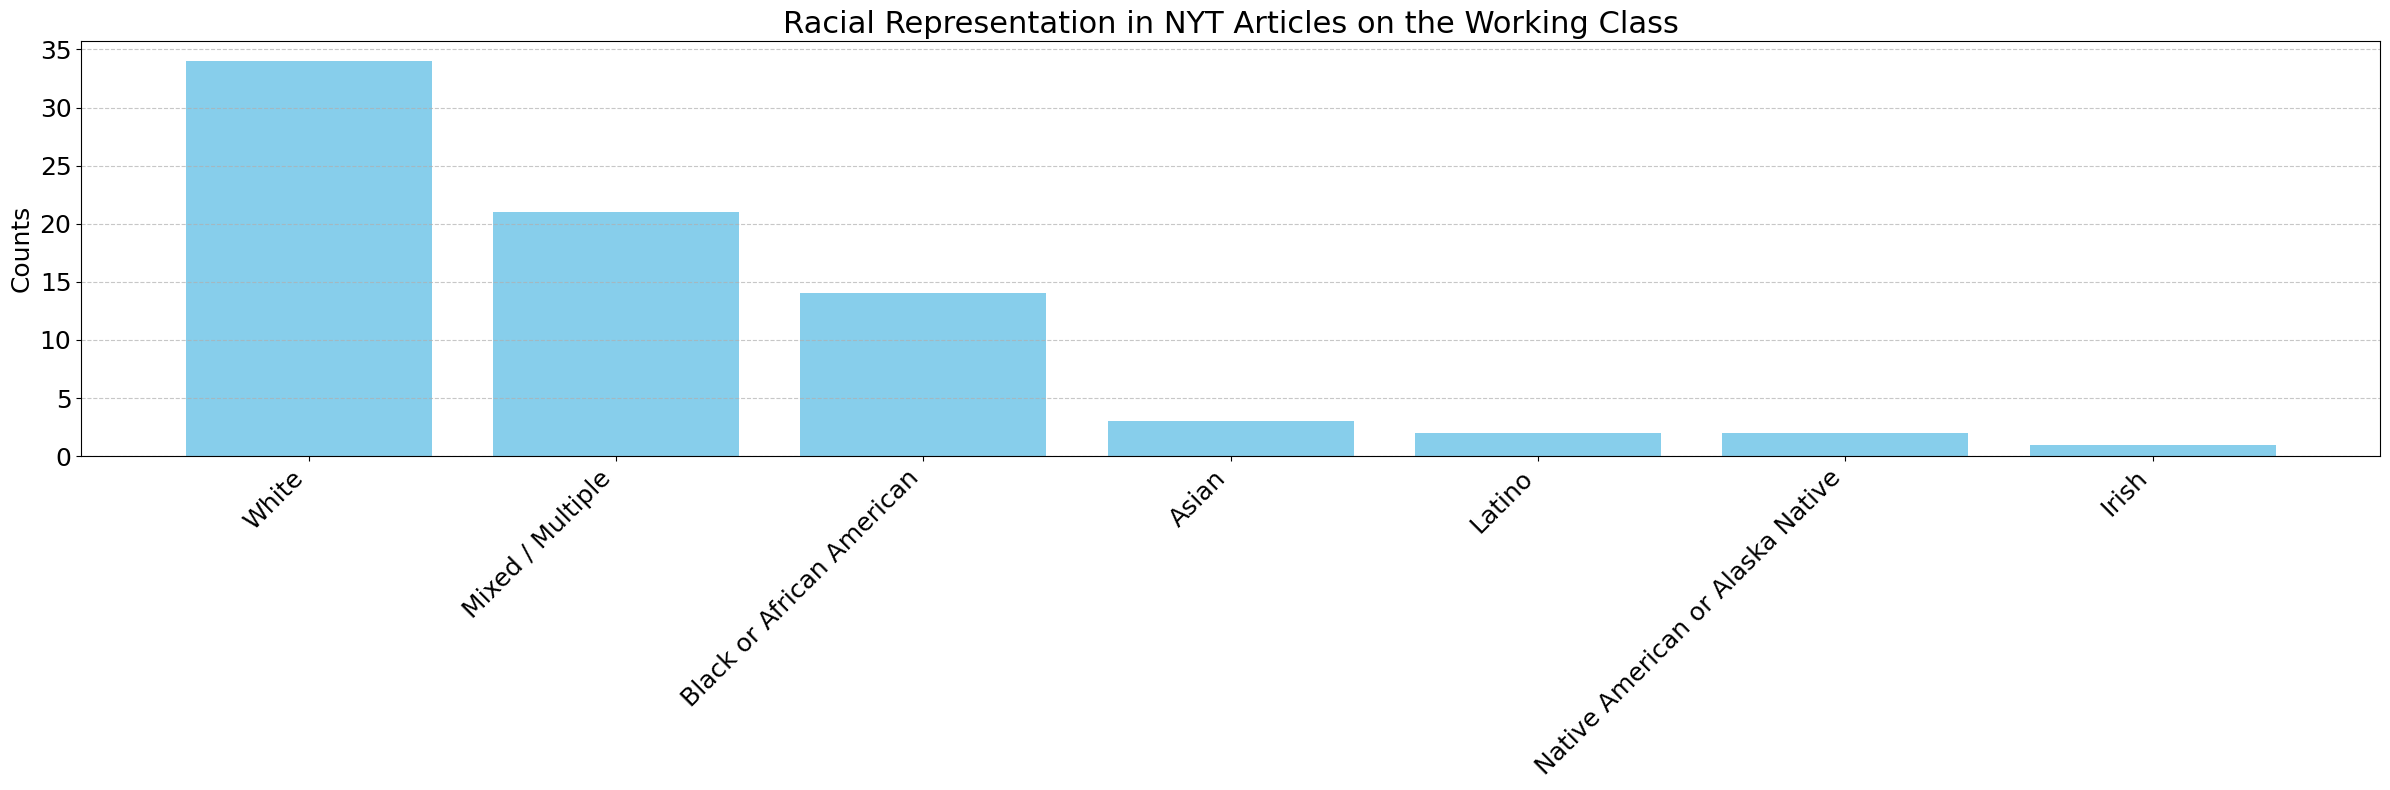

In [41]:
#xlabel = "Race"
title = "Racial Representation in NYT Articles on the Working Class"
filename = "plots/race_category_nyt.png"
plot_histogram(race_nyt, title, filename)

TODO: look into how "Irish" made into it.

Add "Latino" and "Hispanic" race.




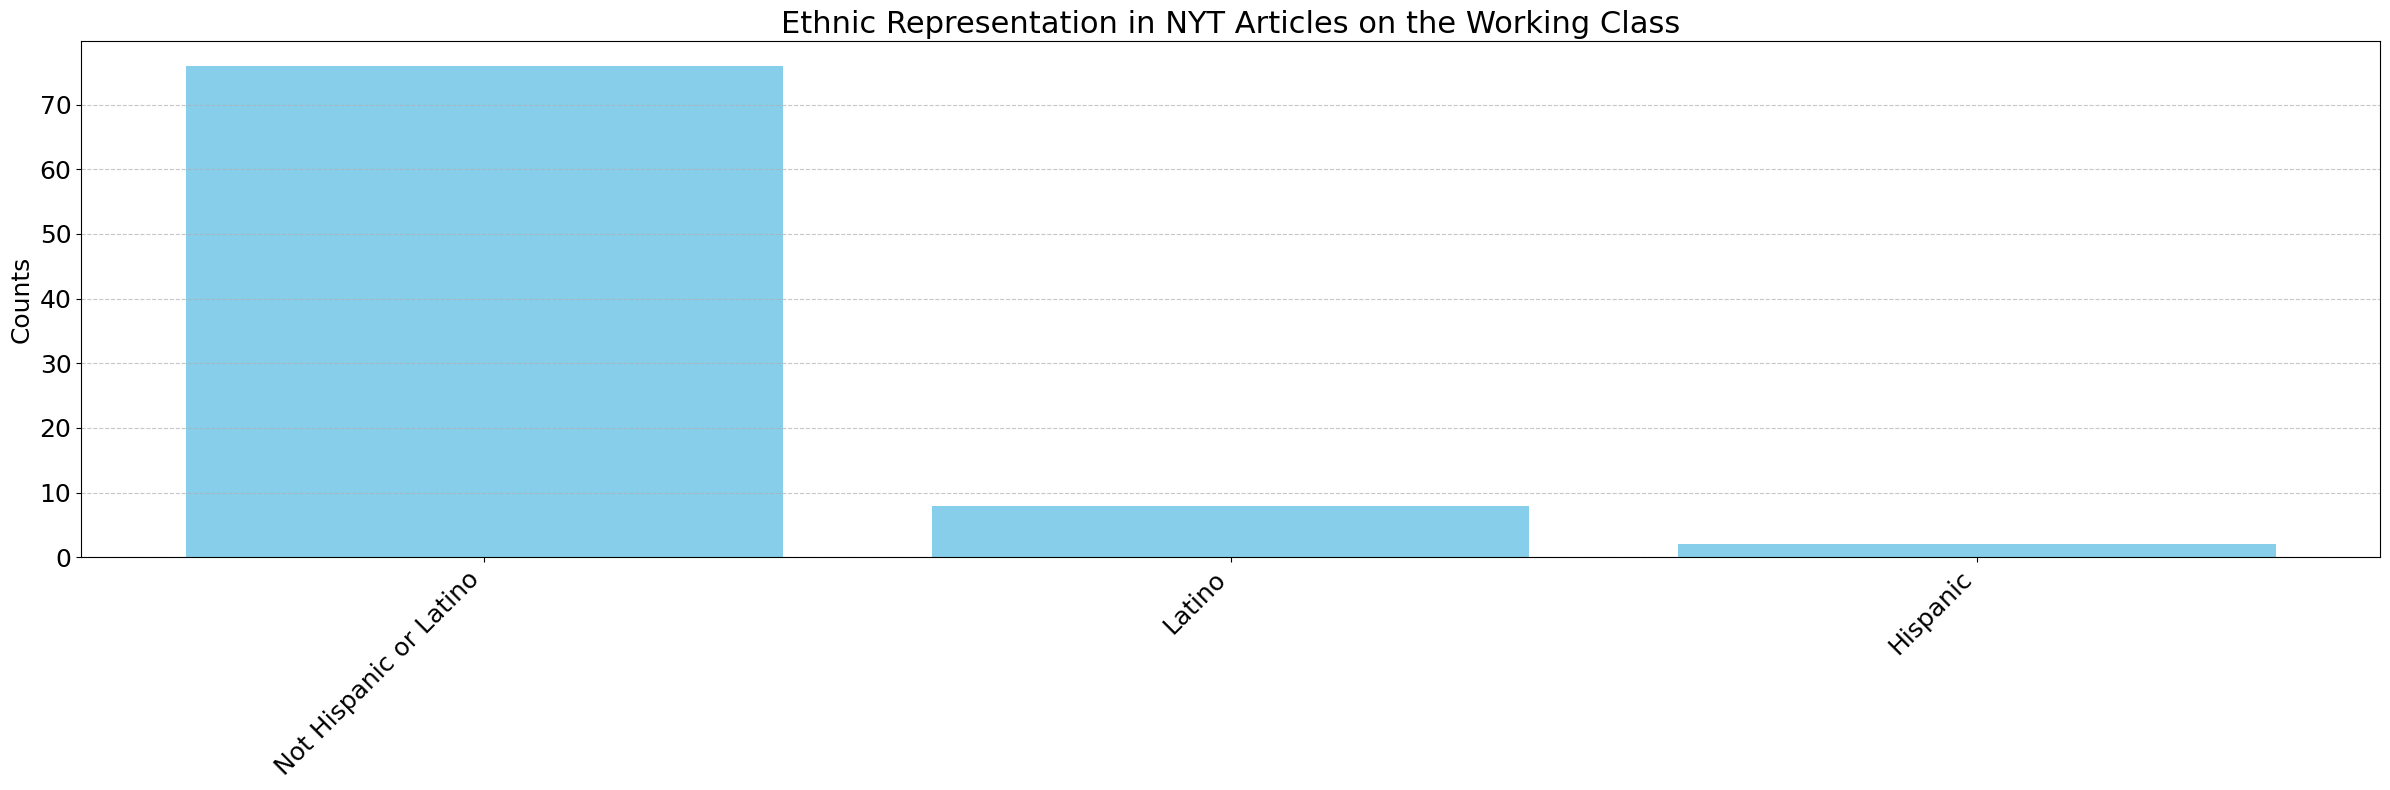

In [42]:
#xlabel = "Ethnicity"
title = "Ethnic Representation in NYT Articles on the Working Class"
filename = "plots/ethnicity_category_nyt.png"
plot_histogram(ethnicity_nyt, title, filename)

Question: Is it unseful to see the "NA"? (though they would dwarf the other categories)

### Gender

In [39]:
list(df_responses_nyt["gender"])

['NA',
 'NA',
 'Mostly men',
 'NA',
 'NA',
 "Mostly men (as described in the article's focus and examples), but also mentions mothers and families.",
 'NA',
 'NA',
 'Mostly male (recruits are described as teenage boys or younger)',
 'Mixed',
 'NA',
 'Mostly men',
 'NA',
 'Mostly men',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'Mixed (includes both men and women; some mention of women students and mothers)',
 'NA',
 'Mostly women (dancers), some men (managers, bouncers, DJs)',
 'NA',
 'NA',
 'Mostly women',
 'NA',
 'Female (Sgt. Barbara Havers)',
 'NA',
 'NA',
 'Mostly women',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'Mixed',
 'Mixed',
 'Mixed',
 'Women',
 'Young woman (for the new pastry chef character)',
 'Mixed (men more vocal than women)',
 'Mixed',
 'NA',
 'Mostly women',
 'Woman',
 'Includes women; overall gender composition not fully specified.',
 'NA',
 'Male',
 'Mixed',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'Women',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA',
 'NA'

TODO: report proportion of "Unspecified".

In [43]:
gender_nyt = list(df_responses_nyt["gender"])
gender_nyt = [item for item in gender_nyt if item != "NA"]
gender_nyt = categorize_descriptors(str(gender_nyt), gender_categories)

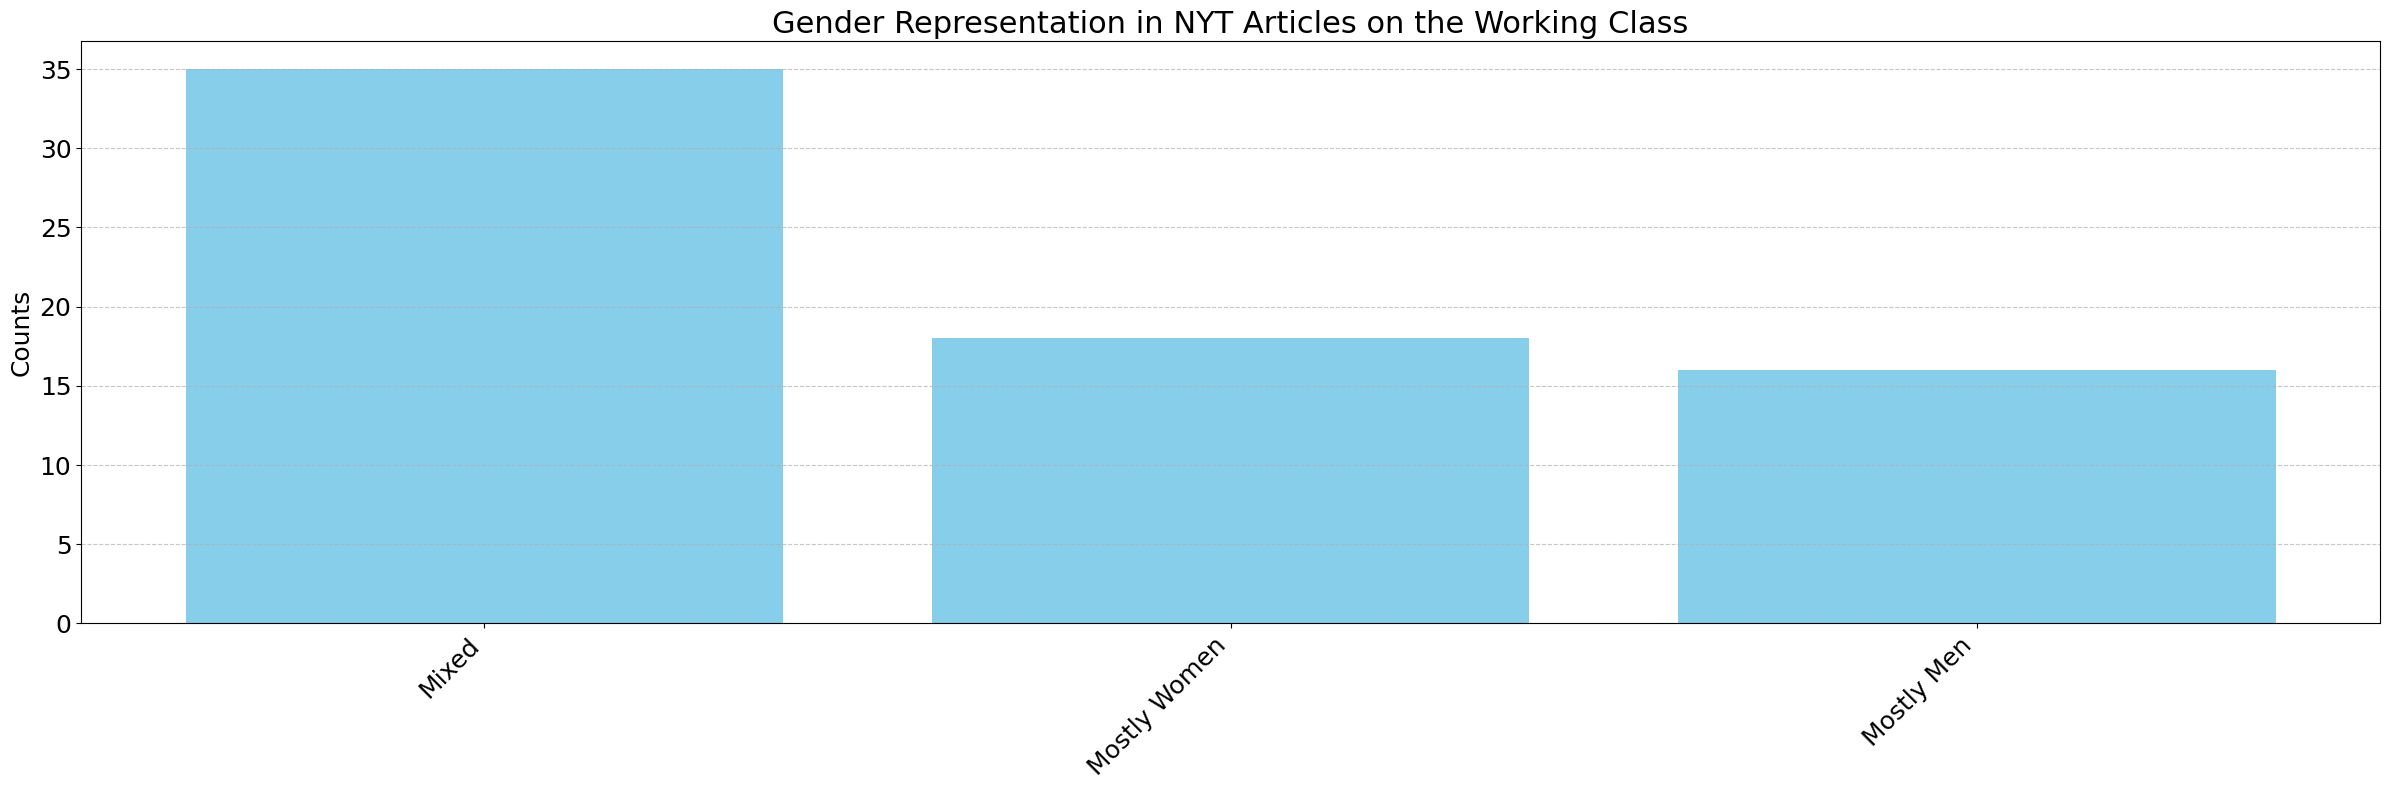

In [44]:
#xlabel = "Gender"
title = "Gender Representation in NYT Articles on the Working Class"
filename = "plots/gender_category_nyt.png"
plot_histogram(gender_nyt, title, filename)

### Other Characteristics

In [45]:
other = [i for i in list(df_responses_nyt["other_characteristics"]) if i != "NA"]
other_str = " ".join(other)

In [46]:
#!pip install wordcloud matplotlib
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(items_list, title, filename):

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(other_str)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off axes
    plt.title(title, fontsize=20)
    plt.savefig(filename, dpi=300, facecolor='white', edgecolor='none')
    plt.show()

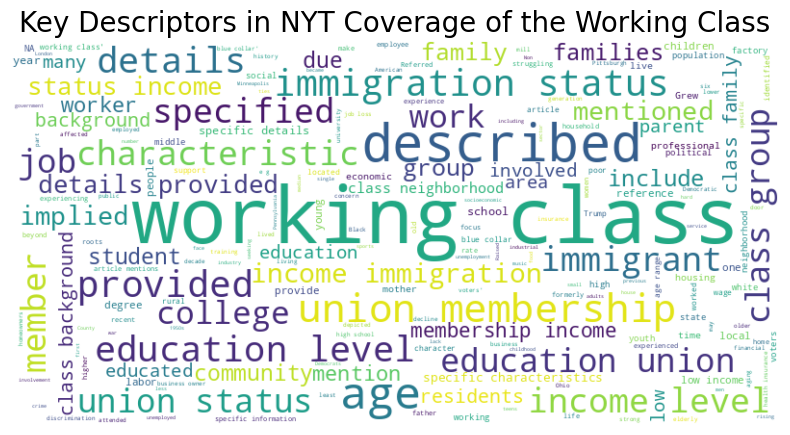

In [106]:
title = "Key Descriptors in NYT Coverage of the Working Class"
filename = "plots/wordcloud_additional_characteristics_nyt.png"
plot_wordcloud(other_str, title, filename)

<a id="comparison-with-other-publishers"></a>

## 6. Comparison with Other Publishers


[⬆ Return to Top](#table-of-contents)

In [49]:
# generate results dataframe
df_other_sample = df_other.sample(sample_size)

# Reset index
df_other_sample.reset_index(drop=True, inplace=True)

# Generate responses
#df_responses_other = generate_responses(df_other_sample)
#df_responses_other.to_pickle("data/df_responses_other_200_sample.pkl")
#df_other_sample_with_results = pd.concat([df_other_sample, df_responses_other], axis=1)
#df_other_sample_with_results.to_pickle("data/df_other_200_sample_with_responses.pkl") 

In [ ]:
#df_responses_other = pd.read_pickle("data/df_responses_other_200_sample.pkl")
#df_other_sample_with_results.read_pickle("data/df_other_200_sample_with_responses.pkl") 

In [95]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def compare_histograms(items_list1, items_list2, title, filename, label1='List 1', label2='List 2', scale_counts = True):
    # Count frequencies
    counter1 = Counter(items_list1)
    counter2 = Counter(items_list2)

    # Get all unique labels
    all_labels = sorted(set(counter1.keys()).union(set(counter2.keys())))
    
    # Total counts for normalization
    total1 = sum(counter1.values())
    total2 = sum(counter2.values())
    
    if scale_counts:
        # Get frequencies (proportions) for each label (0 if not present)
        freq1 = [counter1.get(label, 0) / total1 for label in all_labels]
        freq2 = [counter2.get(label, 0) / total2 for label in all_labels]
    else:
        # Get frequencies for each label (0 if not present)
        freq1 = [counter1.get(label, 0) for label in all_labels]
        freq2 = [counter2.get(label, 0) for label in all_labels]

    # Set positions for bars
    x = np.arange(len(all_labels))
    width = 0.4  # width of the bars

    # Create the grouped bar chart
    plt.figure(figsize=(24, 8))
    plt.bar(x - width/2, freq1, width, label=label1, color='skyblue')
    plt.bar(x + width/2, freq2, width, label=label2, color='salmon')

    # Formatting
    #plt.xlabel(xlabel, fontsize=18)
    if scale_counts:
        plt.ylabel('Frequency', fontsize=18)
    else:
        plt.ylabel('Count', fontsize=18)
    plt.title(title, fontsize=22)
    plt.xticks(x, all_labels, rotation=45, ha='right', fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(fontsize=18)
    plt.tight_layout()

    # Save and show
    plt.savefig(filename, dpi=300, facecolor='white', edgecolor='none')
    plt.show()


### Location

In [52]:
# Get and process Other source locations
locations_other = flatten_and_filter(df_responses_other["geographical_locations"])
print(f"Other total locations: {len(locations_other)}")

# Split locations
states_other, countries_other = split_locations(locations_other)

Other total locations: 256


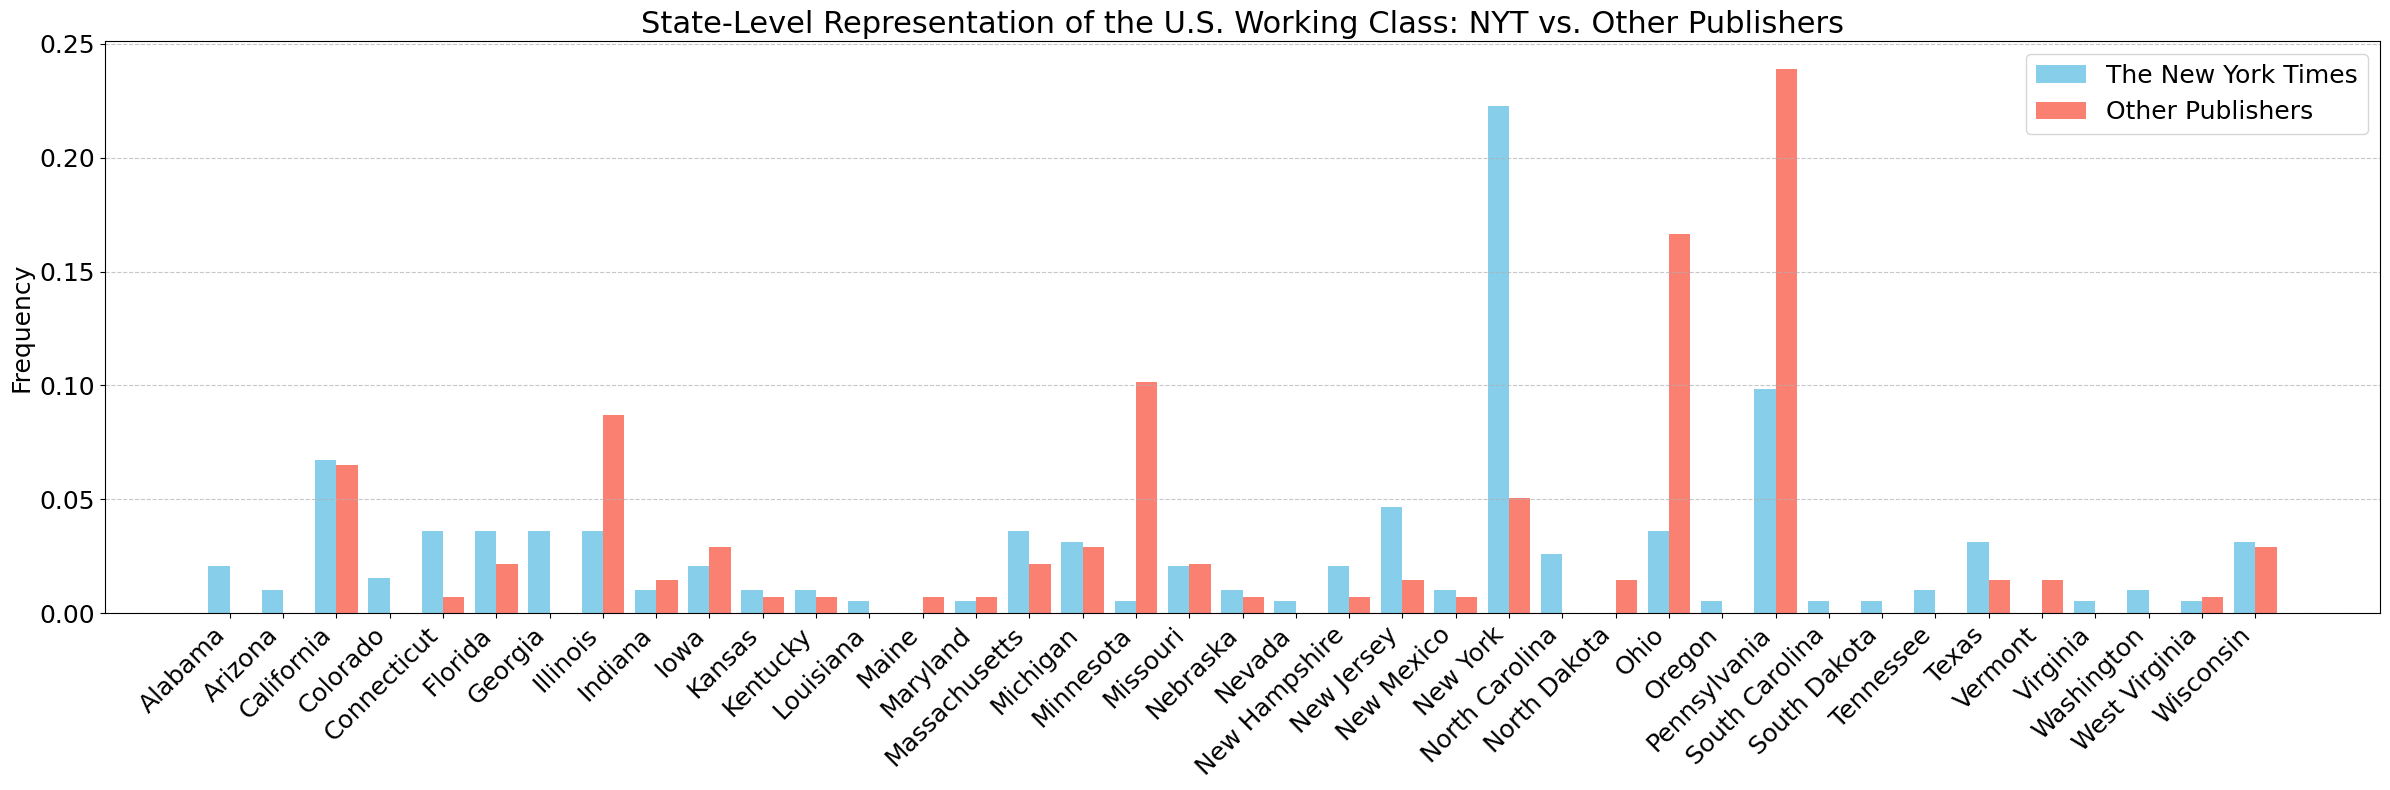

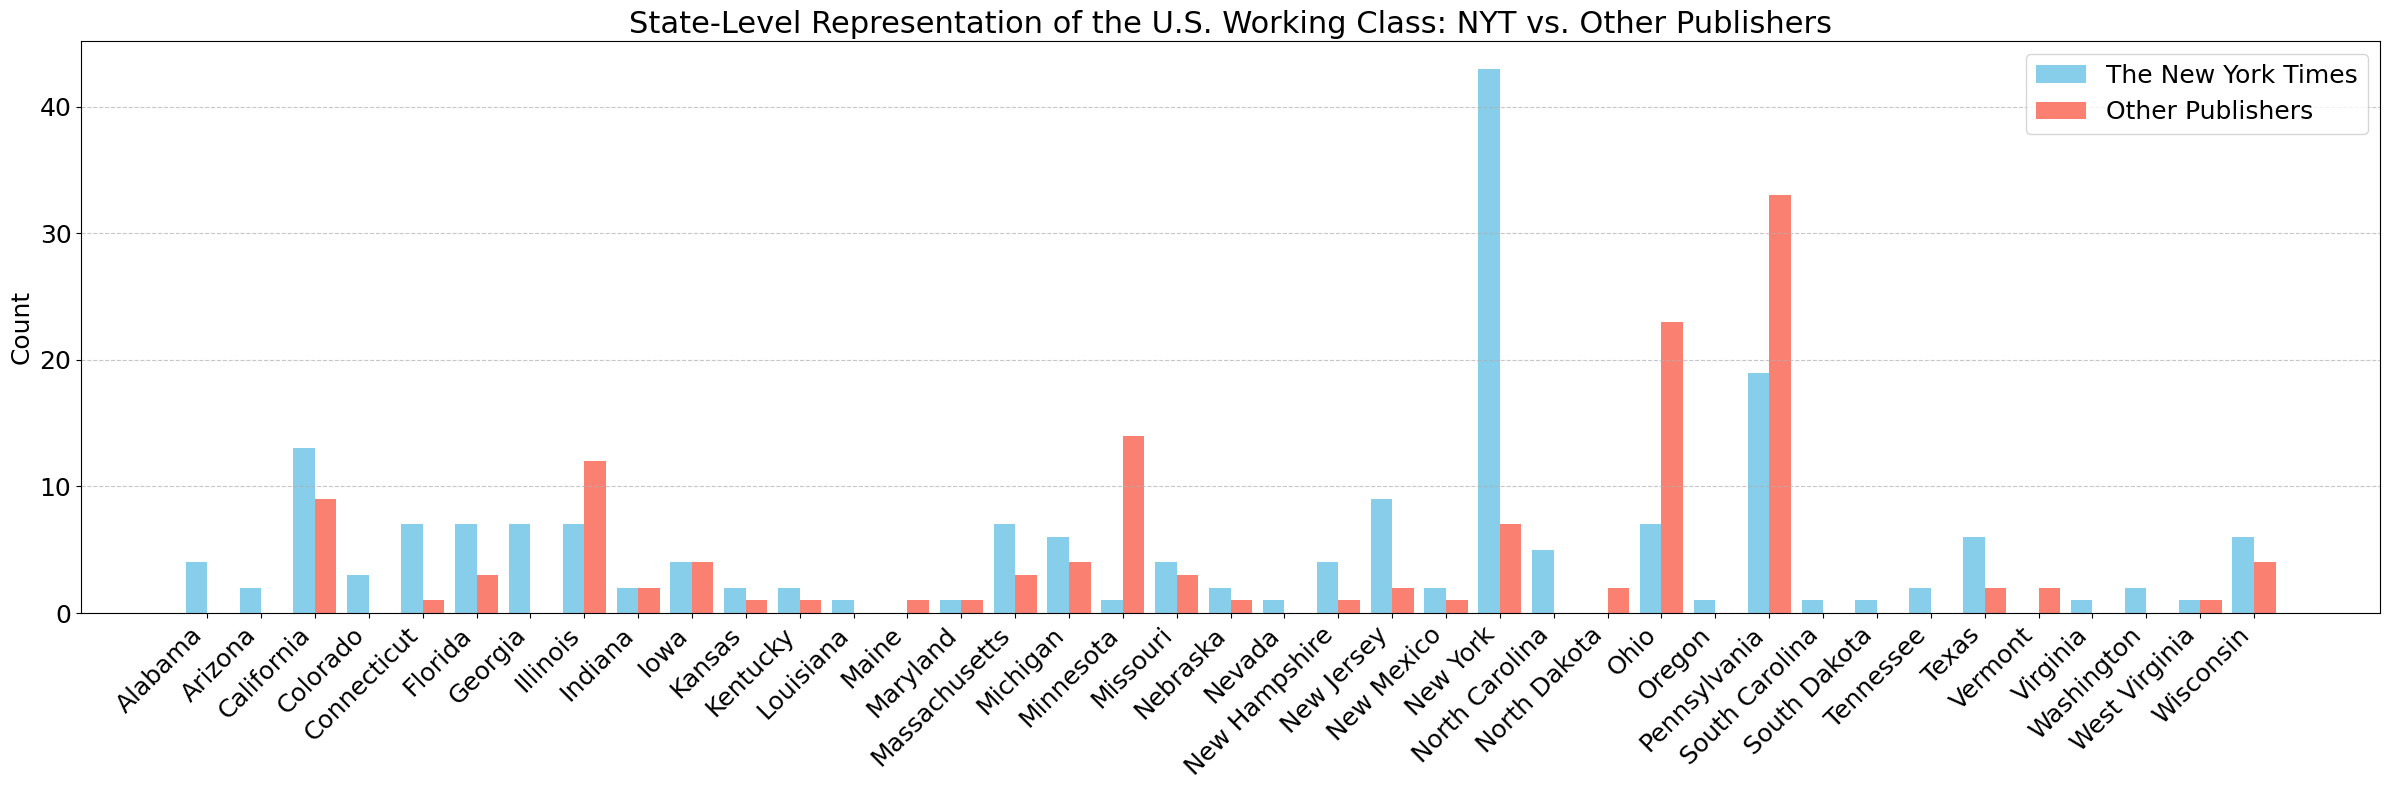

In [99]:
#xlabel = 'U.S. State'
title = 'State-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "plots/comparison_states.png"
compare_histograms(states_nyt, states_other, title, filename, label1='The New York Times', label2='Other Publishers')
# without scaling counts
compare_histograms(states_nyt, states_other, title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False)


### Occupation

In [54]:
occupations_other = list(df_responses_other["occupations"])
occupations_other = [item for sublist in occupations_other for item in sublist if item != "NA"]
occupations_other = categorize_descriptors(str(occupations_other), occupation_categories)
occupations_other = [i if i in occupation_categories else "Other" for i in occupations_other]

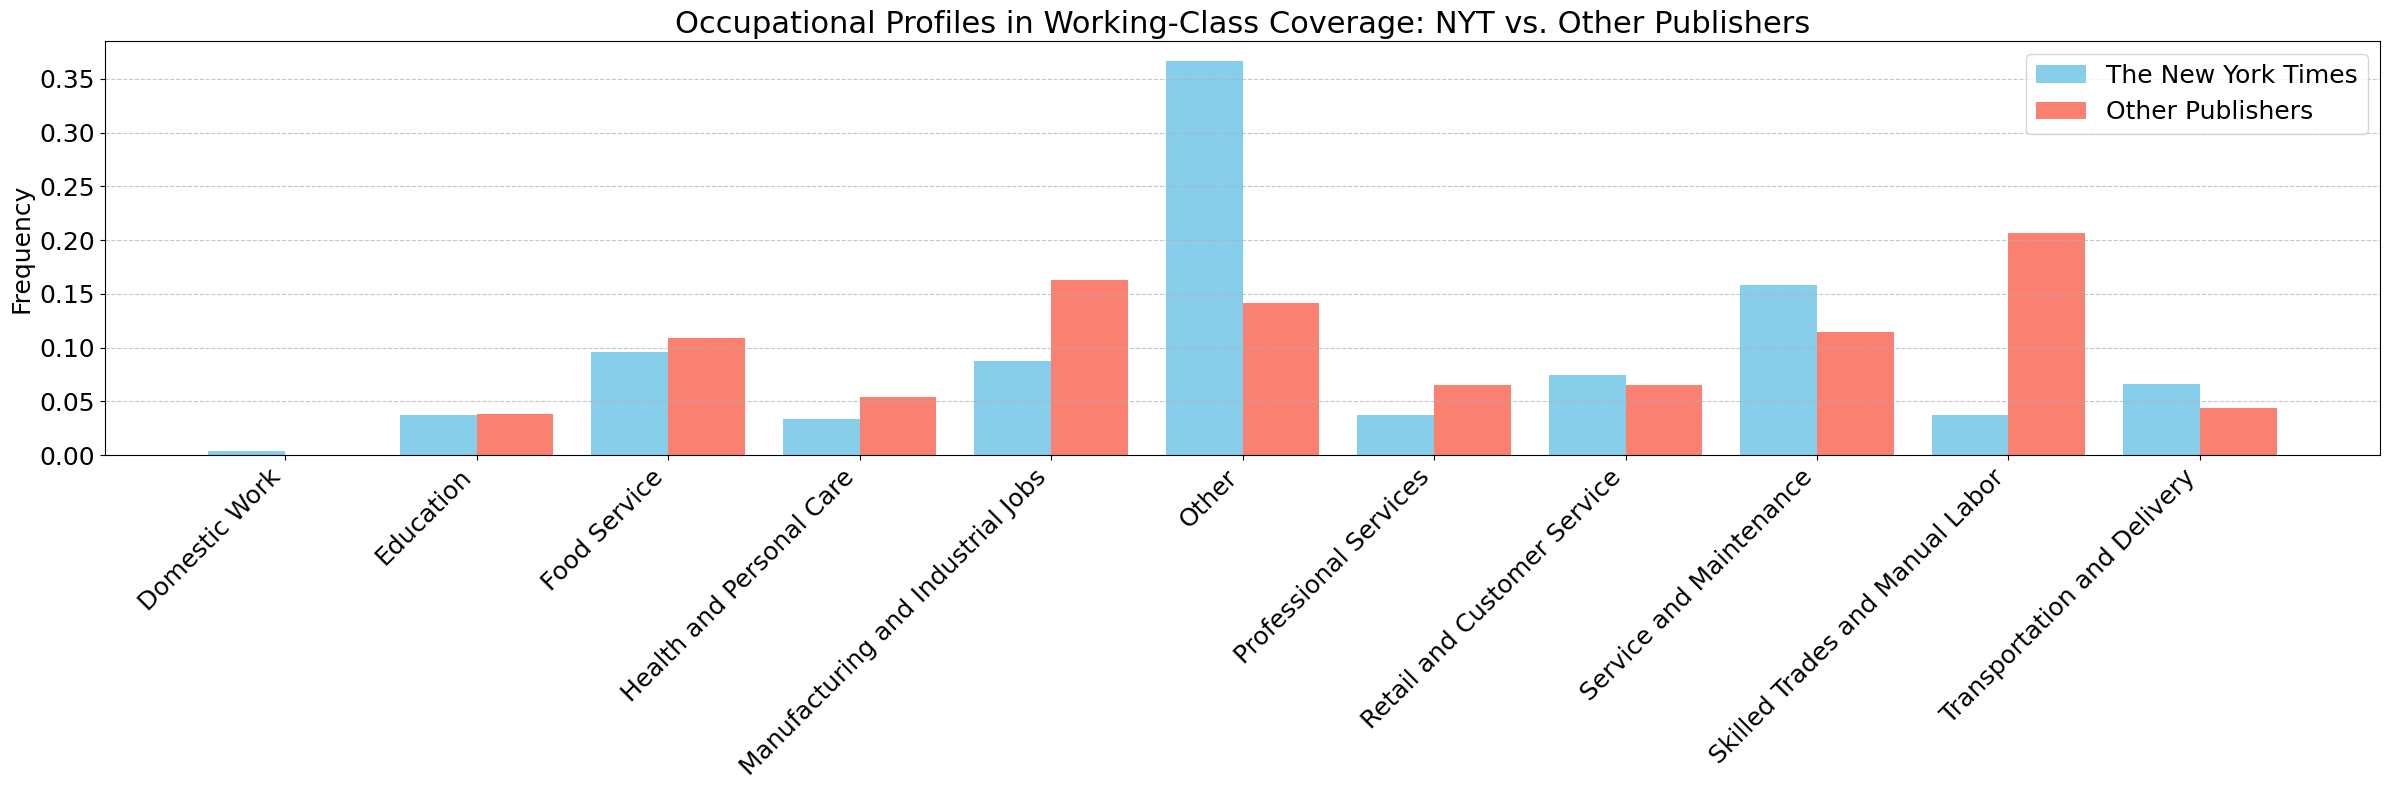

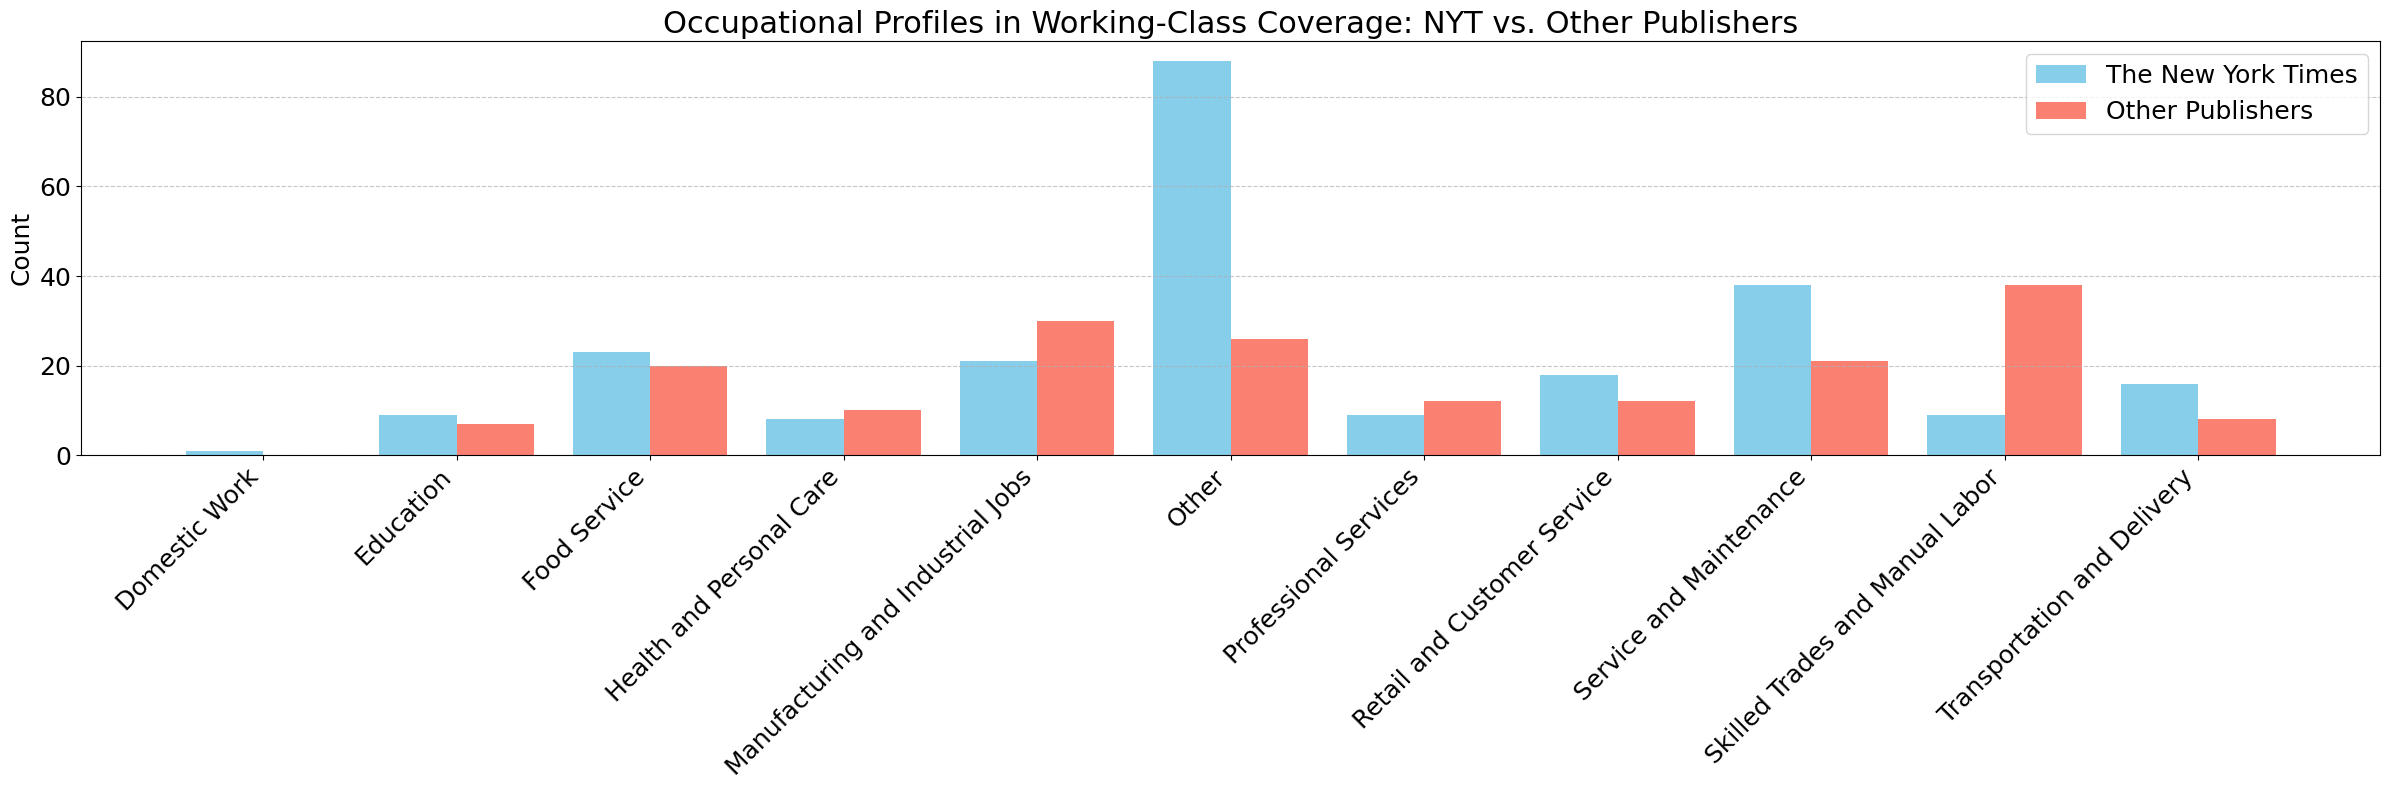

In [100]:
#xlabel = 'Occupation'
title = 'Occupational Profiles in Working-Class Coverage: NYT vs. Other Publishers'
filename = "plots/comparison_occupation.png"
compare_histograms(occupations_nyt, occupations_other, title, filename, label1='The New York Times', label2='Other Publishers')
compare_histograms(occupations_nyt, occupations_other, title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False)

### Race & Ethnicity

In [71]:
#race_other, ethnicity_other = extract_race_ethnicity(df_responses_other)

In [ ]:
# Should be able to run line above instead of this one. Troubleshoot.
# Extract and filter out "NA" strings
race_ethnicity_other = df_responses_other["race_ethnicity"].dropna()
race_ethnicity_other = [resp for resp in race_ethnicity if resp != "NA"]
    
# Categorize race and ethnicity
race_other = categorize_descriptors(str(race_ethnicity_other), racial_categories)
ethnicity_other = categorize_descriptors(str(race_ethnicity_other), ethnic_categories)

# Filter out "NA" results from categorization
race_other = [r for r in race if r != "NA"]
ethnicity_other = [e for e in ethnicity if e != "NA"]

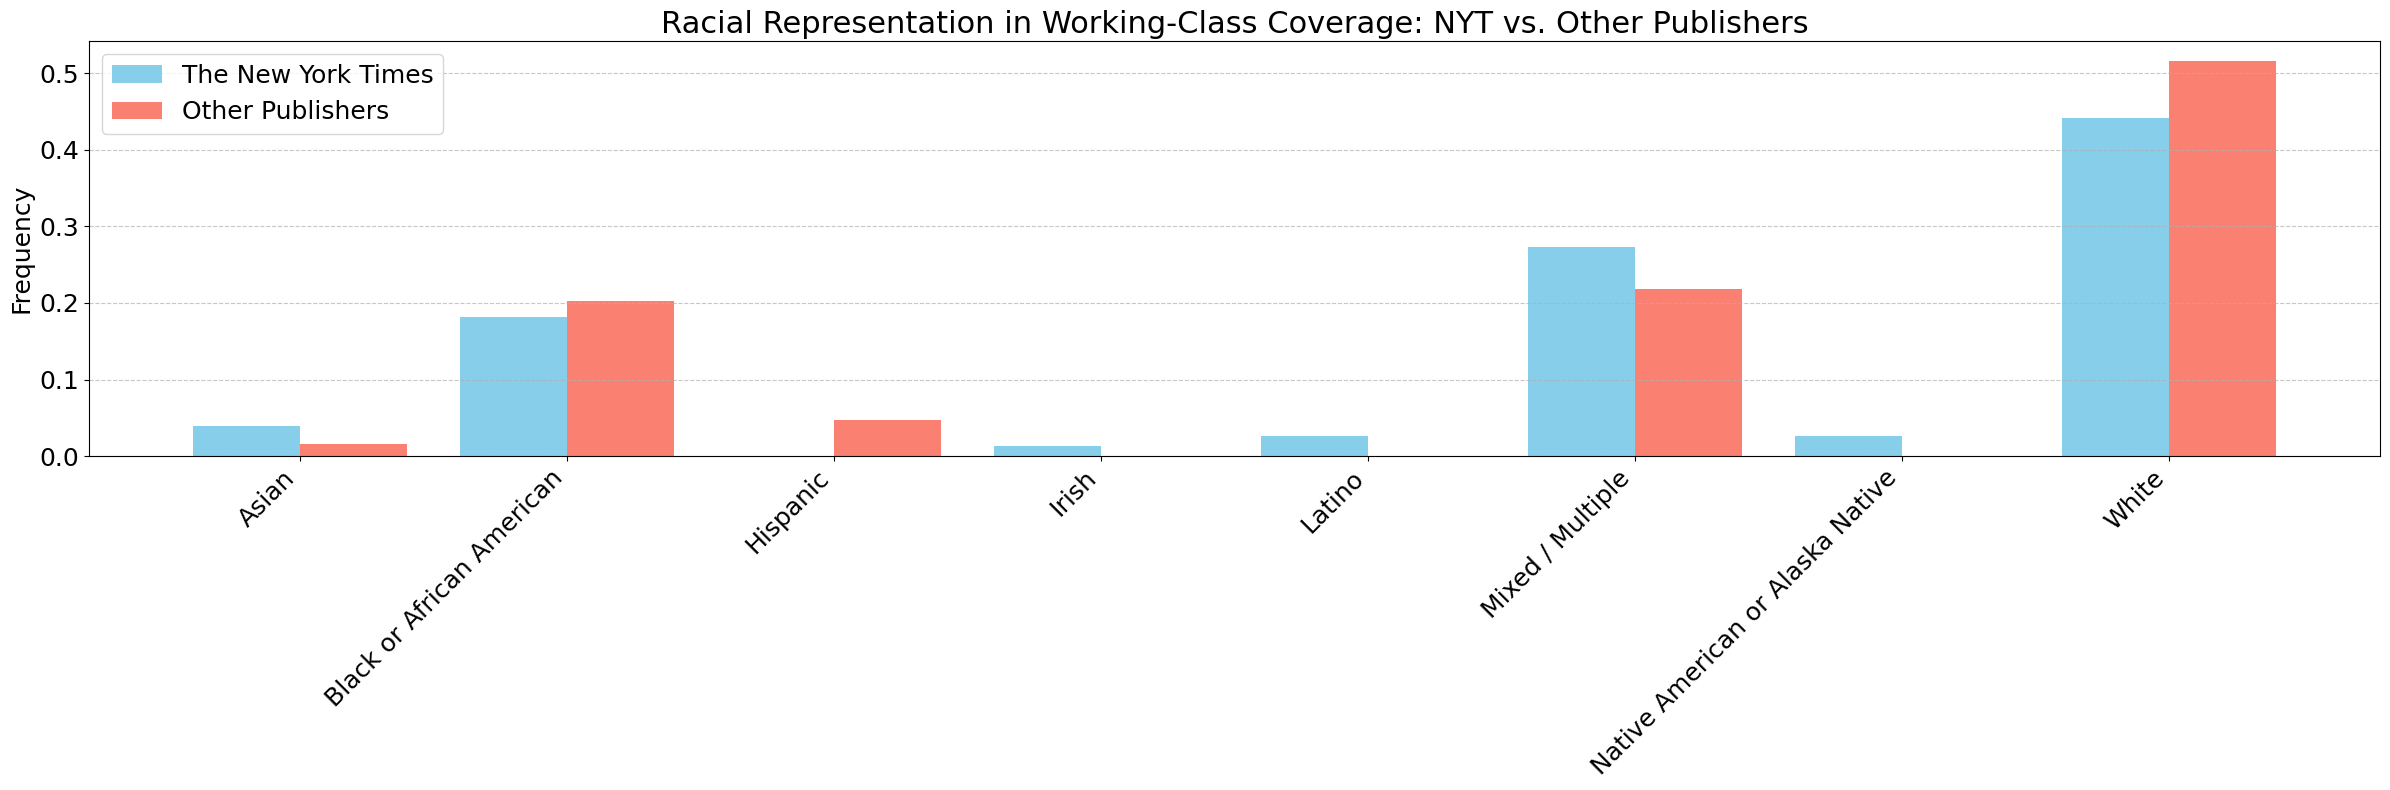

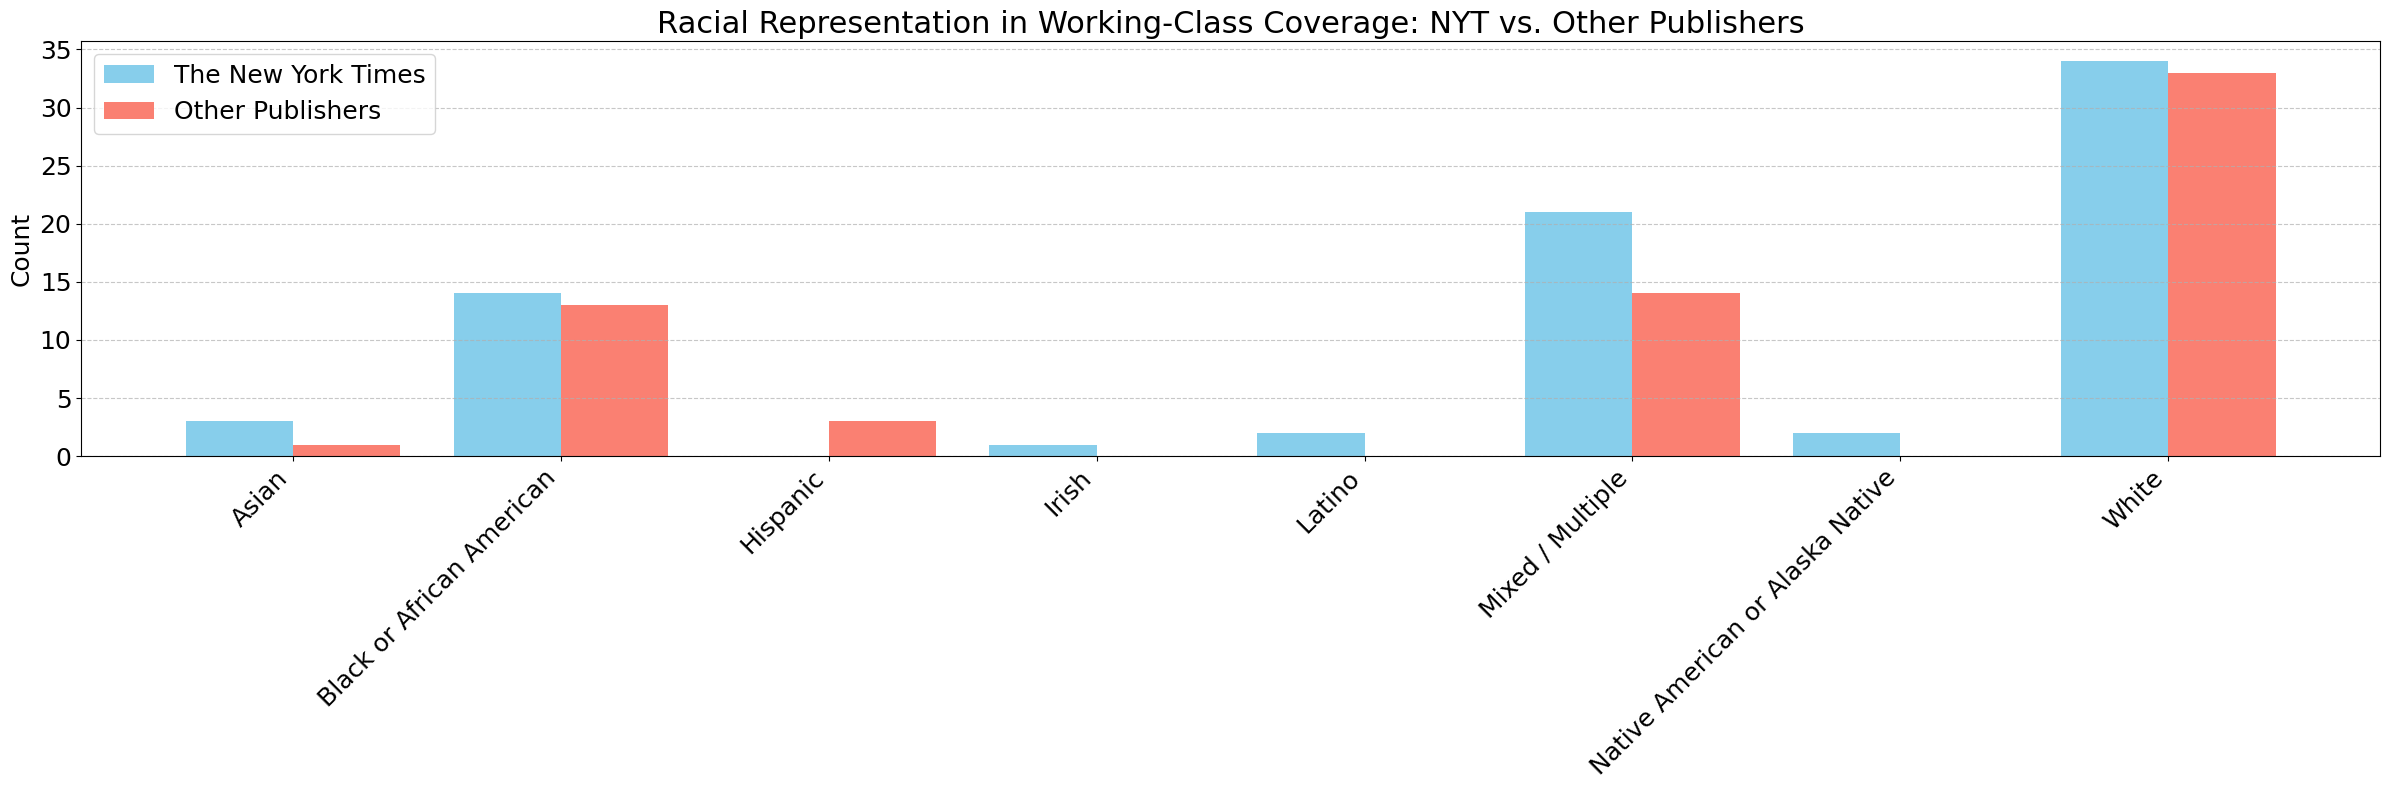

In [101]:
#xlabel = 'Race'
title = 'Racial Representation in Working-Class Coverage: NYT vs. Other Publishers'
filename = "plots/comparison_race.png"
compare_histograms(race_nyt, race_other, title, filename, label1='The New York Times', label2='Other Publishers')
compare_histograms(race_nyt, race_other, title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False)


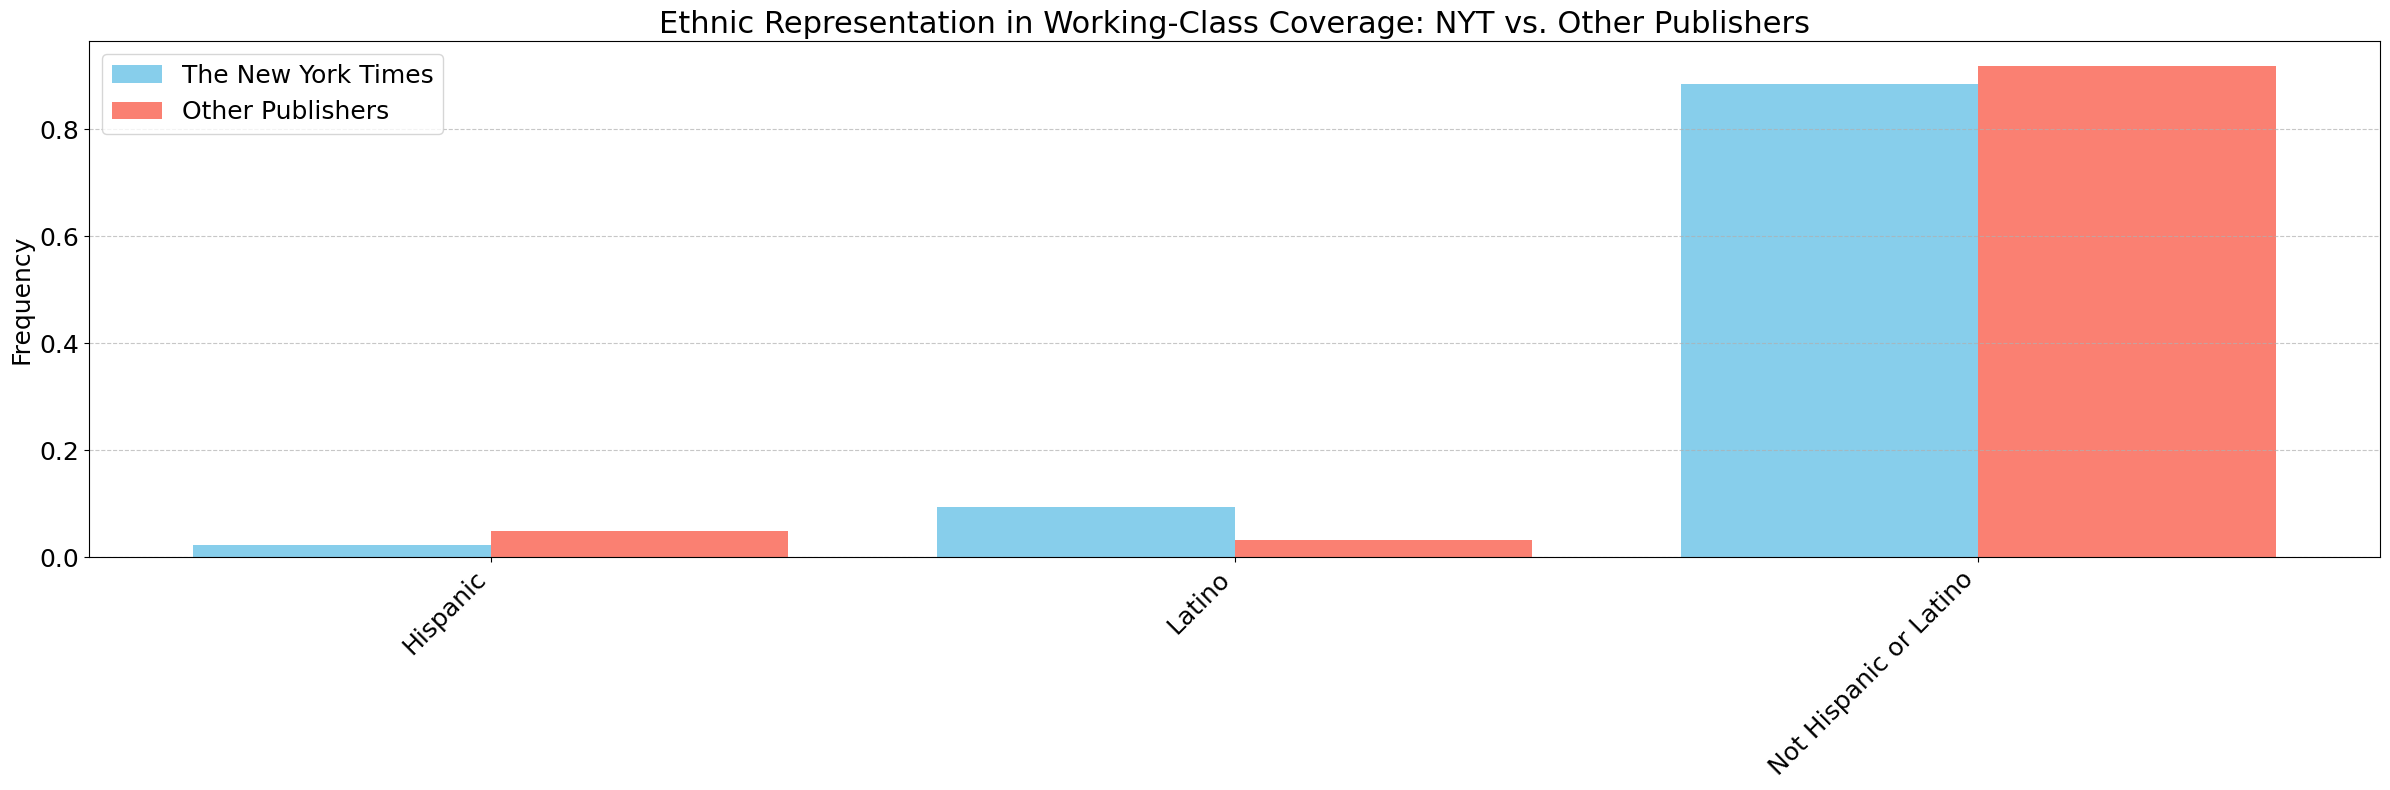

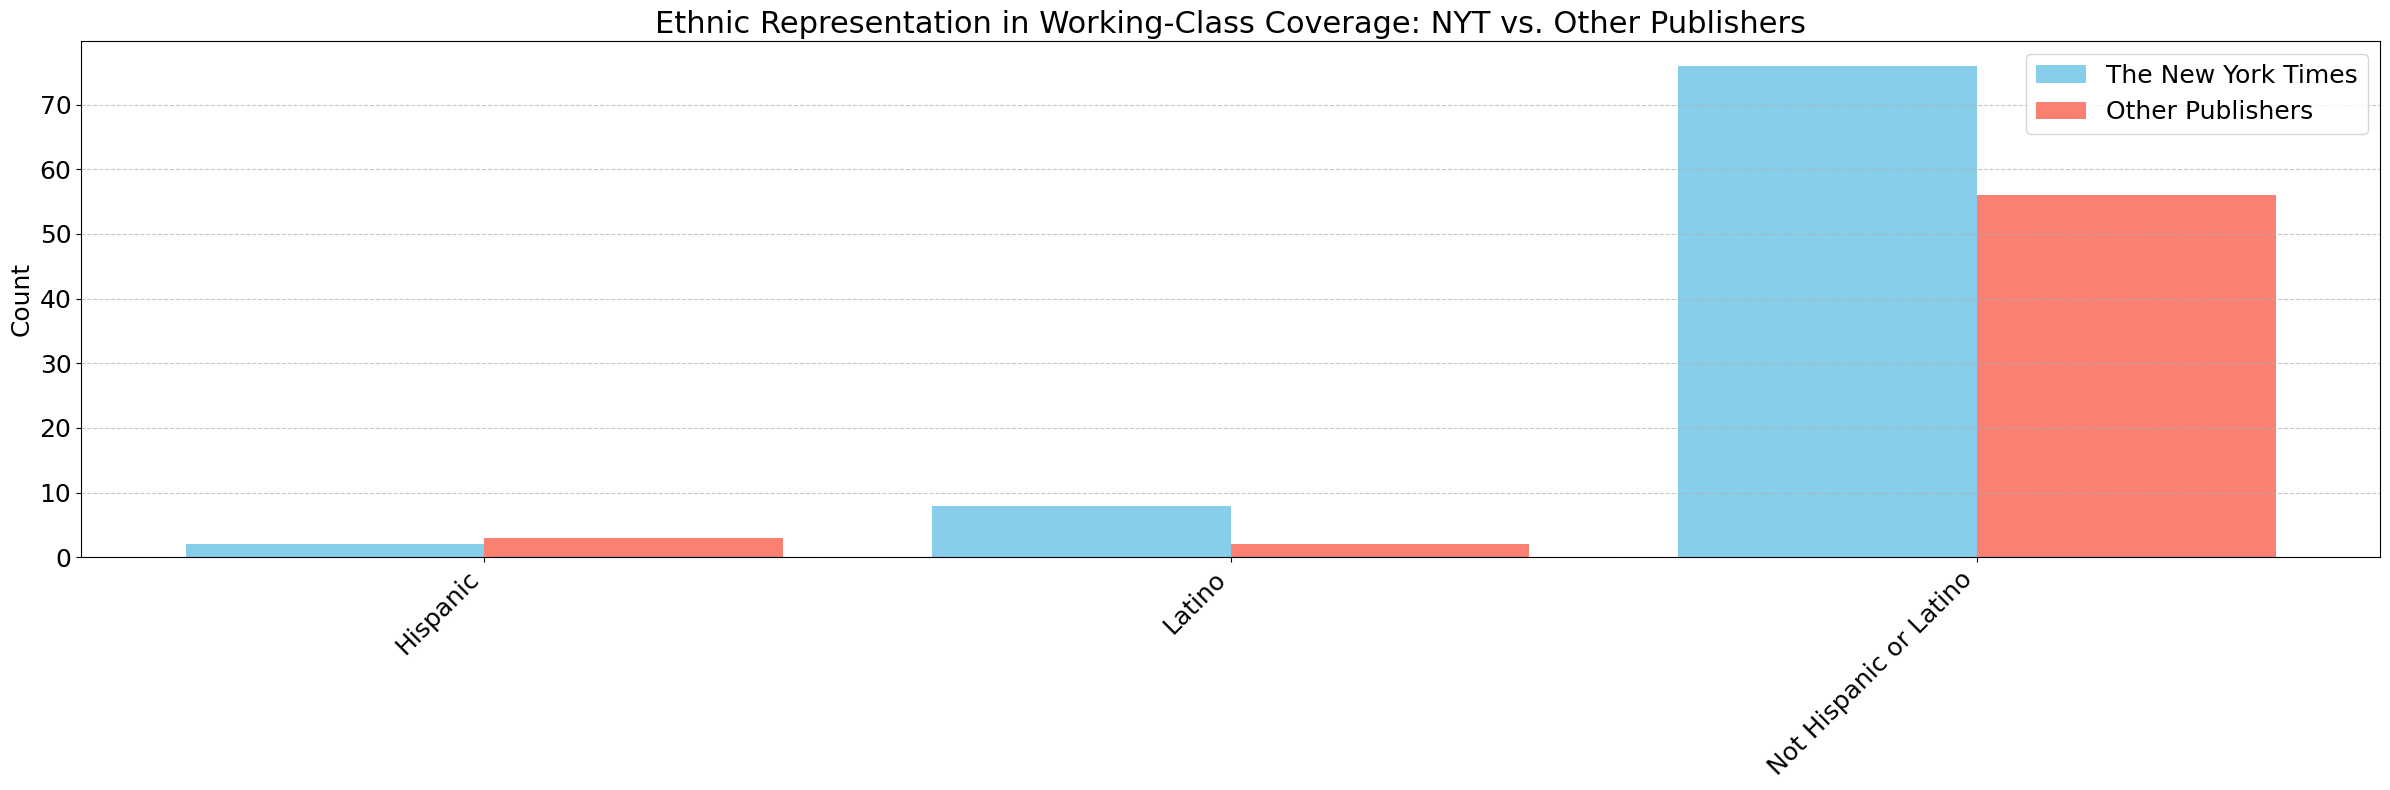

In [102]:
#xlabel = 'Ethnicity'
title = 'Ethnic Representation in Working-Class Coverage: NYT vs. Other Publishers'
filename = "plots/comparison_ethnicity.png"
compare_histograms(ethnicity_nyt, ethnicity_other, title, filename, label1='The New York Times', label2='Other Publishers')
compare_histograms(ethnicity_nyt, ethnicity_other, title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False)




### Gender

In [78]:
gender_other = list(df_responses_other["gender"])
gender_other = [item for item in gender_other if item != "NA"]
gender_other = categorize_descriptors(str(gender_other), gender_categories)

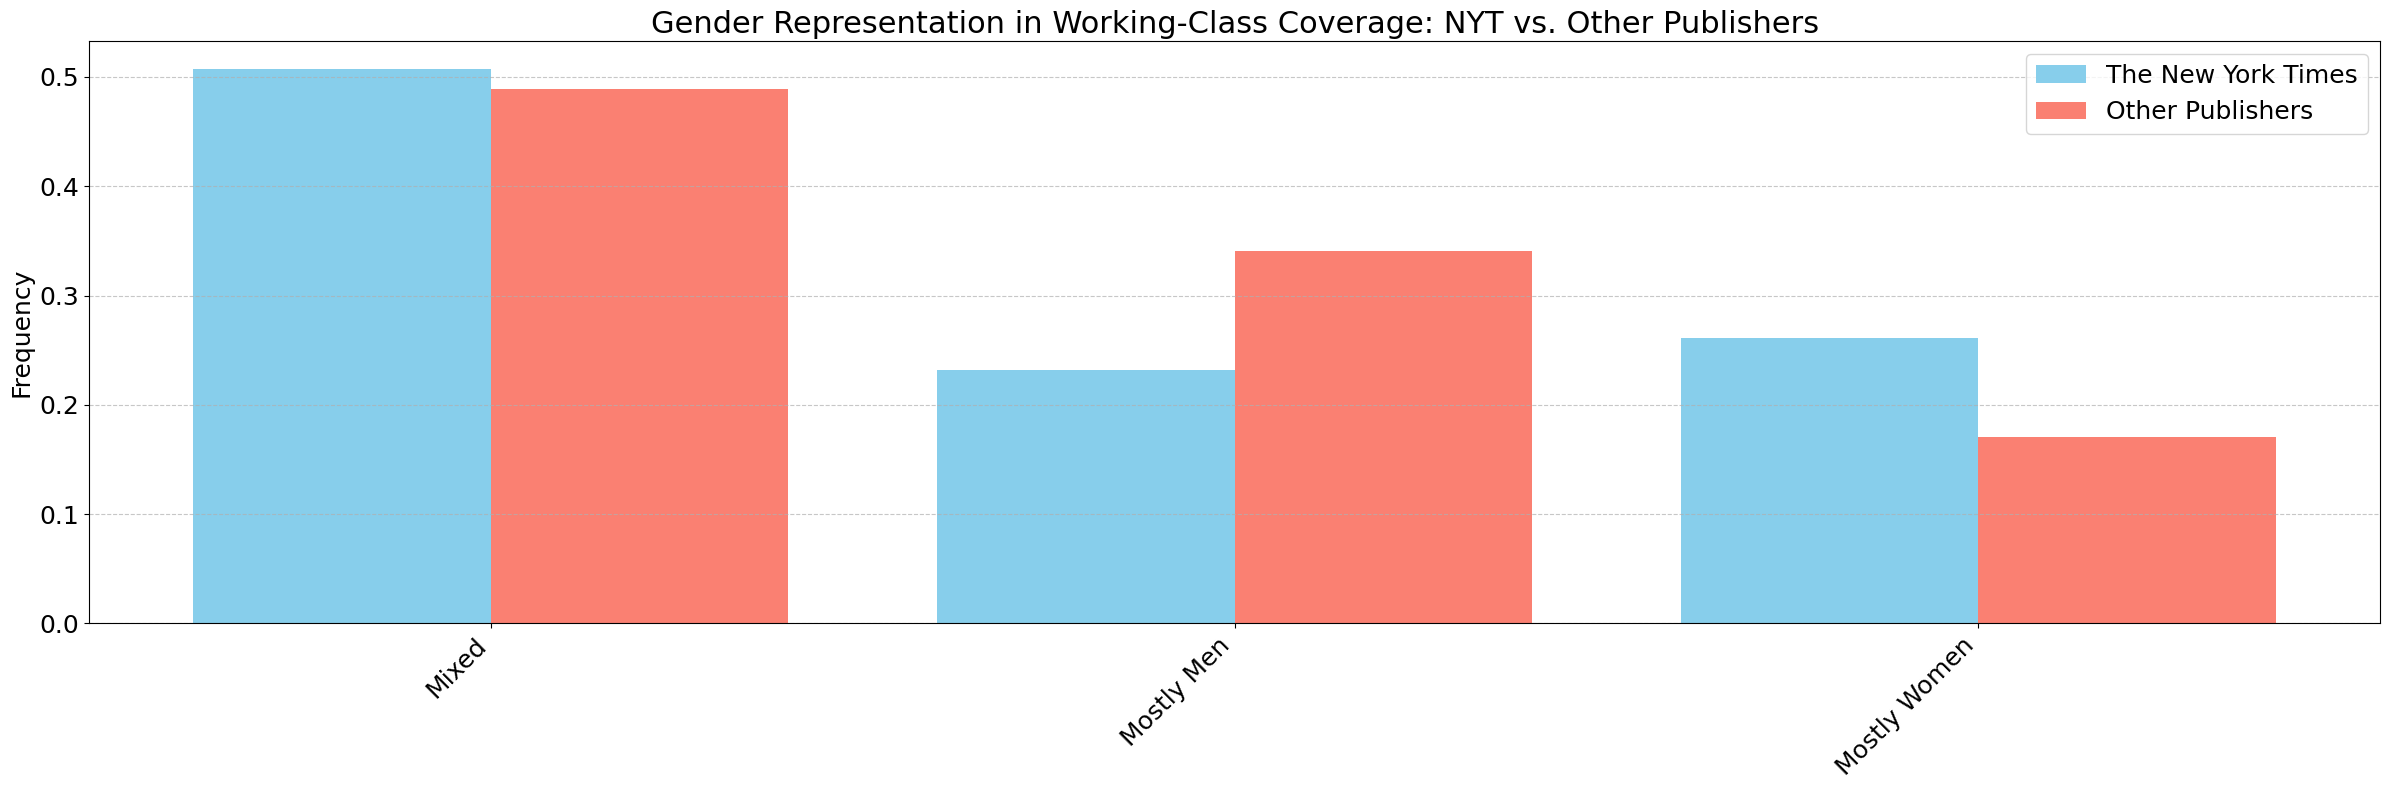

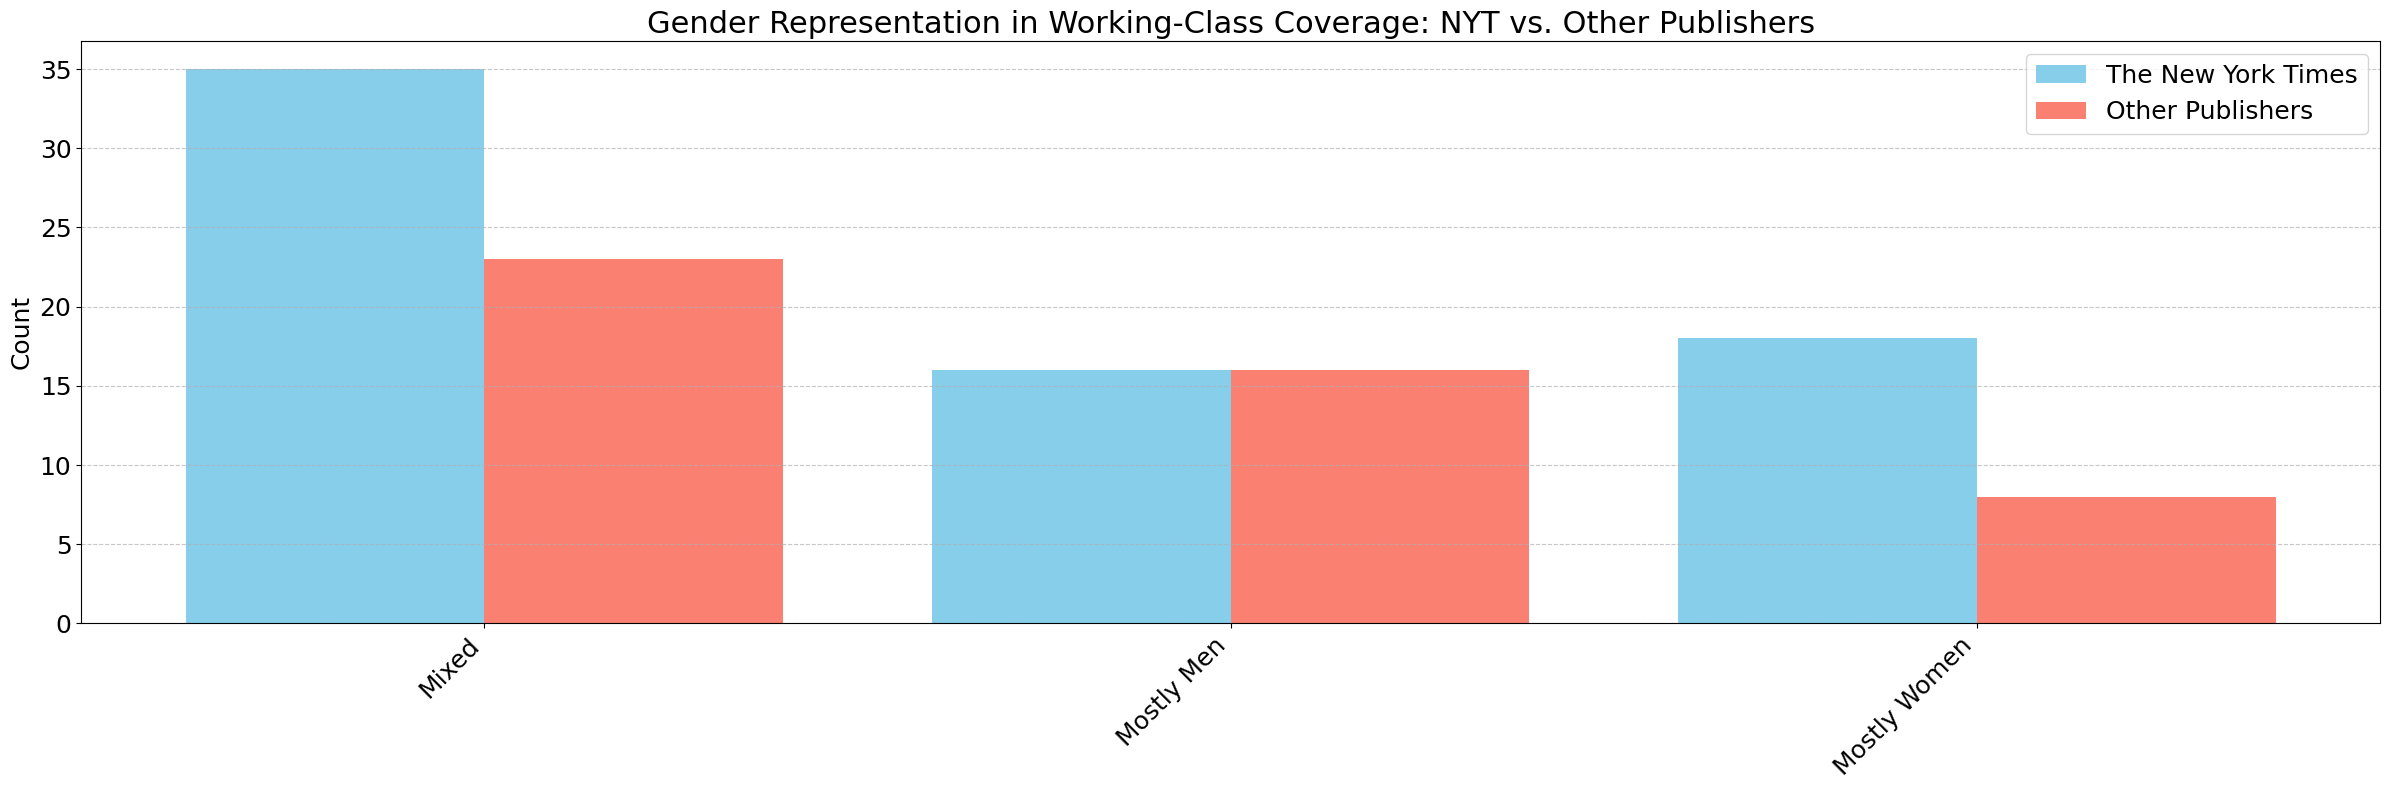

In [103]:
#xlabel = 'Gender'
filename = "plots/comparison_gender.png"
title = 'Gender Representation in Working-Class Coverage: NYT vs. Other Publishers'
compare_histograms(gender_nyt, gender_other, title, filename, label1='The New York Times', label2='Other Publishers')
compare_histograms(gender_nyt, gender_other, title, filename[:-4] + "_raw_counts.png", label1='The New York Times', label2='Other Publishers', scale_counts=False)


### Other characteristics

In [104]:
other = [i for i in list(df_responses_other["other_characteristics"]) if i != "NA"]
other_str = " ".join(other)

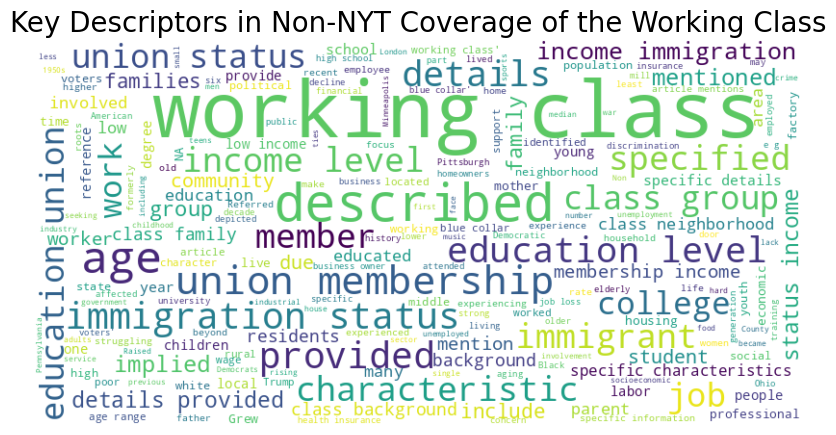

In [105]:
title = "Key Descriptors in Non-NYT Coverage of the Working Class"
filename = "plots/wordcloud_additional_characteristics_other.png"
plot_wordcloud(other_str, title, filename)

<a id="next-steps"></a>

# 7. Next Steps


[⬆ Return to Top](#table-of-contents)


TODO:

* Read background reseach in Google Drive

* Troubleshoot data issues

* Confirm approach and methods with Elena

* Expand to entire dataset

* Clean code

* Add notebook descriptions

Open questions:

* See data issues (Search "question").

* Plotting frequencies vs counts in comparison plots

* Adjust domains, categories for domains, prompts?

* Analyze historical patterns to understand if media coverage has shifted over time?



<a id="troubleshooting"></a>

## 8. Troubleshooting

[⬆ Return to Top](#table-of-contents)

### Investigate Specific Cases

In [40]:
idx = 4
user_prompt = "Title: {}.\n\nBody: {}".format(df_nyt_sample["title"].iloc[idx], df_nyt_sample["body_cleaned"].iloc[idx])
print(user_prompt)

Title: HERS.

Body: at age of 27 i became head foreign-exchange options trader at a major commercial bank in new york. i managed hundreds of millions of dollars' worth of options. i ran offices in new york london. it was a powerful demanding position. few women have had this experience, so i am often asked what it was like to work in a bank trading room on wall street. i like to tell following story: it was a cold day in early february, almost a year to day since i had started my trading career. we'd had an unusually hectic morning, i was sitting at my desk, frantically trying to calculate effect of morning's trades on overall position. this had to be done quickly accurately. i was lost in concentration when suddenly i noticed that there was something wrong. it took me a second or two to realize what was matter. room had gone completely quiet. during entire year i had been trading, i had never experienced so complete a silence. instinctively, i glanced at reuters screen. currency price

In [ ]:
response_dict = analyze_working_class(user_prompt)
response_dict

### Example issues

In [22]:
df.iloc[129]['body']

'— my work private citizen come january — work unfinished.” photo: senator sherrod brown, who once considered potential presidential candidate, received encouragement democratic colleagues try come back senate two midterms. (photograph haiyun jiang york york )'

In [26]:
df.iloc[171]['body']

'’s finance committee.. trump’s inauguration, senate plans introduce fleet bills related protecting reproductive rights, including one. krueger protect women’s health information another increase funding training medical providers how perform abortions. “ privacy issue becomes more relevant we sink la-la land administration congress who want encourage women die states they cannot get abortion proper health care,”. krueger, pointing texas attorney general’s recent lawsuit against york doctor prescribing abortion pills woman dallas.. stewart-cousins, democrat, statement voters expect elected forcefully stand up. trump again “ continue make child care college tuition more affordable, help families afford groceries, pay utility bills lower costs prescription drugs.” senator michael gianaris, deputy majority leader, affordability push also most likely see state lawmakers take big tech regulate artificial intelligence products. also bill update state’s enforcement antitrust laws, which likel

# Notes

__Definitions__

Oxford definition: "the socioeconomic group consisting of people who are employed in manual or industrial work."

Oxford definition of industry: "economic activity concerned with the processing of raw materials and manufacture of goods in factories."


__Key Dimensions to Consider__

* Geographical Location: Often associated with regions like the Midwest in U.S. discourse.

* Occupation: Typically involve manual labor, skilled trades, or service industry work, and often do not require a four-year college degree.

    * Skilled Trades and Manual Labor
    
    * Manufacturing and Industrial Jobs
    
    * Service and Maintenance Jobs
    
    * Transportation and Delivery
    
    * Food Service
    
    * Retail and Customer Service
    
    * Health and Personal Care

* Race: Representation may differ across media and historical narratives.

* Gender: Varies by industry and media portrayal.

* Other Possible Factors:

    * Education level
    
    * Union membership
    
    * Income level
    
    * Immigration status

__Media Representations__

* New York Times

    * May assume the working class = white men in industrial jobs.

* Black Newspapers

    * Highlight working-class experiences of minorities and women.

    * Broader and more inclusive definition of the working class.